# Two Steps MultiFidelity Neural Network

Code to show the performance of the Neural Network when dealing with different LF datasets 

In [35]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)



True

In [36]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [37]:
# import of the train data
# st.Venant constitutive law for the HF data

mu_train_HF = np.loadtxt("../DATA_shear/Data_Train_bases_short/mu_train_HF.txt")
U_hf_train = np.loadtxt("../DATA_shear/Data_Train_bases_short/Uhf_train.txt")


# Linear constitutive law for the LF data
mu_train_LF = np.loadtxt("../DATA_shear/Data_Train_bases_linshort/mu_train_LF.txt")
U_lf_train = np.loadtxt("../DATA_shear/Data_Train_bases_linshort/Ulf_train.txt")
n_bases_train= U_lf_train.shape[1] 



In [38]:
print(mu_train_LF.shape)

(10, 3)


In [39]:
# import of the test data
# st.Venant constitutive law for the HF data

mu_test = np.loadtxt("../DATA_shear/Data_Test_bases/mu_test.txt")
U_hf_test = np.loadtxt("../DATA_shear/Data_Test_bases/Uhf_test.txt")

# st.Venant constitutive law for the LF data
U_lf_test = np.loadtxt("../DATA_shear/Data_Test_bases/Ulf_test.txt")
n_bases_test= U_lf_test.shape[1]

n_bases=min(n_bases_test,n_bases_train)

print(f"Nb. of considered bases is {n_bases}")
# I create a list of the models
model_list=[0]*n_bases

Nb. of considered bases is 7


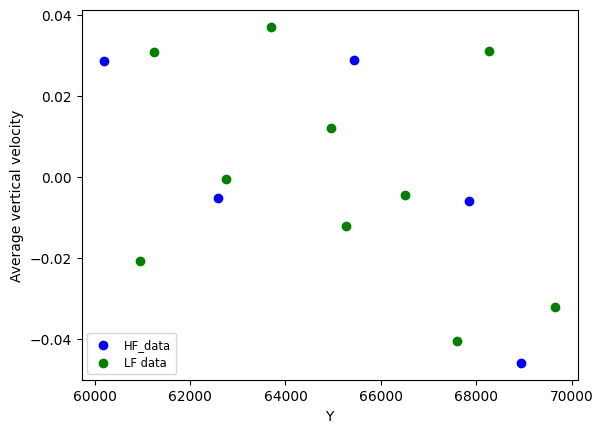

In [40]:
plt.scatter(mu_train_HF[:,0], U_hf_train-np.mean(U_hf_train), label='HF_data', color='blue', marker='o')
plt.scatter(mu_train_LF[:,0], U_lf_train[:,0]-np.mean(U_lf_train[:,0]), label='LF data', color='green', marker='o')
plt.xlabel('Y')
plt.ylabel('Average vertical velocity')
plt.legend(prop={'size': 8.3})
plt.show()

In [41]:
U_lf_train=U_lf_train-np.mean(U_lf_train,axis=0)
U_hf_train=U_hf_train-np.mean(U_hf_train)

U_lf_test=U_lf_test-np.mean(U_lf_test,axis=0)
U_hf_test=U_hf_test-np.mean(U_hf_test)

In [42]:
# Number of data of High and Low Fidelity components of the dataset
n_HF = np.array([5])
Nlf = np.array([10])

batch_size=[10,5]

In [45]:
U_LF_list = []
U_HF_list = []
# number of epochs 
Nepo=[10000,100000]

# NepoLF = 7000  # number of epochs for first NN: NN_LF
# NepoHF = 8000  # number of epochs for second NN: NN_HF

r2_HF_df = pandas.DataFrame(columns=['NB.basis','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['NB.basis','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['NB.basis','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['NB.basis','MSE'])  # dataframe which stores LF MSE



## Neural Network
Cycle on the Discretization and the value of the diffusion 

Folder '2_step_models' already exists.
********************  # Nb. basis = 0  ********************
********************  # NHF: = 5  ********************
********************  # NLF: = 10  ********************
The function training took 19.134945392608643 seconds.


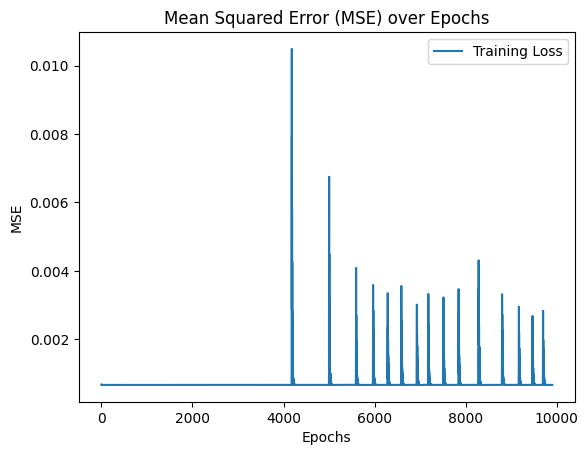

The function training took 183.32393169403076 seconds.


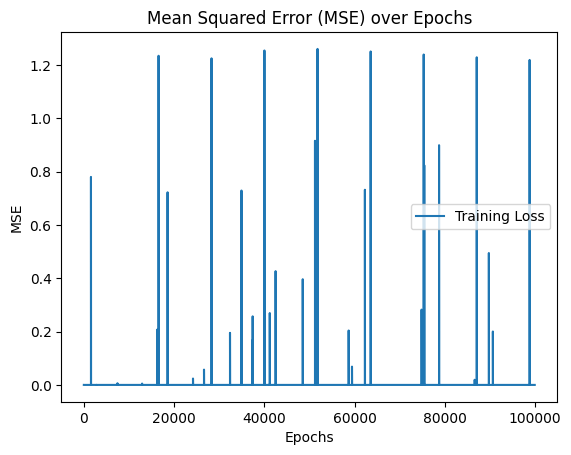

low fidelity NN
Test MSE: 0.0002562942872800784
R^2: -2.9019058267465425e-09
Final model
Test MSE: 0.000674357665765107
R^2: -6.000910879322419e-11


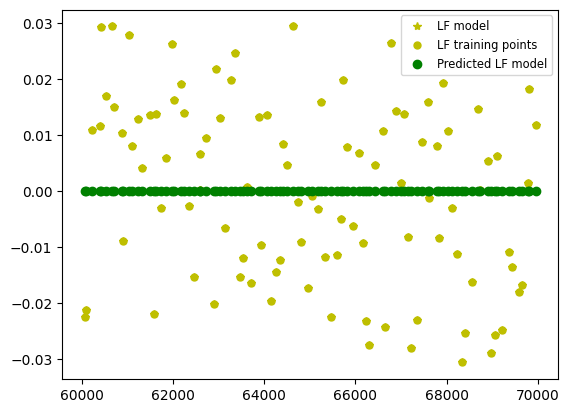

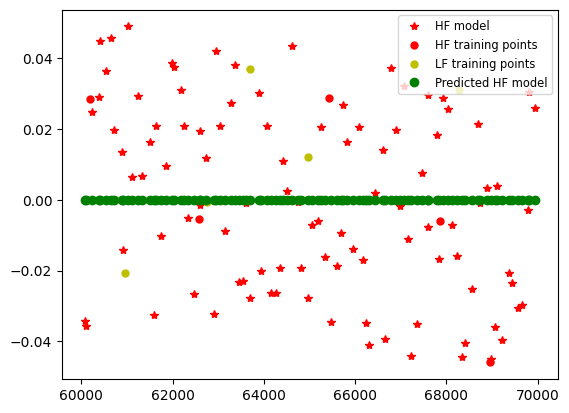

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8888\2616878212.py:144: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_LF_df = pandas.concat([r2_LF_df, pandas.DataFrame([new_data])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8888\2616878212.py:148: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  r2_HF_df = pandas.concat([r2_HF_df, pandas.DataFrame([new_data])], ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8888\2616878212.py:152: FutureWarning: The behavio

Saving ...
********************  # Nb. basis = 1  ********************
********************  # NHF: = 5  ********************
********************  # NLF: = 10  ********************


In [46]:
# Name of the folder
folder_name = "2_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")

test_mse_HF_list = []
test_mse_LF_list = []

r2_HF_list = []
r2_LF_list = []

for m in range(n_bases):

    for nhf in n_HF:
        for nlf in Nlf:
    
            print(
            f"********************  # Nb. basis = {m}  ********************"
            )
            
            print(
            f"********************  # NHF: = {nhf}  ********************"
            )
            print(
            f"********************  # NLF: = {nlf}  ********************"
            )
           
            
            # randomization and selection of the training set
            permutation = np.random.permutation(len(mu_train_HF))
            mu_HF = mu_train_HF[permutation,:][0:nhf,:]
            U_HF = U_hf_train[permutation][0:nhf]
            
            permutation = np.random.permutation(len(mu_train_LF))
            mu_LF = mu_train_LF[permutation][0:nlf]
            U_train_LF = U_lf_train[permutation,m][0:nlf]

            ##########################      Neural Network     ##########################
            K.clear_session()
            
            # parameters 
            bestLF_params = {
                "lr": 0.0255,
                "kernel_init": "glorot_uniform",
                "opt": "Adamax",
            } 
            best_params={'kernel_init': 'uniform', 'l2weight': 0.00107, 'lr': 0.00152, 'nodes': 12.0, 'opt': 'Adamax'}


            # Multifidelity network 
            names=["LF","HF"]
            params=[bestLF_params, best_params]
            data_train=[mu_LF, mu_HF]
            output_train=[U_train_LF,U_HF]
            model= NetworkFactory.build_network("2step",names,params=params,data_train=data_train,output_train=output_train,N=Nepo,n=batch_size,do_HPO=False,verbose=False)

            # low fidelity part of the network 
            ULF = model.model_list[0].prediction(mu_test)
            print("low fidelity NN")
            
            (test_mse_LF,r2_LF) = model.model_list[0].performance(mu_test,U_lf_test[:,m])
            test_mse_LF_list.append(test_mse_LF)
            r2_LF_list.append(r2_LF)

            # creation of the input of the second part of the 2 steps NN to study the high fidelity model
            input_HF = np.concatenate(
                (mu_test,  model.model_list[0].prediction(mu_test).reshape(-1,1)),axis=1
            )  # <- TRAINING INPUT for the second NN: NN_HF

            input_HF_train = np.concatenate(
                (mu_HF,  model.model_list[0].prediction(mu_HF).reshape(-1,1)),axis=1
            ) 
            # performance of the last part of the network
            print("Final model")
            (test_mse_HF,r2_HF) = model.model_list[1].performance(input_HF,U_hf_test)                
            test_mse_HF_list.append(test_mse_HF)
            r2_HF_list.append(r2_HF)
            
            
            # plots of the model
            plt.figure()
            plt.plot(
            mu_test[:, 0], U_lf_test[:,m], "y*", linewidth=1.5, label="LF model"
            )
            plt.plot(
            mu_test[:, 0],
            U_lf_test[:,m],
            "yo",
            markersize=5,
            label="LF training points",
            )
            plt.plot(
            mu_test[:, 0],
            model.model_list[0].prediction(mu_test),
            "go",
            linewidth=3,
            label="Predicted LF model",
            )
            plt.legend(prop={"size": 8.3})
            plt.show()
            
            plt.figure()
            plt.plot(
            mu_test[:,0], U_hf_test, "r*", linewidth=1.5, label="HF model"
            )
            plt.plot(
            mu_HF[:, 0],
            U_HF,
            "ro",
            markersize=5,
            label="HF training points",
            )
            
            
            order=np.argsort(mu_HF[:,0])
            
            plt.plot(
            mu_LF[order,0],
            U_train_LF[order],
            "yo",
            markersize=5,
            label="LF training points",
            )
            plt.plot(
            input_HF[:, 0],
            model.model_list[1].prediction(input_HF),
            "go",
            linewidth=3,
            label="Predicted HF model",
            )
            plt.legend(prop={"size": 8.3})
            plt.show()
            
            new_data = {'Nb.basis': m+1}

            # DataFrame r2_LF_df
            new_data['R2'] = r2_LF_list[-1]
            r2_LF_df = pandas.concat([r2_LF_df, pandas.DataFrame([new_data])], ignore_index=True)

            # DataFrame r2_HF_df
            new_data['R2'] = r2_HF_list[-1]
            r2_HF_df = pandas.concat([r2_HF_df, pandas.DataFrame([new_data])], ignore_index=True)

            # DataFrame mse_LF_df
            new_data['MSE'] = test_mse_LF_list[-1]
            mse_LF_df = pandas.concat([mse_LF_df, pandas.DataFrame([new_data])], ignore_index=True)

            # DataFrame mse_HF_df
            new_data['MSE'] = test_mse_HF_list[-1]
            mse_HF_df = pandas.concat([mse_HF_df, pandas.DataFrame([new_data])], ignore_index=True)
        
        
            # save the model
            model_list[m]=model
            model.save(str(m),folder_path)

        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

## Save the output

In [ ]:
# os.makedirs(folder_path)

# r2_HF_df.to_csv(
#     "./{folder_name}/r2_HF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
#     header=True,
#     index=False,
#     sep="\t",
#     mode="a",
# )
# mse_HF_df.to_csv(
#     "./{folder_name}/mse_HF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
#     header=True,
#     index=False,
#     sep="\t",
#     mode="a",
# )
# r2_LF_df.to_csv(
#     "./{folder_name}/r2_LF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
#     header=True,
#     index=False,
#     sep="\t",
#     mode="a",
# )
# mse_LF_df.to_csv(
#     "./{folder_name}/mse_LF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class.txt",
#     header=True,
#     index=False,
#     sep="\t",
#     mode="a",
# )

# with open("./{folder_name}/U_HF_list.data", "wb") as filehandle:
#     # store the data as binary data stream
#     pickle.dump(U_HF_list, filehandle)

# with open("./{folder_name}/U_LF_list.data", "wb") as filehandle:
#     pickle.dump(U_LF_list, filehandle)

# Inverse problem

In [ ]:
dim=5
# before normalization I look for 5 values between 0.5 and 1.5
#real_x = np.random.rand(dim)
real_x=np.array([0.11234,0.333,0.5,0.665,0.7])
reaction_HF_test_original=reaction_HF_test_original[:,0]
# I find the mmost similar value in our dataset, so that I can then find the "correct" U for the function
closest_indices = np.argmin(np.abs(reaction_HF_test_original[:, np.newaxis] - real_x), axis=0)
real_x=real_x.reshape(-1, 1)

nearest_x=reaction_HF_test_original[closest_indices]

NameError: name 'reaction_HF_test_original' is not defined

In [ ]:
# found the correct value, as if I have applied the real function
nearest_U=U_HF_test_original[closest_indices]
reaction_HF_test_original=np.c_[reaction_HF_test_original, np.abs(np.sin(5*np.pi*reaction_HF_test_original-5*np.pi/6))]

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.1*4 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x)) # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

In [ ]:
#real_x=np.c_[real_x, np.abs(np.sin(5*np.pi*real_x-5*np.pi/6))]
transformations= lambda x: np.abs(np.sin(5*np.pi*x-5*np.pi/6))
transformations=[transformations]

In [ ]:
# from functools import reduce

# x_final = reduce(lambda acc, trasf: np.hstack([acc, trasf(acc)]), transformations, real_x)

In [ ]:
nearest_U=nearest_U.reshape(-1,1)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]


Sampling chain 1/4


Running chain, α = 0.48: 100%|██████████| 1000/1000 [02:17<00:00,  7.28it/s]


Sampling chain 2/4


Running chain, α = 0.33: 100%|██████████| 1000/1000 [02:15<00:00,  7.40it/s]


...

Sampling chain 4/4


Running chain, α = 0.47: 100%|██████████| 1000/1000 [02:14<00:00,  7.41it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


estimated values are [0.44  0.469 0.585 0.558 0.341]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.440  0.436  -0.312    1.125      0.165    0.122       7.0      23.0   
x1  0.469  0.384  -0.270    1.265      0.141    0.105       7.0      18.0   
x2  0.585  0.329  -0.180    1.141      0.118    0.088       8.0      14.0   
x3  0.558  0.404  -0.247    1.255      0.135    0.099      10.0      40.0   
x4  0.341  0.370  -0.225    1.018      0.150    0.112       7.0      44.0   

    r_hat  
x0   1.57  
x1   1.50  
x2   1.44  
x3   1.37  
x4   1.69  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


Autocorrelation...
[0.32766 0.136   0.085   0.107   0.359  ]


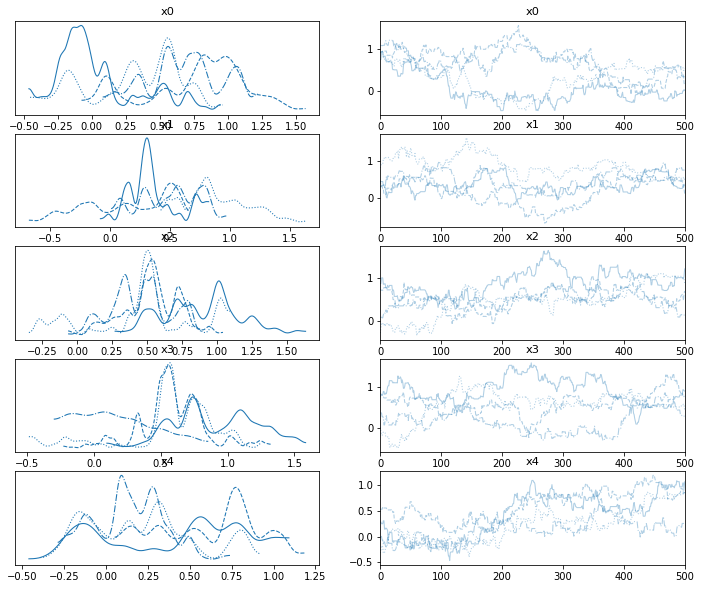

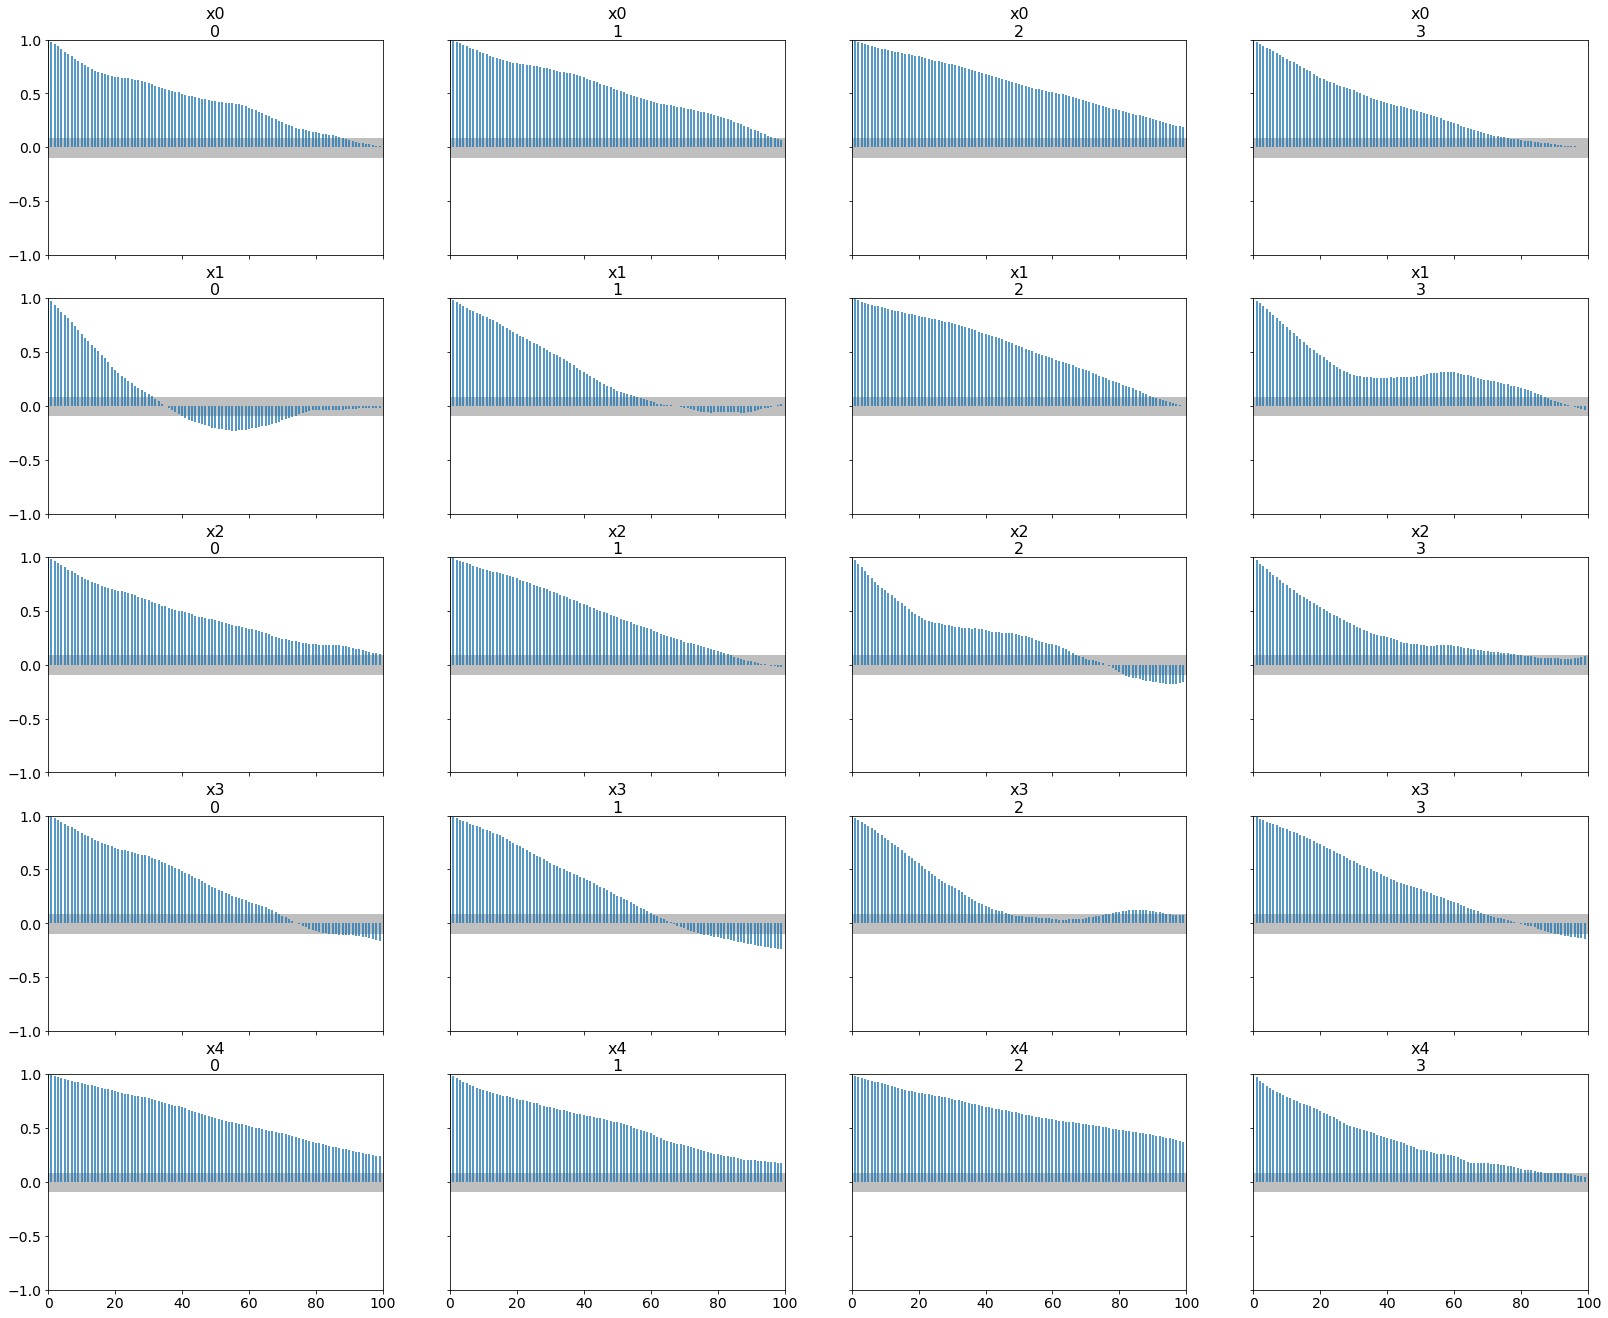

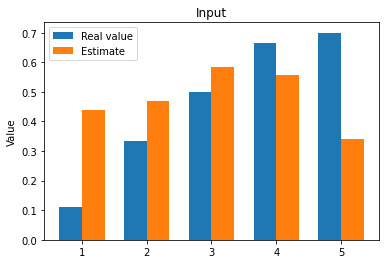

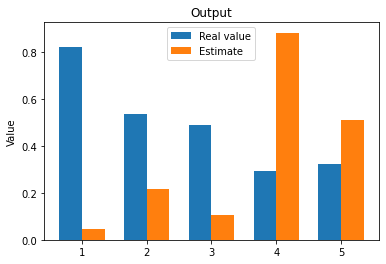

The function inverse took 595.4275839328766 seconds.
real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.60: 100%|██████████| 1000/1000 [02:21<00:00,  7.06it/s]


Sampling chain 2/4


Running chain, α = 0.50: 100%|██████████| 1000/1000 [02:18<00:00,  7.24it/s]


Sampling chain 3/4


Running chain, α = 0.42: 100%|██████████| 1000/1000 [02:27<00:00,  6.77it/s]


Sampling chain 4/4


Running chain, α = 0.39: 100%|██████████| 1000/1000 [02:18<00:00,  7.22it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.386 0.243 0.512 0.483 0.514]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.386  0.311  -0.119    0.980      0.082    0.059      15.0      35.0   
x1  0.243  0.383  -0.376    0.960      0.124    0.095      10.0      22.0   
x2  0.512  0.288  -0.052    0.993      0.081    0.060      12.0      52.0   
x3  0.483  0.305  -0.018    0.997      0.109    0.080       8.0      23.0   
x4  0.514  0.373  -0.262    1.192      0.128    0.094       9.0      42.0   

    r_hat  
x0   1.19  
x1   1.35  
x2   1.28  
x3   1.44  
x4   1.38  
Autocorrelation...
[0.27366 0.09    0.012   0.182   0.186  ]


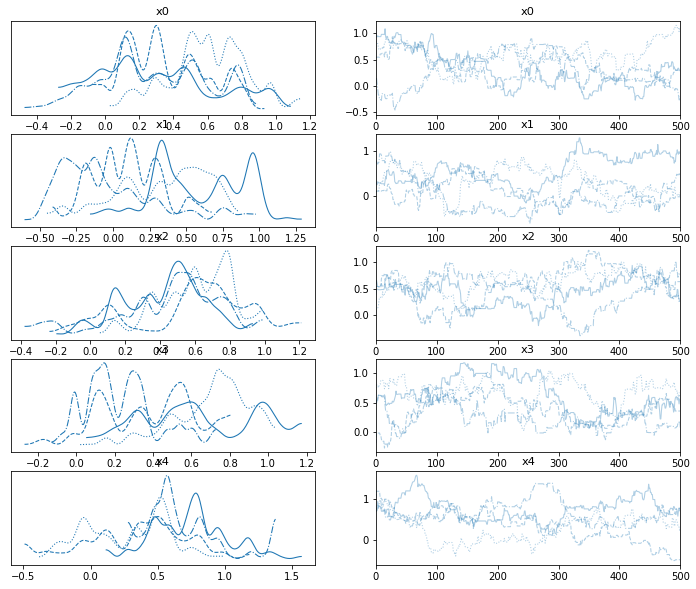

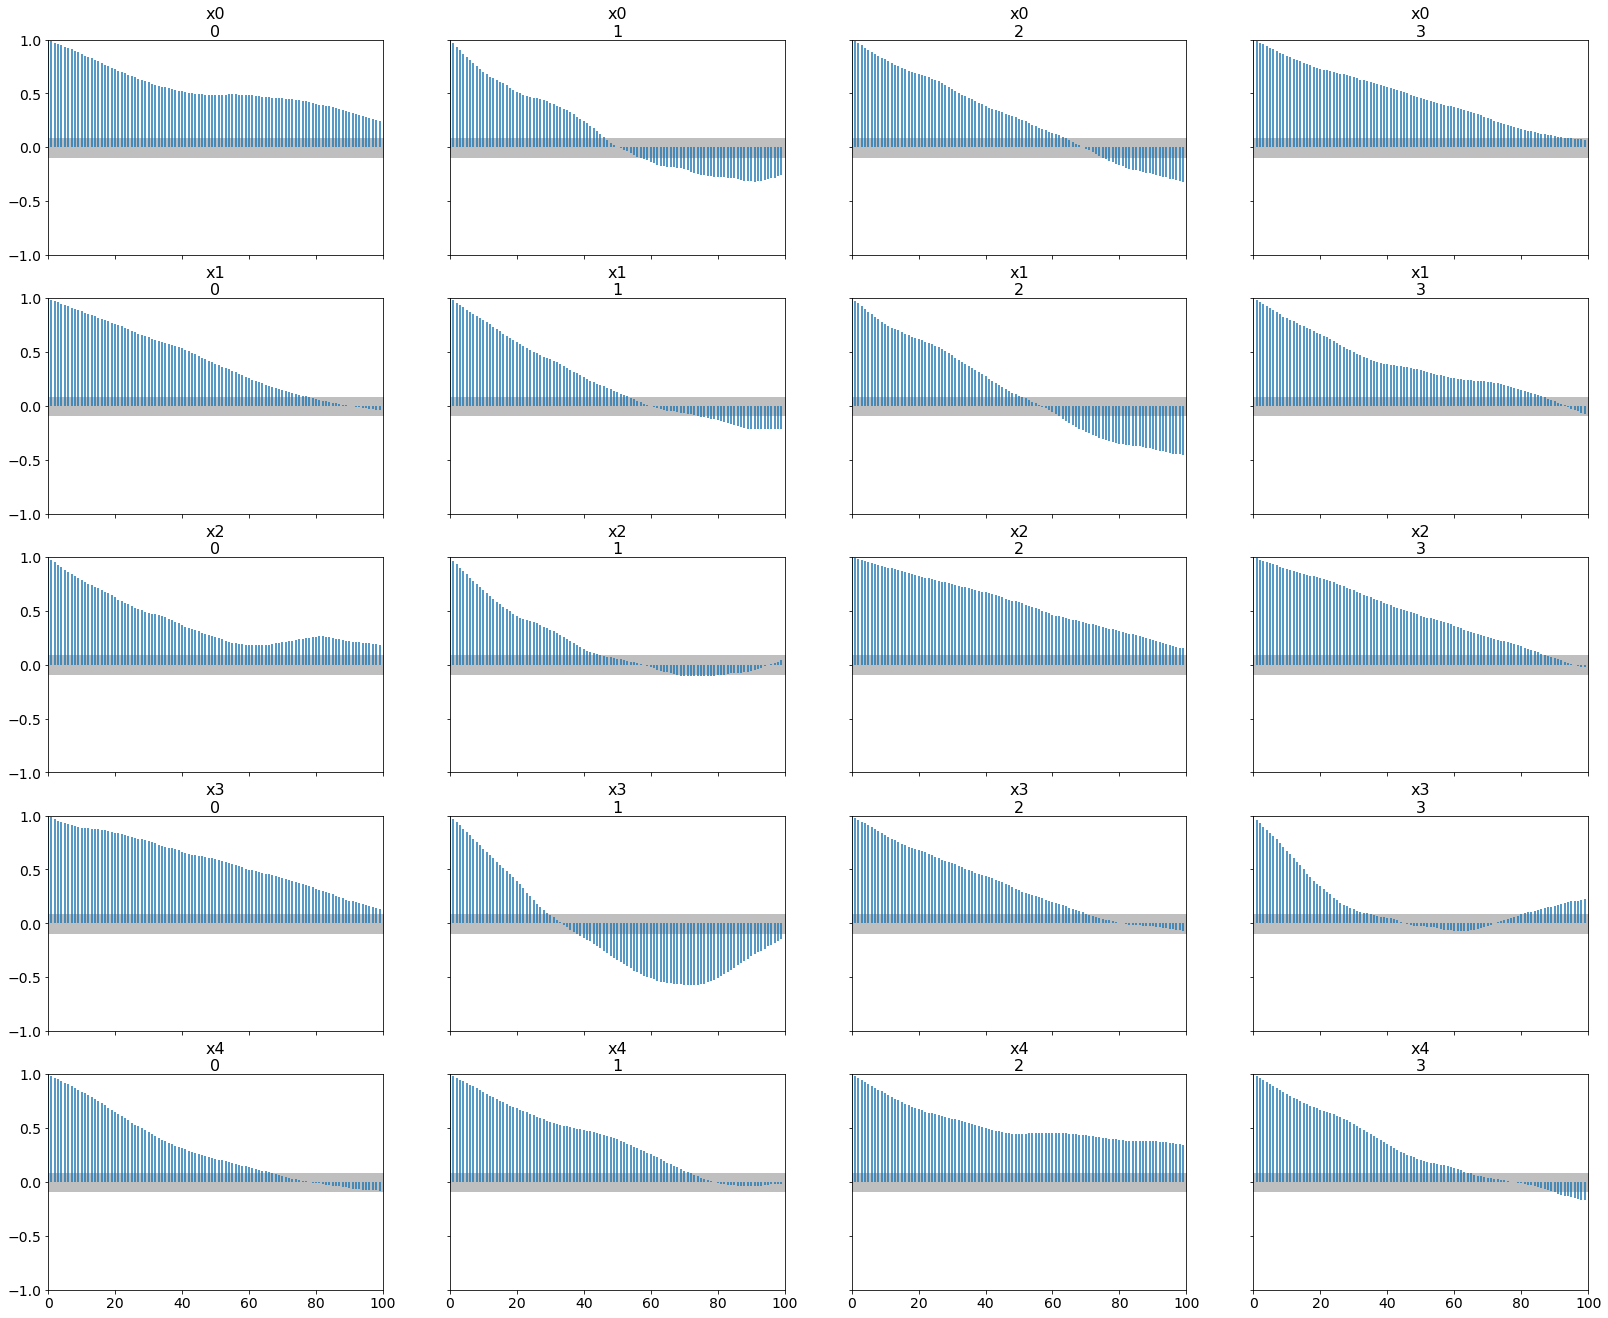

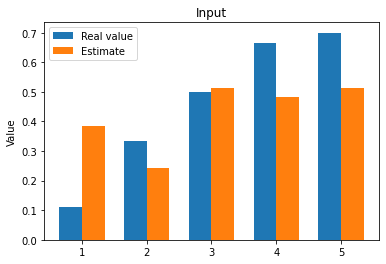

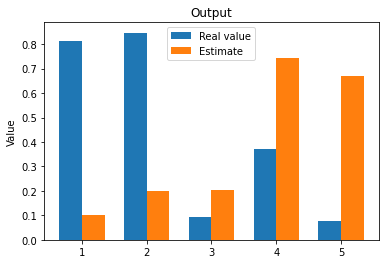

The function inverse took 613.3944070339203 seconds.
real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.69: 100%|██████████| 1000/1000 [02:23<00:00,  6.99it/s]


Sampling chain 2/4


Running chain, α = 0.60: 100%|██████████| 1000/1000 [02:31<00:00,  6.62it/s]


Sampling chain 3/4


Running chain, α = 0.70: 100%|██████████| 1000/1000 [02:17<00:00,  7.26it/s]


Sampling chain 4/4


Running chain, α = 0.54: 100%|██████████| 1000/1000 [02:17<00:00,  7.29it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.283 0.414 0.448 0.424 0.509]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.283  0.414  -0.412    1.007      0.163    0.121       7.0      15.0   
x1  0.414  0.232   0.055    0.804      0.056    0.041      18.0      55.0   
x2  0.448  0.287   0.042    1.042      0.086    0.062      11.0      36.0   
x3  0.424  0.236   0.093    0.967      0.055    0.041      22.0      21.0   
x4  0.509  0.244   0.065    0.949      0.062    0.045      16.0      39.0   

    r_hat  
x0   1.61  
x1   1.18  
x2   1.30  
x3   1.16  
x4   1.18  
Autocorrelation...
[0.17066 0.081   0.052   0.241   0.191  ]


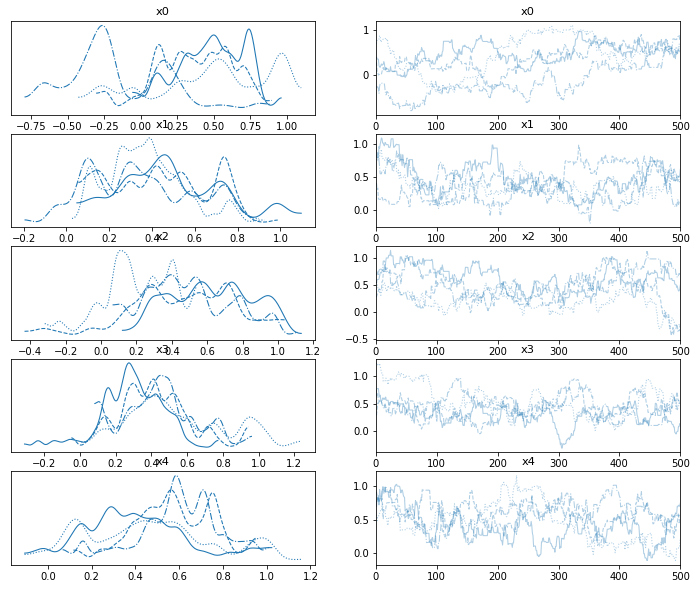

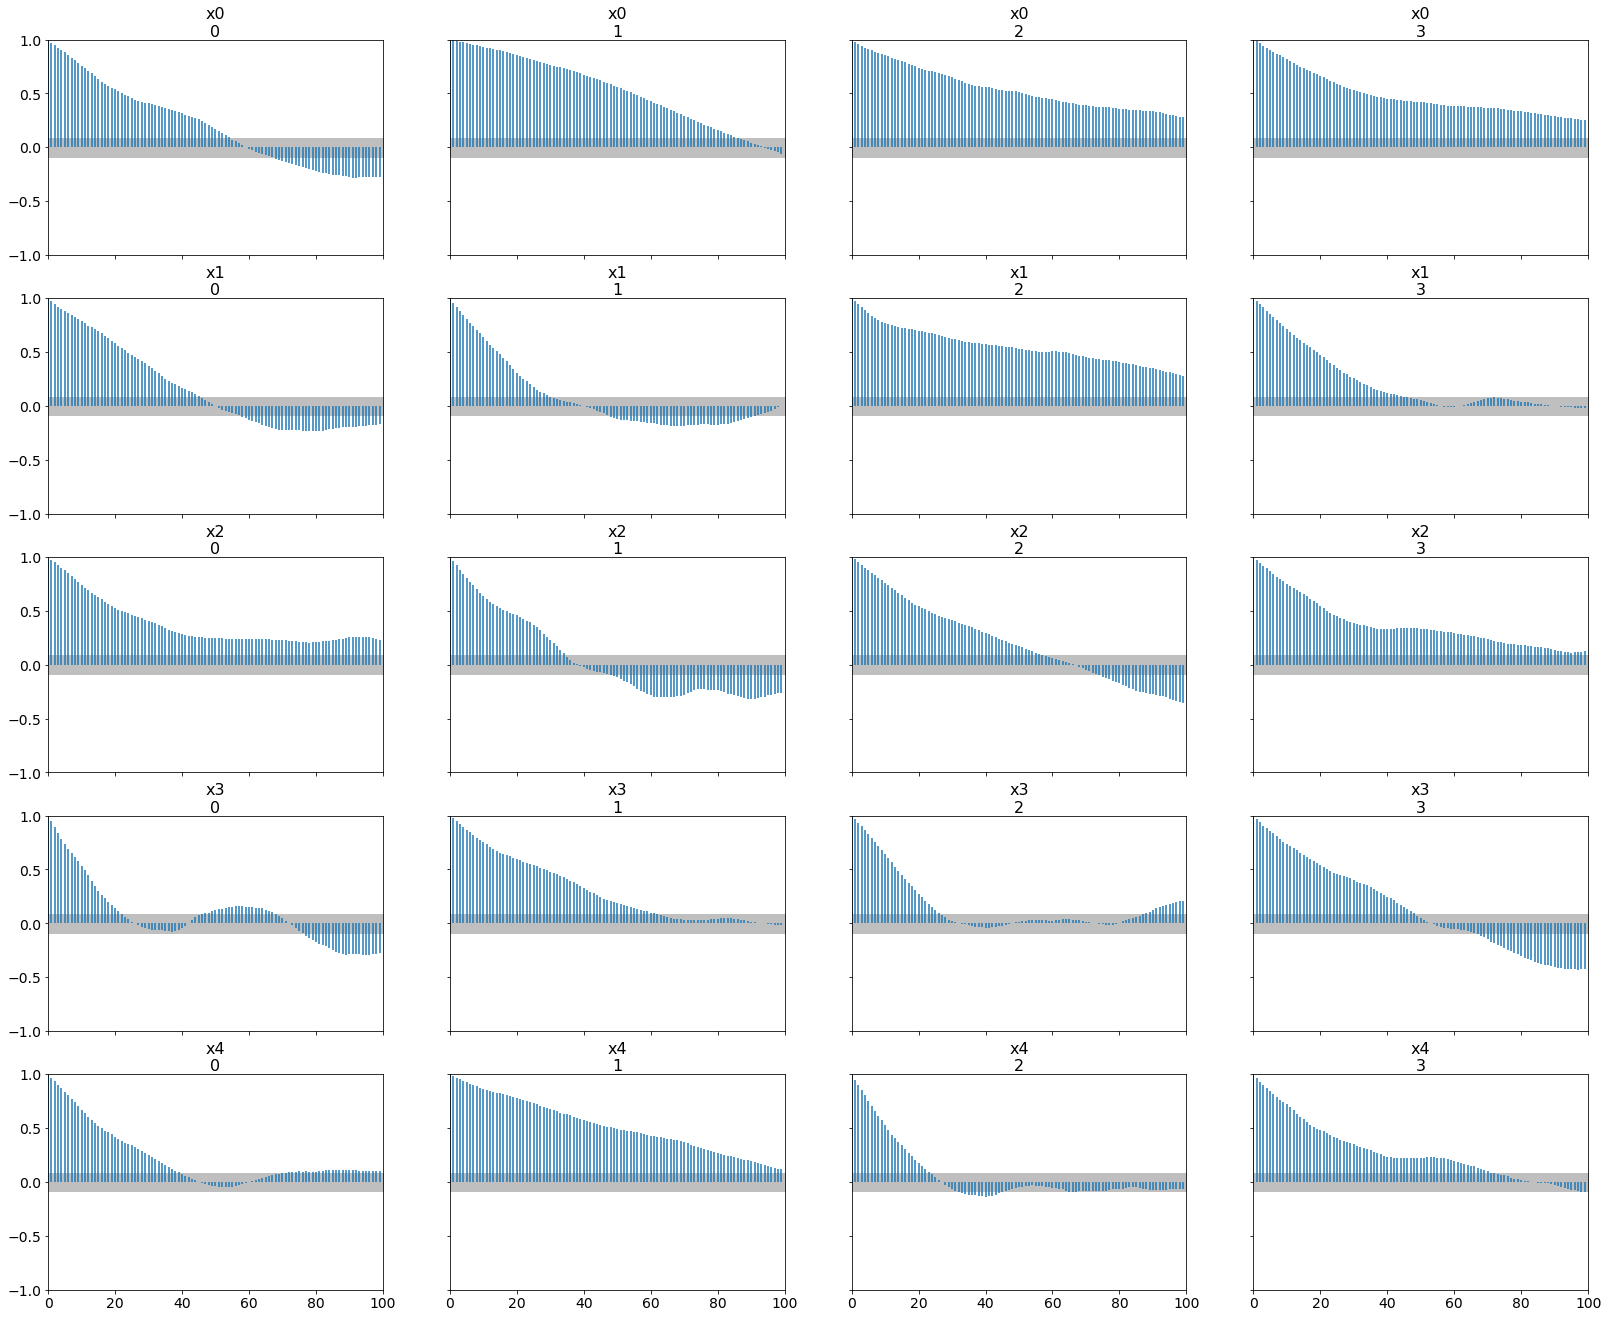

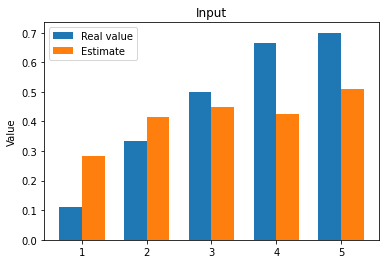

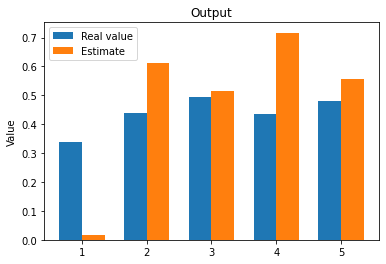

The function inverse took 663.97567486763 seconds.


In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="RW")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.27: 100%|██████████| 1000/1000 [02:18<00:00,  7.20it/s]


Sampling chain 2/4


Running chain, α = 0.28: 100%|██████████| 1000/1000 [02:17<00:00,  7.27it/s]


Sampling chain 3/4


Running chain, α = 0.23: 100%|██████████| 1000/1000 [02:19<00:00,  7.16it/s]


Sampling chain 4/4


Running chain, α = 0.31: 100%|██████████| 1000/1000 [02:27<00:00,  6.79it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.501 0.477 0.494 0.571 0.593]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.501  0.397  -0.173    1.202      0.062    0.044      40.0      49.0   
x1  0.477  0.384  -0.185    1.283      0.052    0.037      55.0     110.0   
x2  0.494  0.400  -0.202    1.280      0.046    0.035      77.0     148.0   
x3  0.571  0.393  -0.186    1.368      0.070    0.050      33.0     114.0   
x4  0.593  0.408  -0.222    1.205      0.055    0.039      56.0     128.0   

    r_hat  
x0   1.07  
x1   1.05  
x2   1.06  
x3   1.12  
x4   1.03  
Autocorrelation...
[0.38866 0.144   0.006   0.094   0.107  ]


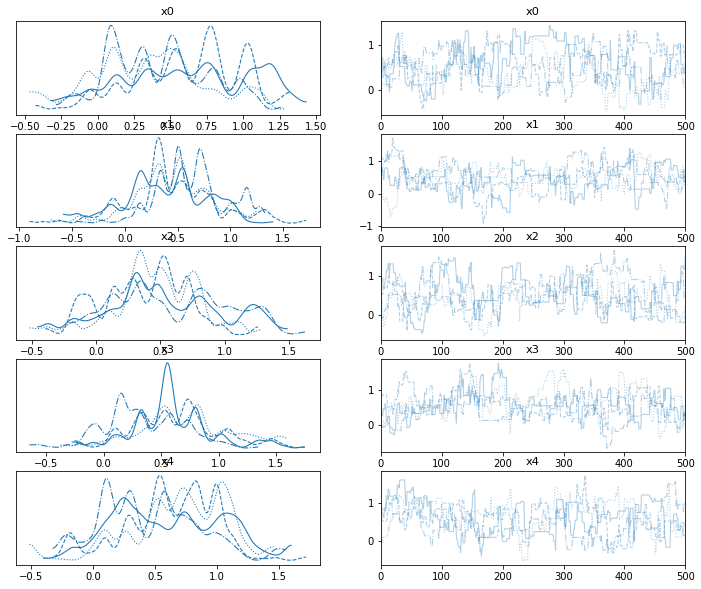

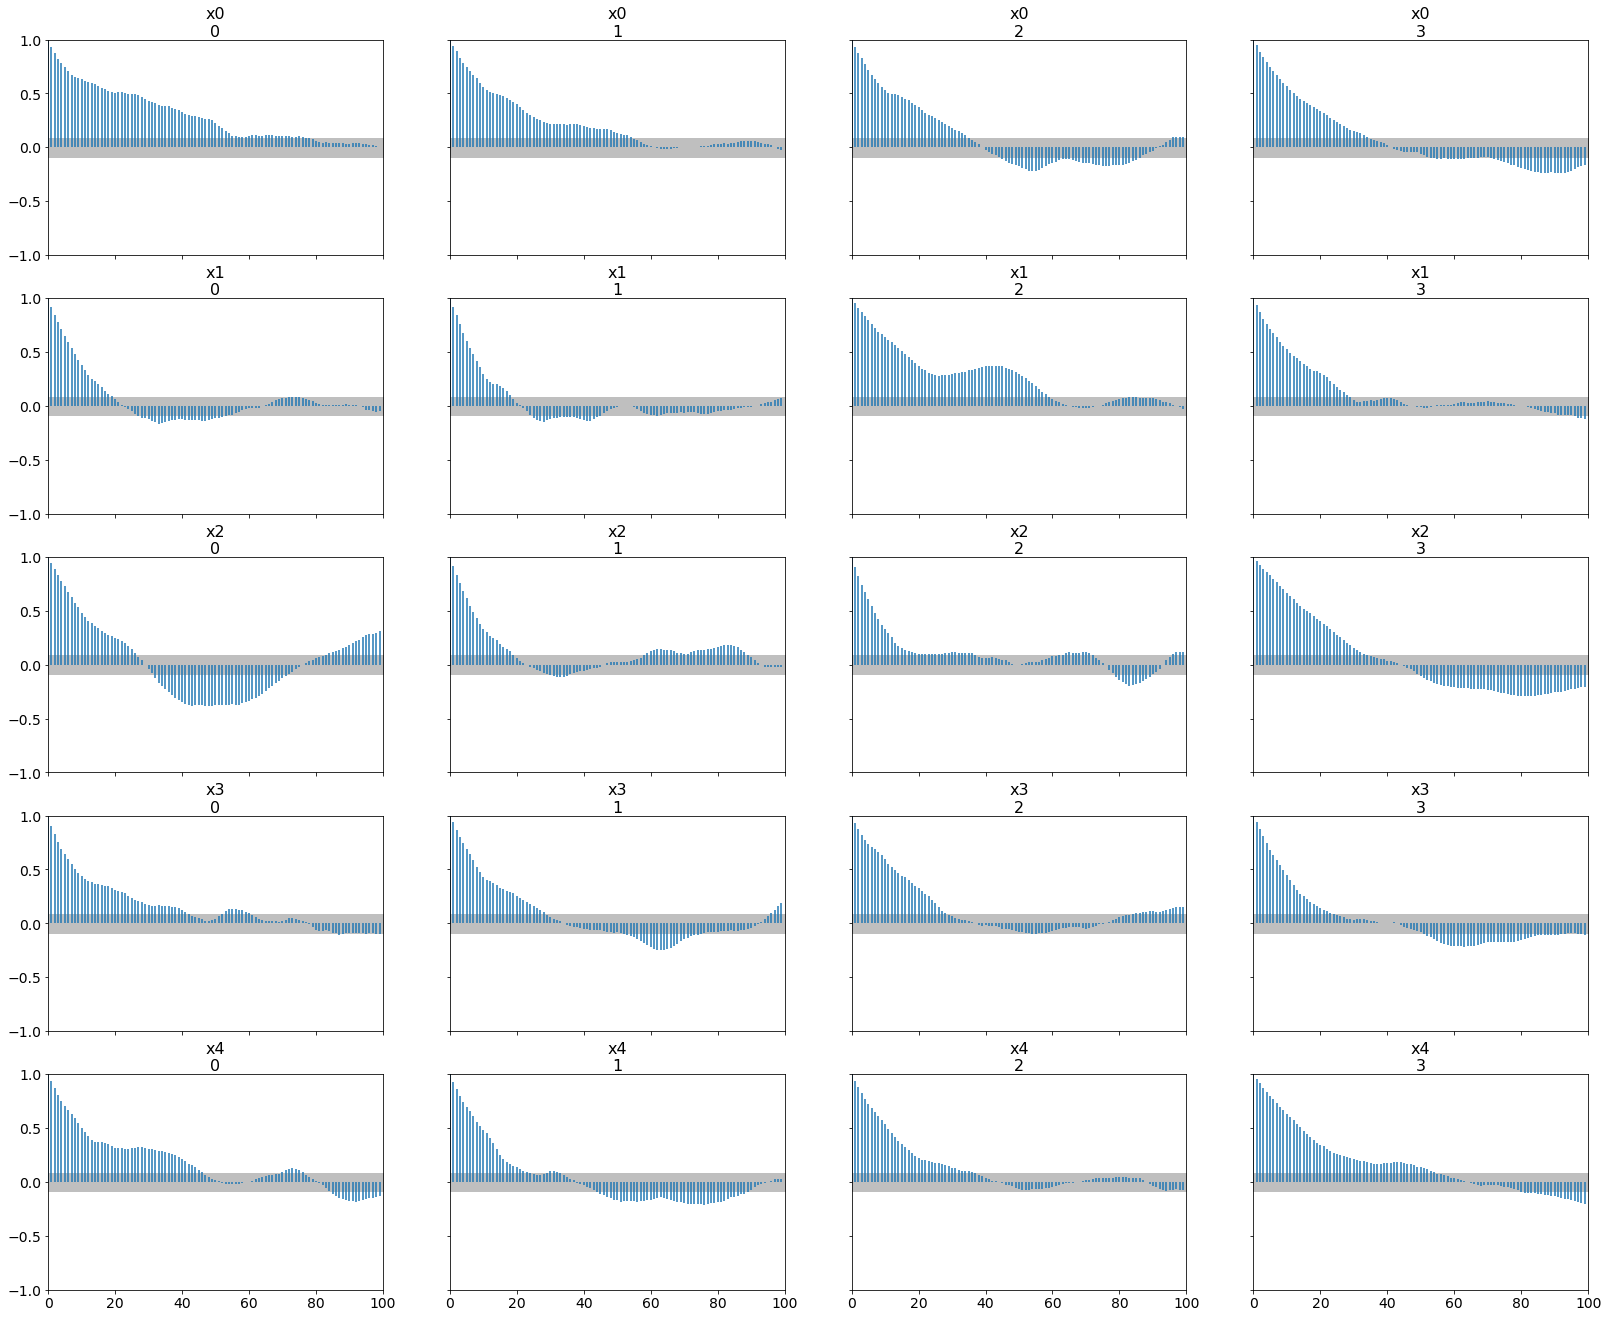

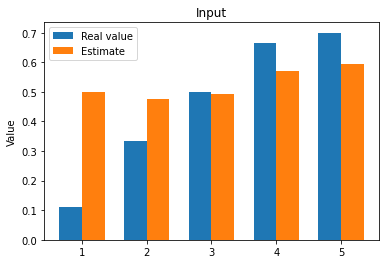

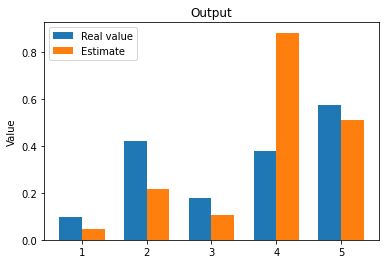

The function inverse took 628.3556795120239 seconds.
real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.21: 100%|██████████| 1000/1000 [02:27<00:00,  6.78it/s]


Sampling chain 2/4


Running chain, α = 0.44: 100%|██████████| 1000/1000 [02:27<00:00,  6.76it/s]


Sampling chain 3/4


Running chain, α = 0.31: 100%|██████████| 1000/1000 [02:28<00:00,  6.73it/s]


Sampling chain 4/4


Running chain, α = 0.38: 100%|██████████| 1000/1000 [03:08<00:00,  5.32it/s] 
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.498 0.52  0.402 0.567 0.482]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.498  0.321  -0.150    0.993      0.031    0.022     105.0     142.0   
x1  0.520  0.347  -0.246    1.046      0.048    0.034      57.0      42.0   
x2  0.402  0.333  -0.212    0.987      0.064    0.046      33.0     102.0   
x3  0.567  0.337  -0.022    1.200      0.040    0.029      67.0      63.0   
x4  0.482  0.346  -0.215    1.015      0.059    0.042      41.0      85.0   

    r_hat  
x0   1.02  
x1   1.07  
x2   1.12  
x3   1.07  
x4   1.13  
Autocorrelation...
[0.38566 0.187   0.098   0.098   0.218  ]


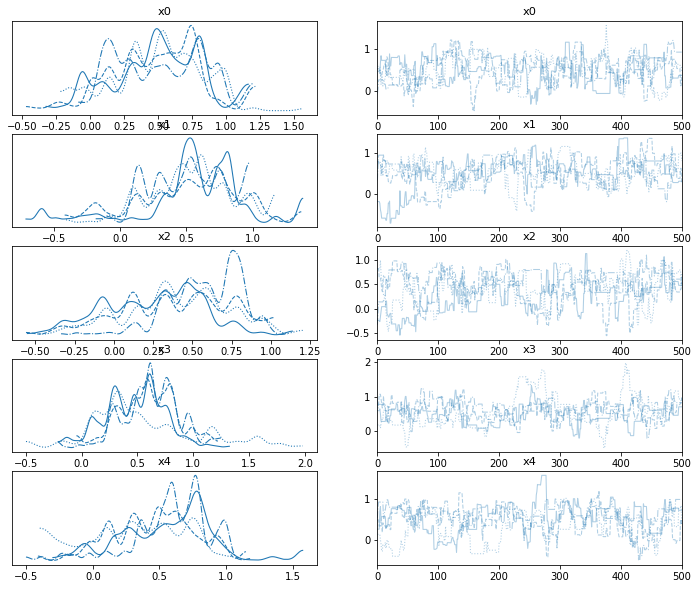

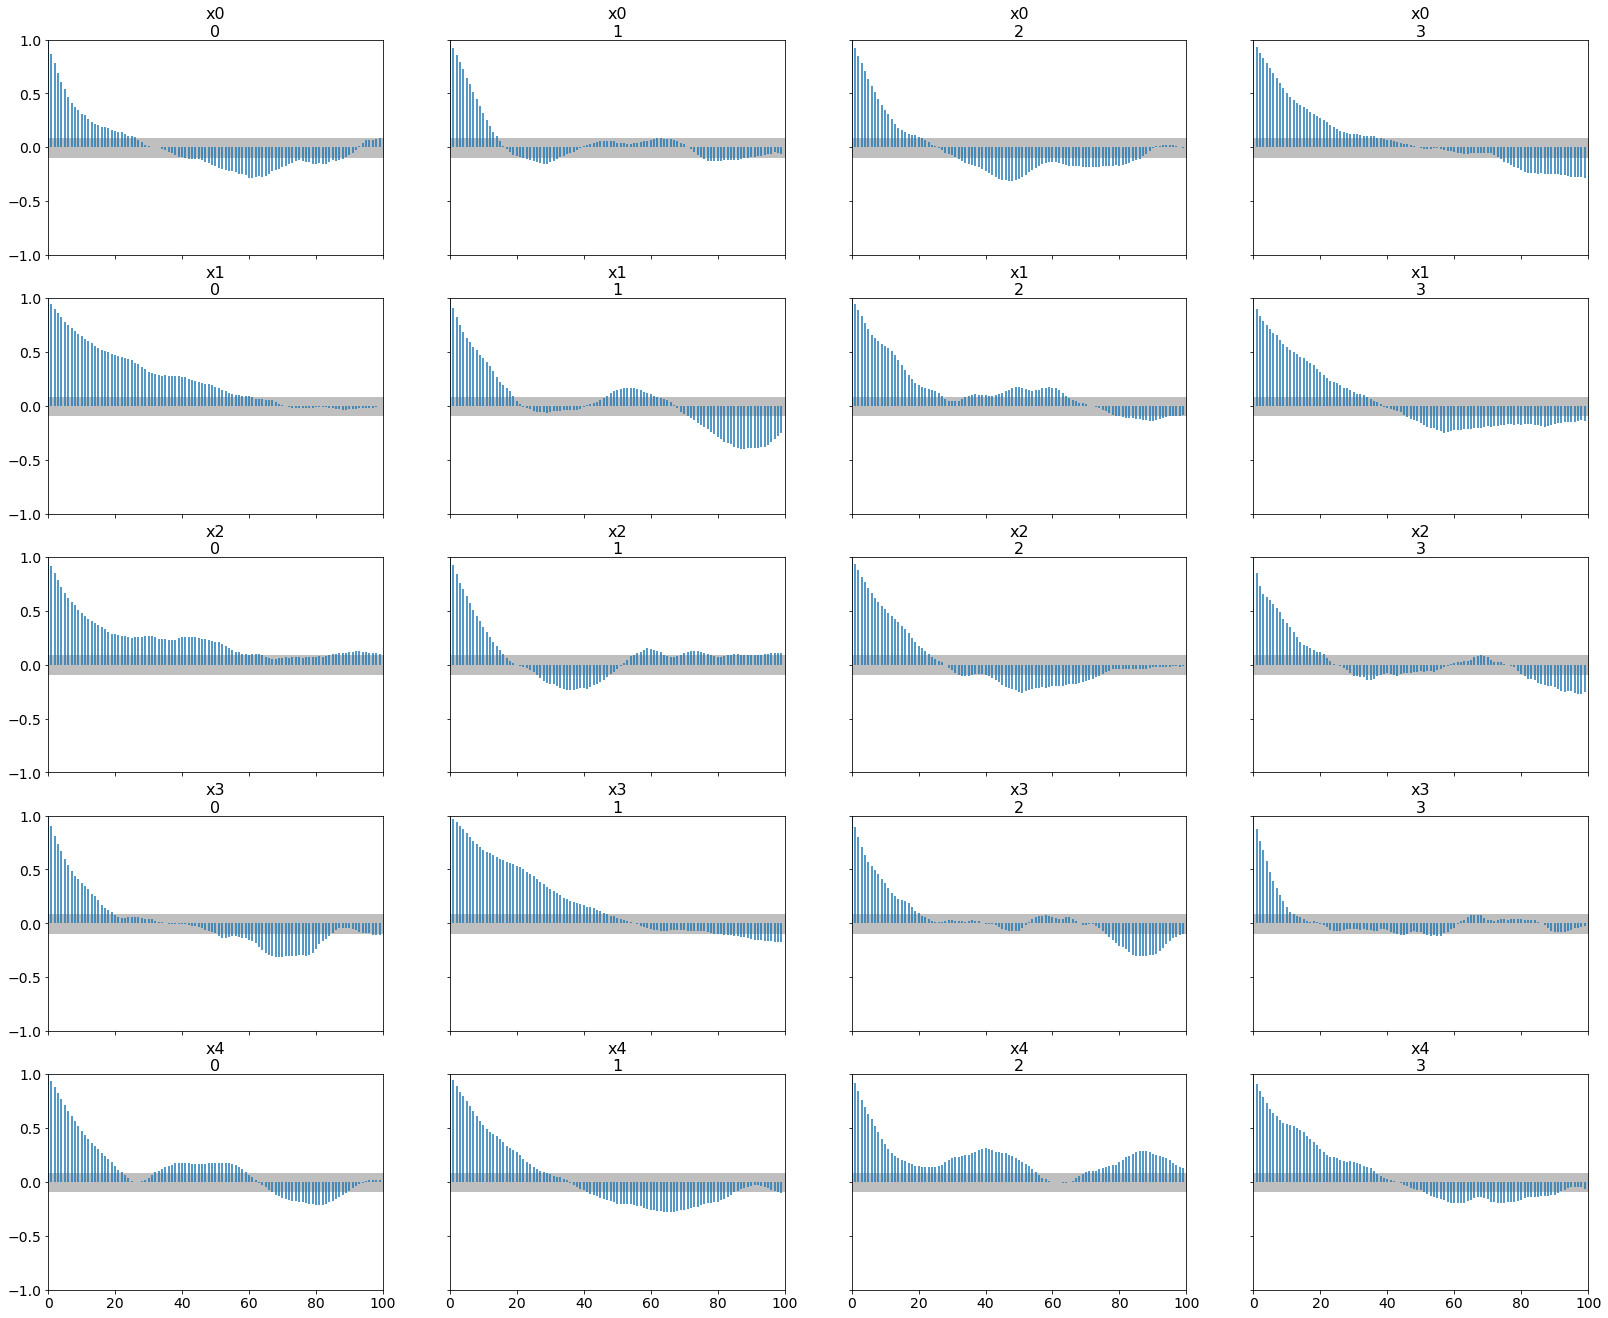

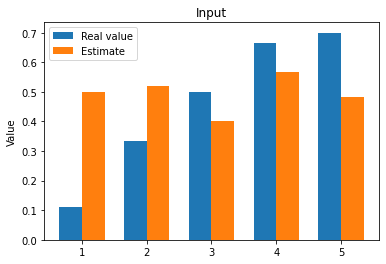

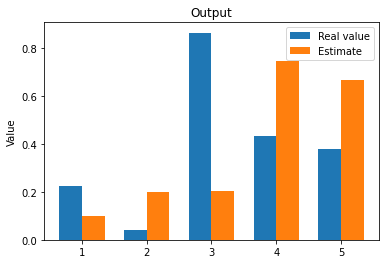

The function inverse took 677.3203566074371 seconds.
real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.24: 100%|██████████| 1000/1000 [02:18<00:00,  7.23it/s]


Sampling chain 2/4


Running chain, α = 0.20: 100%|██████████| 1000/1000 [02:17<00:00,  7.26it/s]


Sampling chain 3/4


Running chain, α = 0.17: 100%|██████████| 1000/1000 [02:18<00:00,  7.23it/s]


Sampling chain 4/4


Running chain, α = 0.27: 100%|██████████| 1000/1000 [02:19<00:00,  7.16it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.488 0.464 0.422 0.476 0.546]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.488  0.377  -0.340    1.028      0.048    0.038      64.0      55.0   
x1  0.464  0.349  -0.091    1.177      0.041    0.029      73.0     128.0   
x2  0.422  0.359  -0.245    1.040      0.055    0.039      40.0      71.0   
x3  0.476  0.322   0.048    1.282      0.029    0.021     122.0     134.0   
x4  0.546  0.387  -0.421    1.046      0.046    0.036      78.0      59.0   

    r_hat  
x0   1.07  
x1   1.04  
x2   1.08  
x3   1.04  
x4   1.05  
Autocorrelation...
[0.37566 0.131   0.078   0.189   0.154  ]


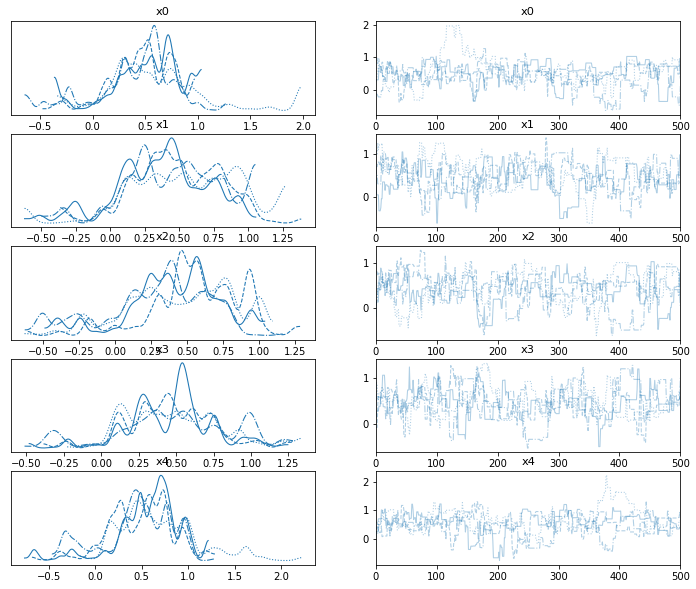

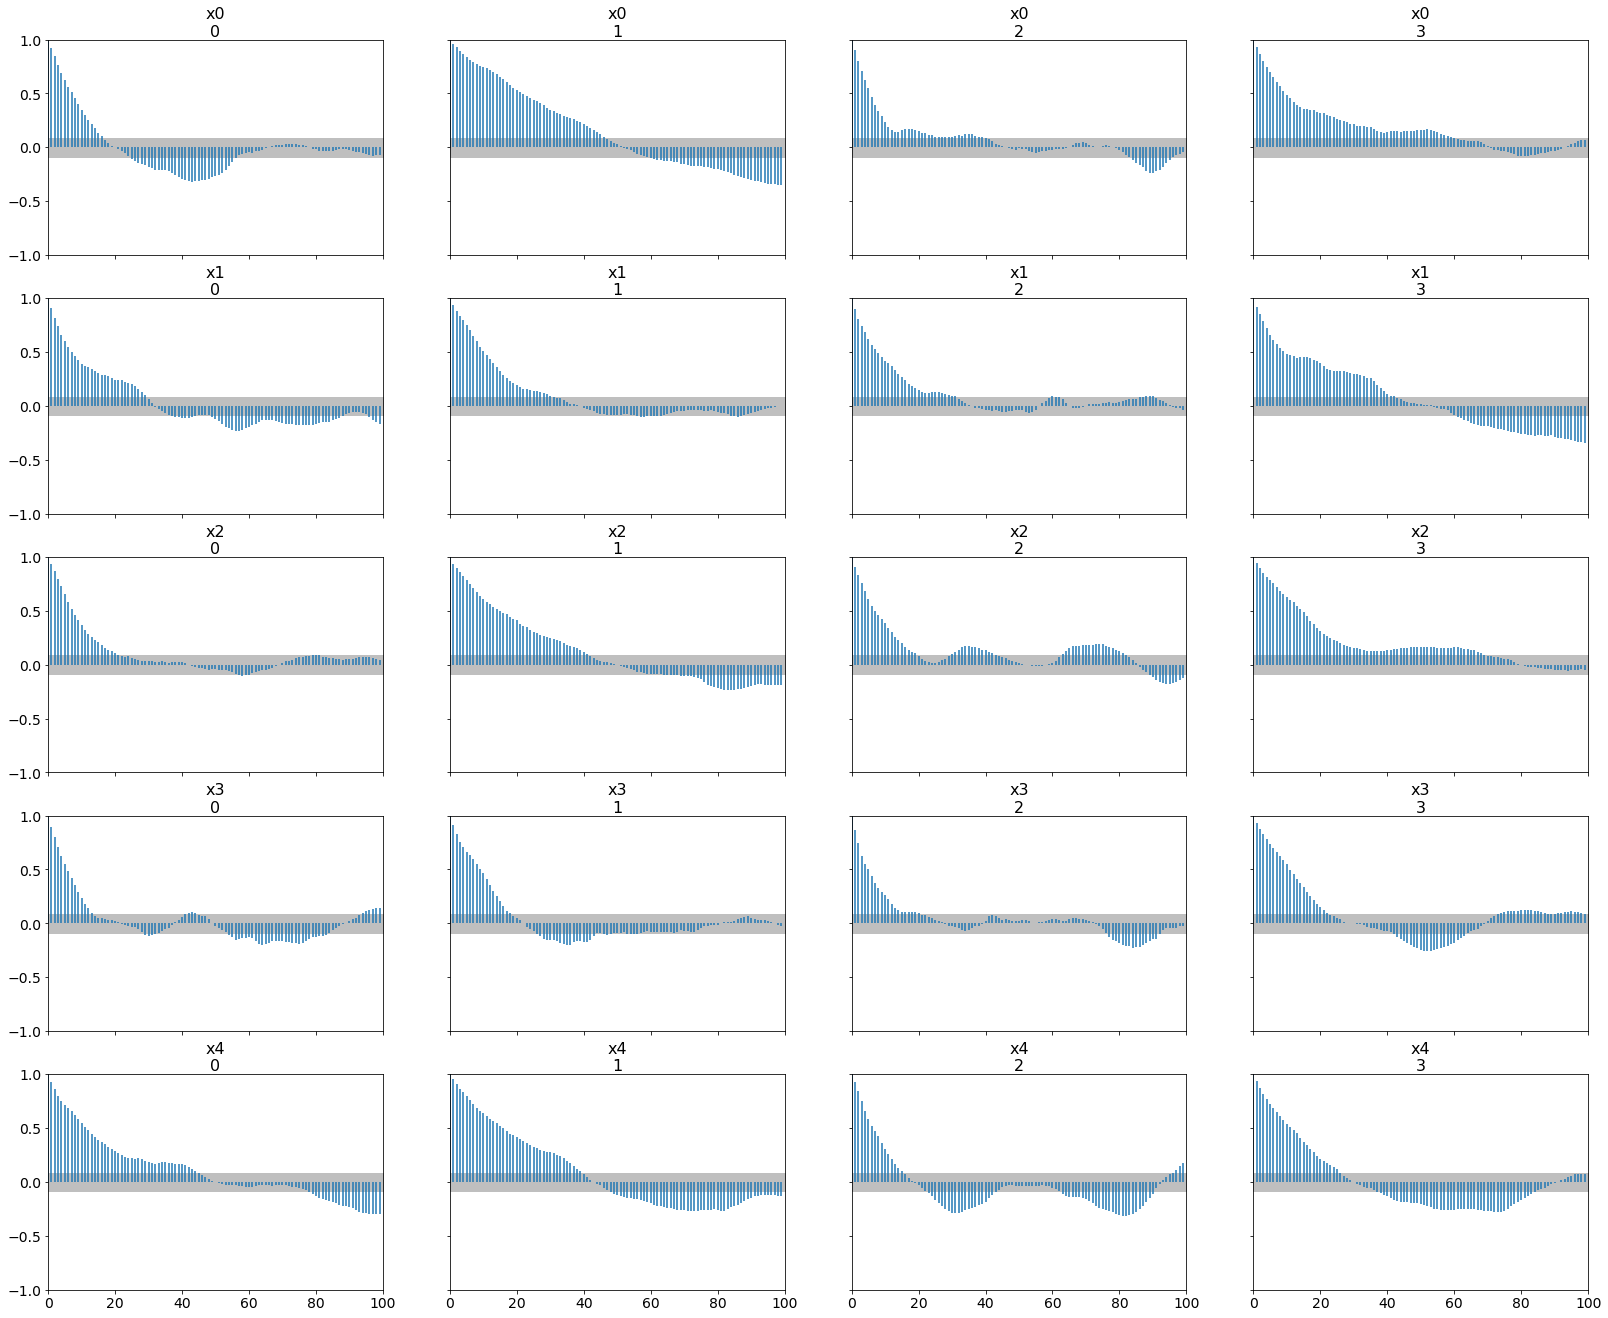

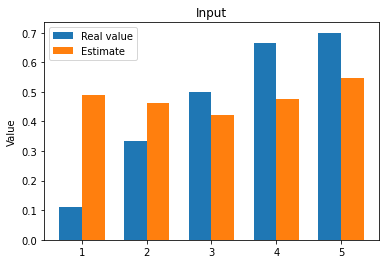

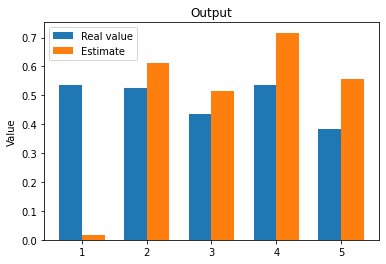

The function inverse took 616.5592901706696 seconds.


In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = True
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="RW")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.40: 100%|██████████| 2000/2000 [04:55<00:00,  6.76it/s]


Sampling chain 2/4


Running chain, α = 0.35: 100%|██████████| 2000/2000 [05:08<00:00,  6.48it/s]


Sampling chain 3/4


Running chain, α = 0.32: 100%|██████████| 2000/2000 [05:10<00:00,  6.44it/s]


Sampling chain 4/4


Running chain, α = 0.37: 100%|██████████| 2000/2000 [05:22<00:00,  6.20it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.5   0.567 0.64  0.66  0.524]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.500  0.311  -0.005    1.148      0.031    0.022     100.0     257.0   
x1  0.567  0.341  -0.054    1.163      0.074    0.053      22.0     168.0   
x2  0.640  0.349   0.087    1.336      0.053    0.038      44.0     164.0   
x3  0.660  0.354   0.059    1.322      0.051    0.037      51.0     128.0   
x4  0.524  0.374  -0.202    1.193      0.036    0.026     110.0     229.0   

    r_hat  
x0   1.04  
x1   1.13  
x2   1.09  
x3   1.10  
x4   1.05  
Autocorrelation...
[0.38766 0.234   0.14    0.005   0.176  ]


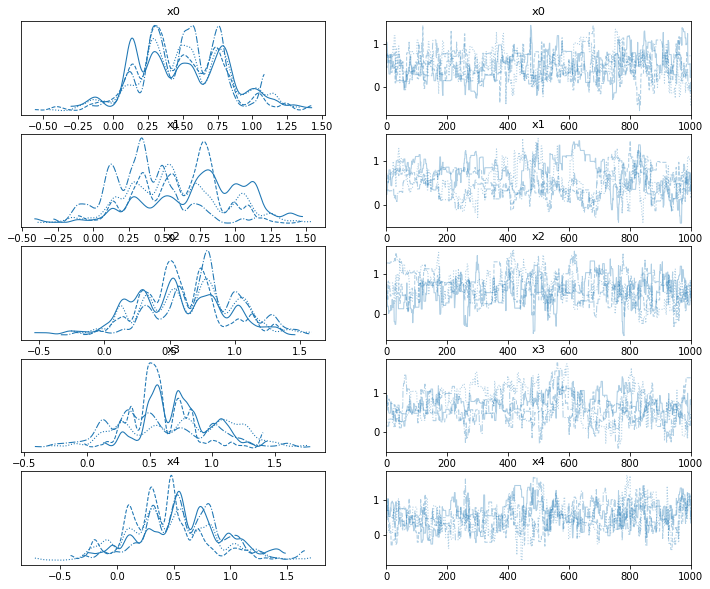

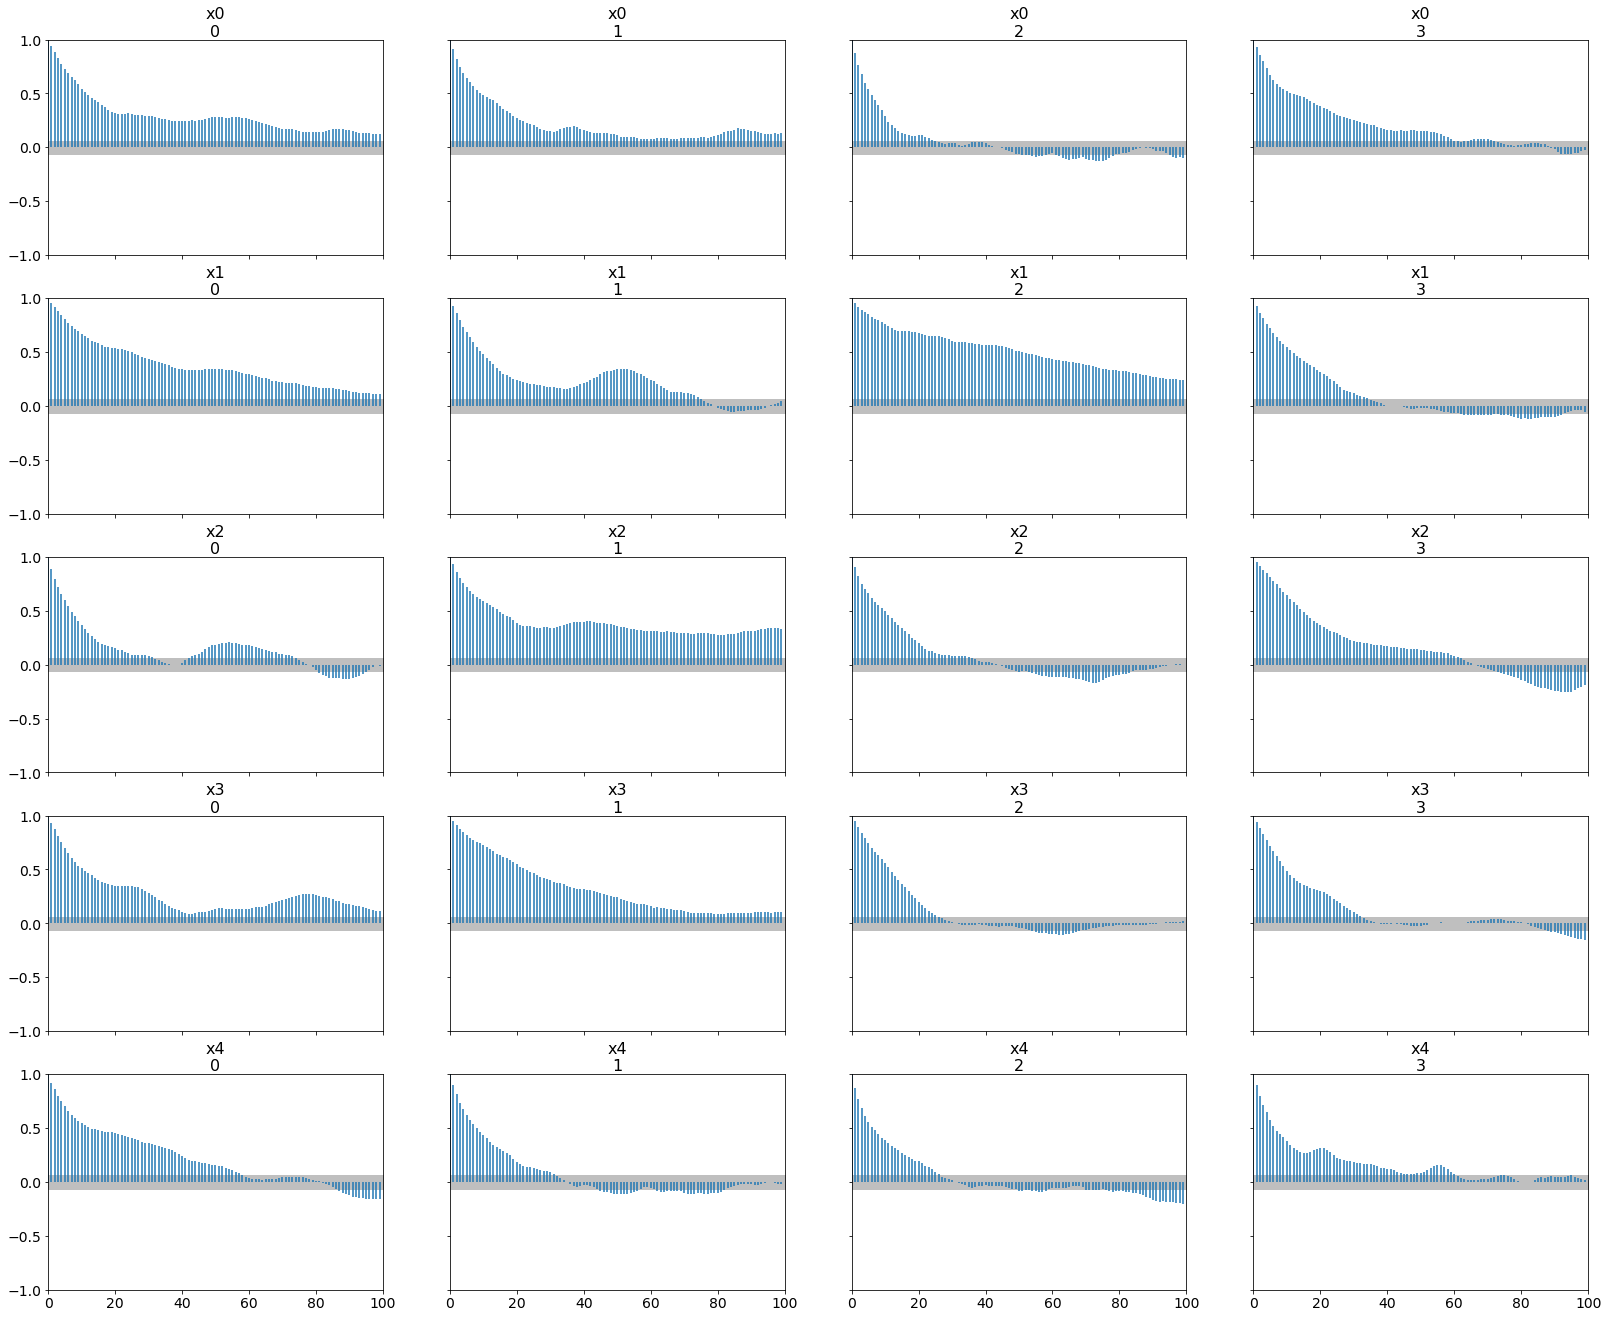

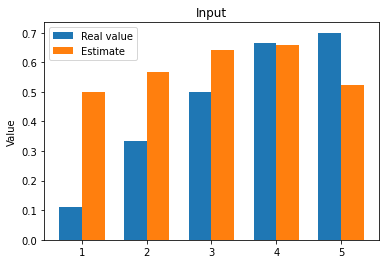

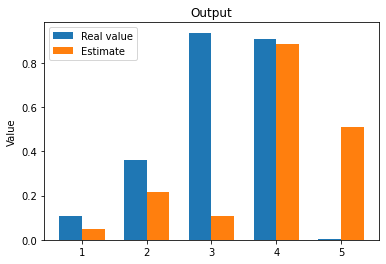

The function inverse took 1364.1761486530304 seconds.
real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.35: 100%|██████████| 2000/2000 [05:19<00:00,  6.26it/s]


Sampling chain 2/4


Running chain, α = 0.34: 100%|██████████| 2000/2000 [05:22<00:00,  6.21it/s]


Sampling chain 3/4


Running chain, α = 0.31:  76%|███████▌  | 1523/2000 [04:15<01:19,  5.99it/s]

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=2000#4000#8000
burnin=1000#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="AM")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.05: 100%|██████████| 1000/1000 [02:48<00:00,  5.95it/s]


Sampling chain 2/4


Running chain, α = 0.07: 100%|██████████| 1000/1000 [02:41<00:00,  6.19it/s]


Sampling chain 3/4


Running chain, α = 0.02: 100%|██████████| 1000/1000 [02:51<00:00,  5.83it/s]


Sampling chain 4/4


Running chain, α = 0.12: 100%|██████████| 1000/1000 [02:48<00:00,  5.93it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.605 0.52  0.565 0.629 0.688]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.605  0.282   0.076    1.114      0.042    0.031      47.0      69.0   
x1  0.520  0.347  -0.063    1.078      0.055    0.039      40.0      22.0   
x2  0.565  0.284   0.009    0.952      0.068    0.049      16.0      80.0   
x3  0.629  0.378  -0.029    1.290      0.049    0.035      62.0      59.0   
x4  0.688  0.337   0.059    1.310      0.084    0.060      17.0      64.0   

    r_hat  
x0   1.09  
x1   1.06  
x2   1.19  
x3   1.18  
x4   1.20  
Autocorrelation...
[0.49266 0.187   0.065   0.036   0.012  ]


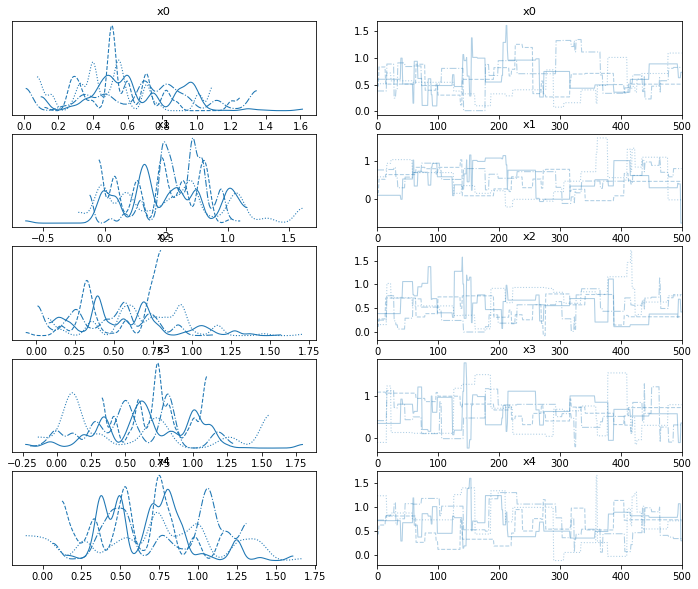

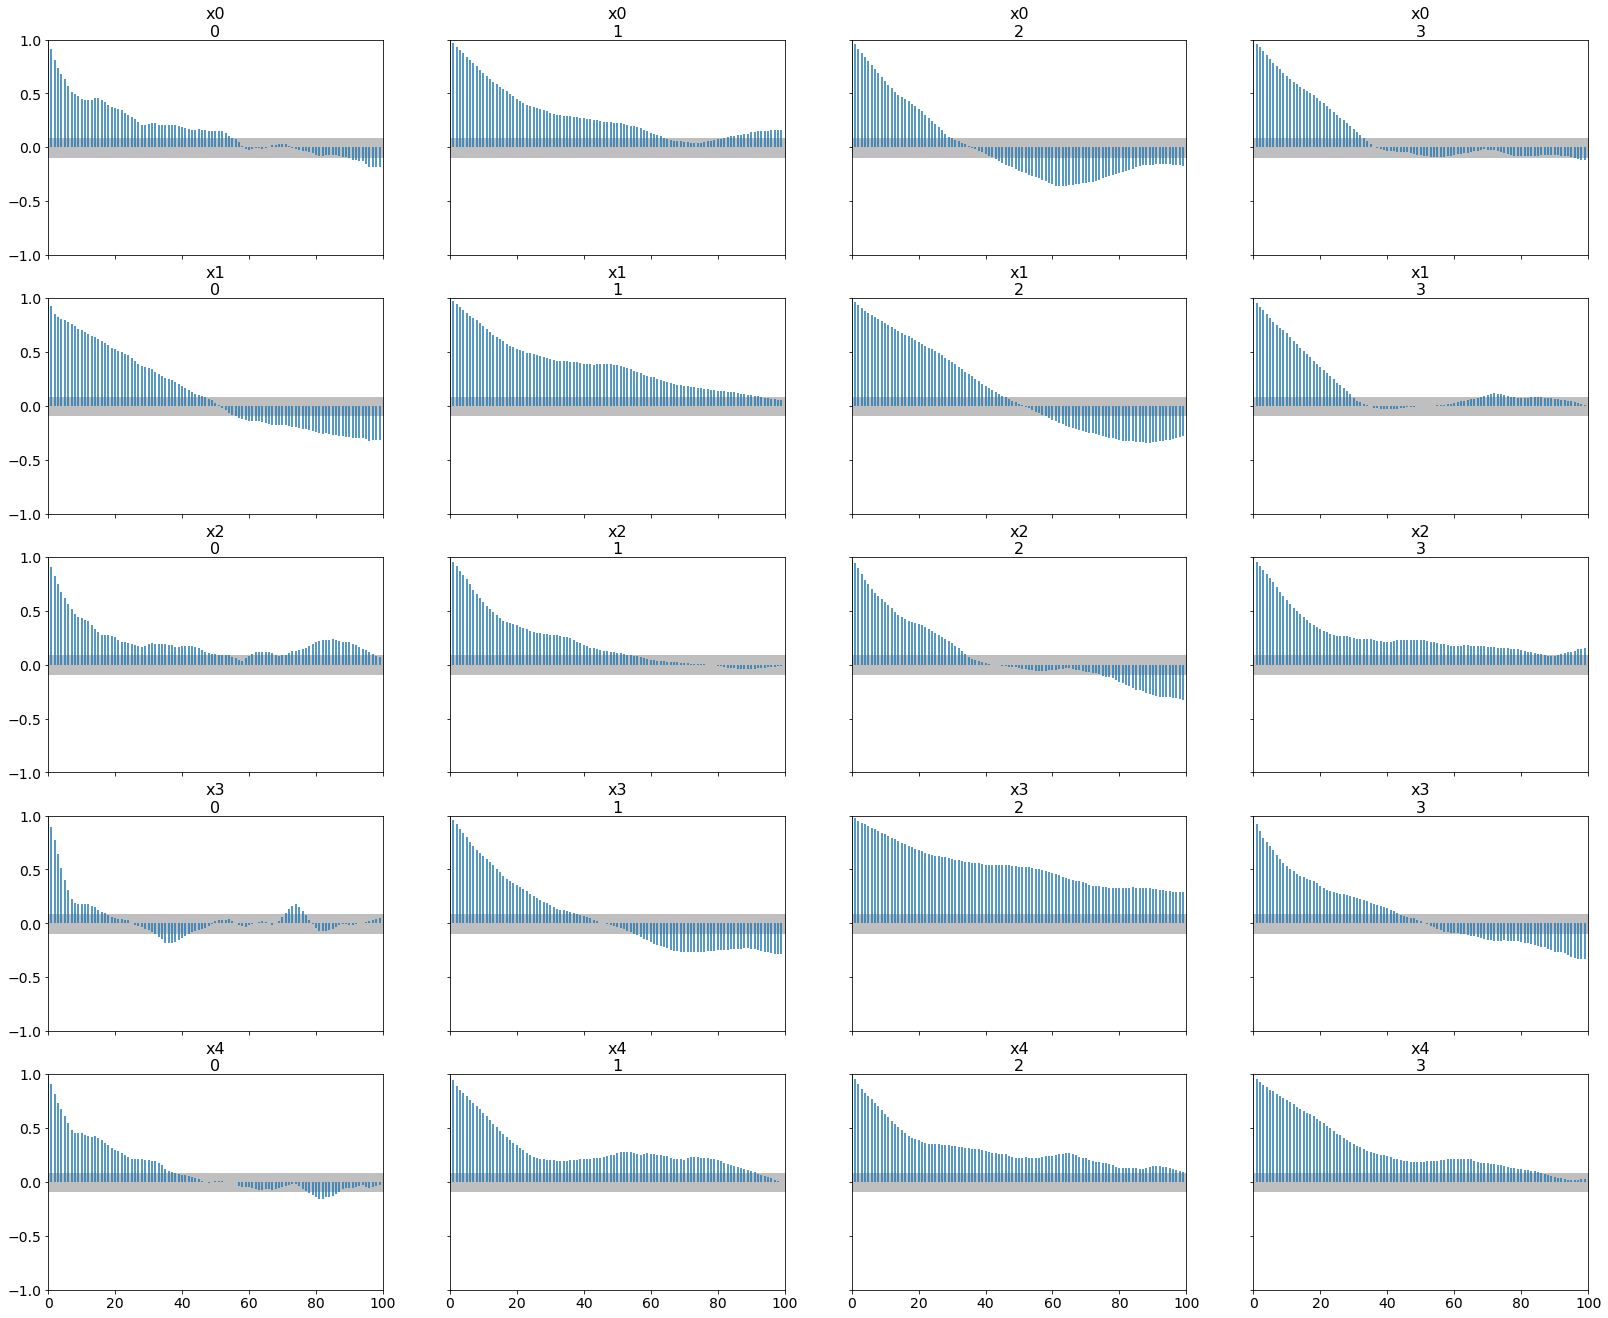

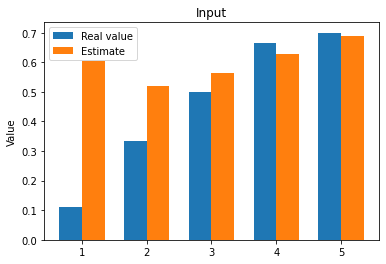

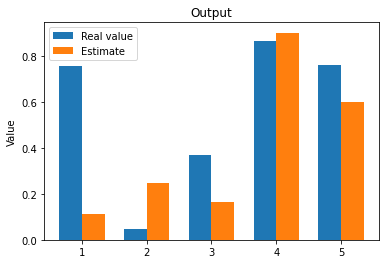

The function inverse took 730.7625484466553 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = True
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="AM")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.75: 100%|██████████| 1000/1000 [02:52<00:00,  5.81it/s]


Sampling chain 2/4


Running chain, α = 0.73: 100%|██████████| 1000/1000 [02:50<00:00,  5.88it/s]


Sampling chain 3/4


Running chain, α = 0.76: 100%|██████████| 1000/1000 [02:57<00:00,  5.63it/s]


Sampling chain 4/4


Running chain, α = 0.70: 100%|██████████| 1000/1000 [03:48<00:00,  4.39it/s] 
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.607 0.431 0.105 0.525 0.25 ]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.607  0.305   0.126    1.035      0.142    0.108       5.0      14.0   
x1  0.431  0.131   0.241    0.702      0.043    0.032      10.0      12.0   
x2  0.105  0.170  -0.115    0.370      0.077    0.058       6.0      39.0   
x3  0.525  0.352   0.111    1.198      0.171    0.131       5.0      21.0   
x4  0.250  0.167  -0.077    0.538      0.069    0.051       6.0      12.0   

    r_hat  
x0   2.19  
x1   1.32  
x2   1.79  
x3   2.28  
x4   1.74  
Autocorrelation...
[0.49466 0.098   0.395   0.14    0.45   ]


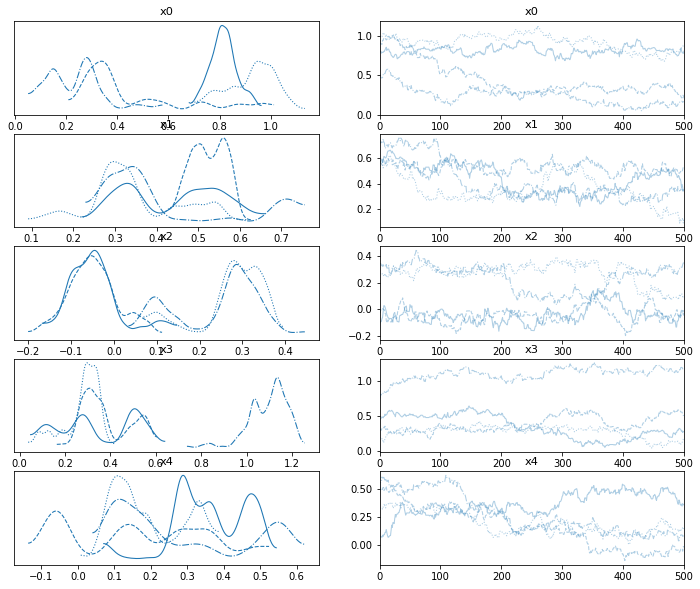

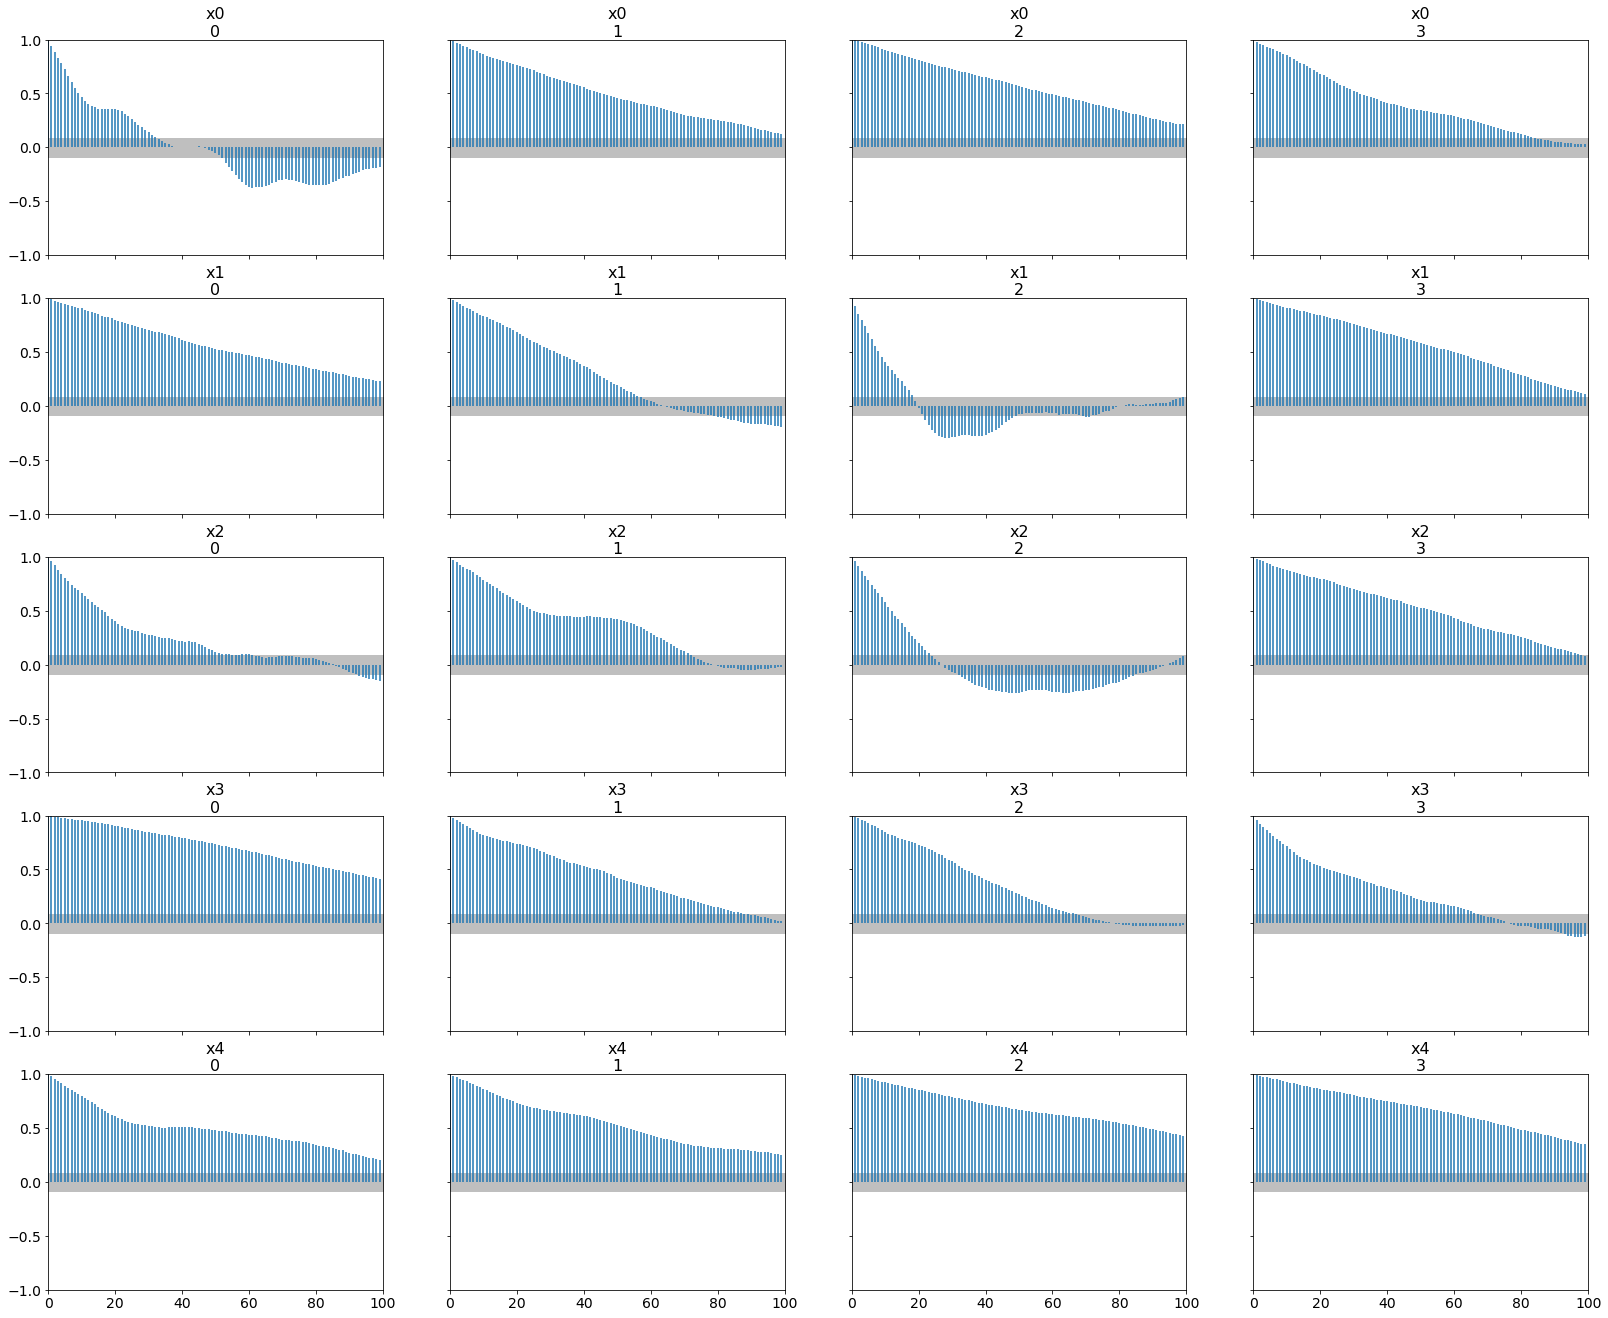

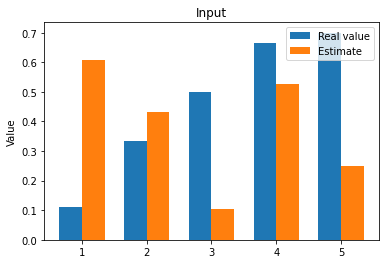

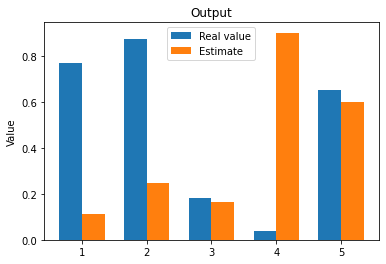

The function inverse took 823.0519914627075 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="CN")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.35: 100%|██████████| 1000/1000 [02:39<00:00,  6.27it/s]


Sampling chain 2/4


Running chain, α = 0.38: 100%|██████████| 1000/1000 [02:42<00:00,  6.14it/s]


Sampling chain 3/4


Running chain, α = 0.30: 100%|██████████| 1000/1000 [02:54<00:00,  5.72it/s]


Sampling chain 4/4


Running chain, α = 0.31: 100%|██████████| 1000/1000 [02:51<00:00,  5.84it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.24  0.076 0.268 0.243 0.181]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.240  0.332  -0.258    0.923      0.045    0.035      54.0      39.0   
x1  0.076  0.412  -0.844    0.792      0.127    0.092      12.0      42.0   
x2  0.268  0.380  -0.206    1.088      0.071    0.061      23.0      47.0   
x3  0.243  0.238  -0.096    0.747      0.029    0.022      72.0      51.0   
x4  0.181  0.321  -0.685    0.711      0.084    0.061      21.0      13.0   

    r_hat  
x0   1.05  
x1   1.25  
x2   1.13  
x3   1.02  
x4   1.14  
Autocorrelation...
[0.12766 0.257   0.232   0.422   0.519  ]


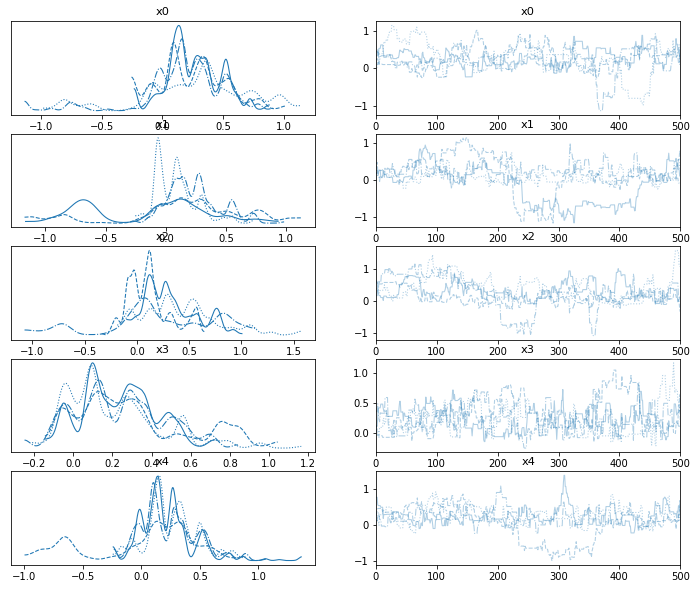

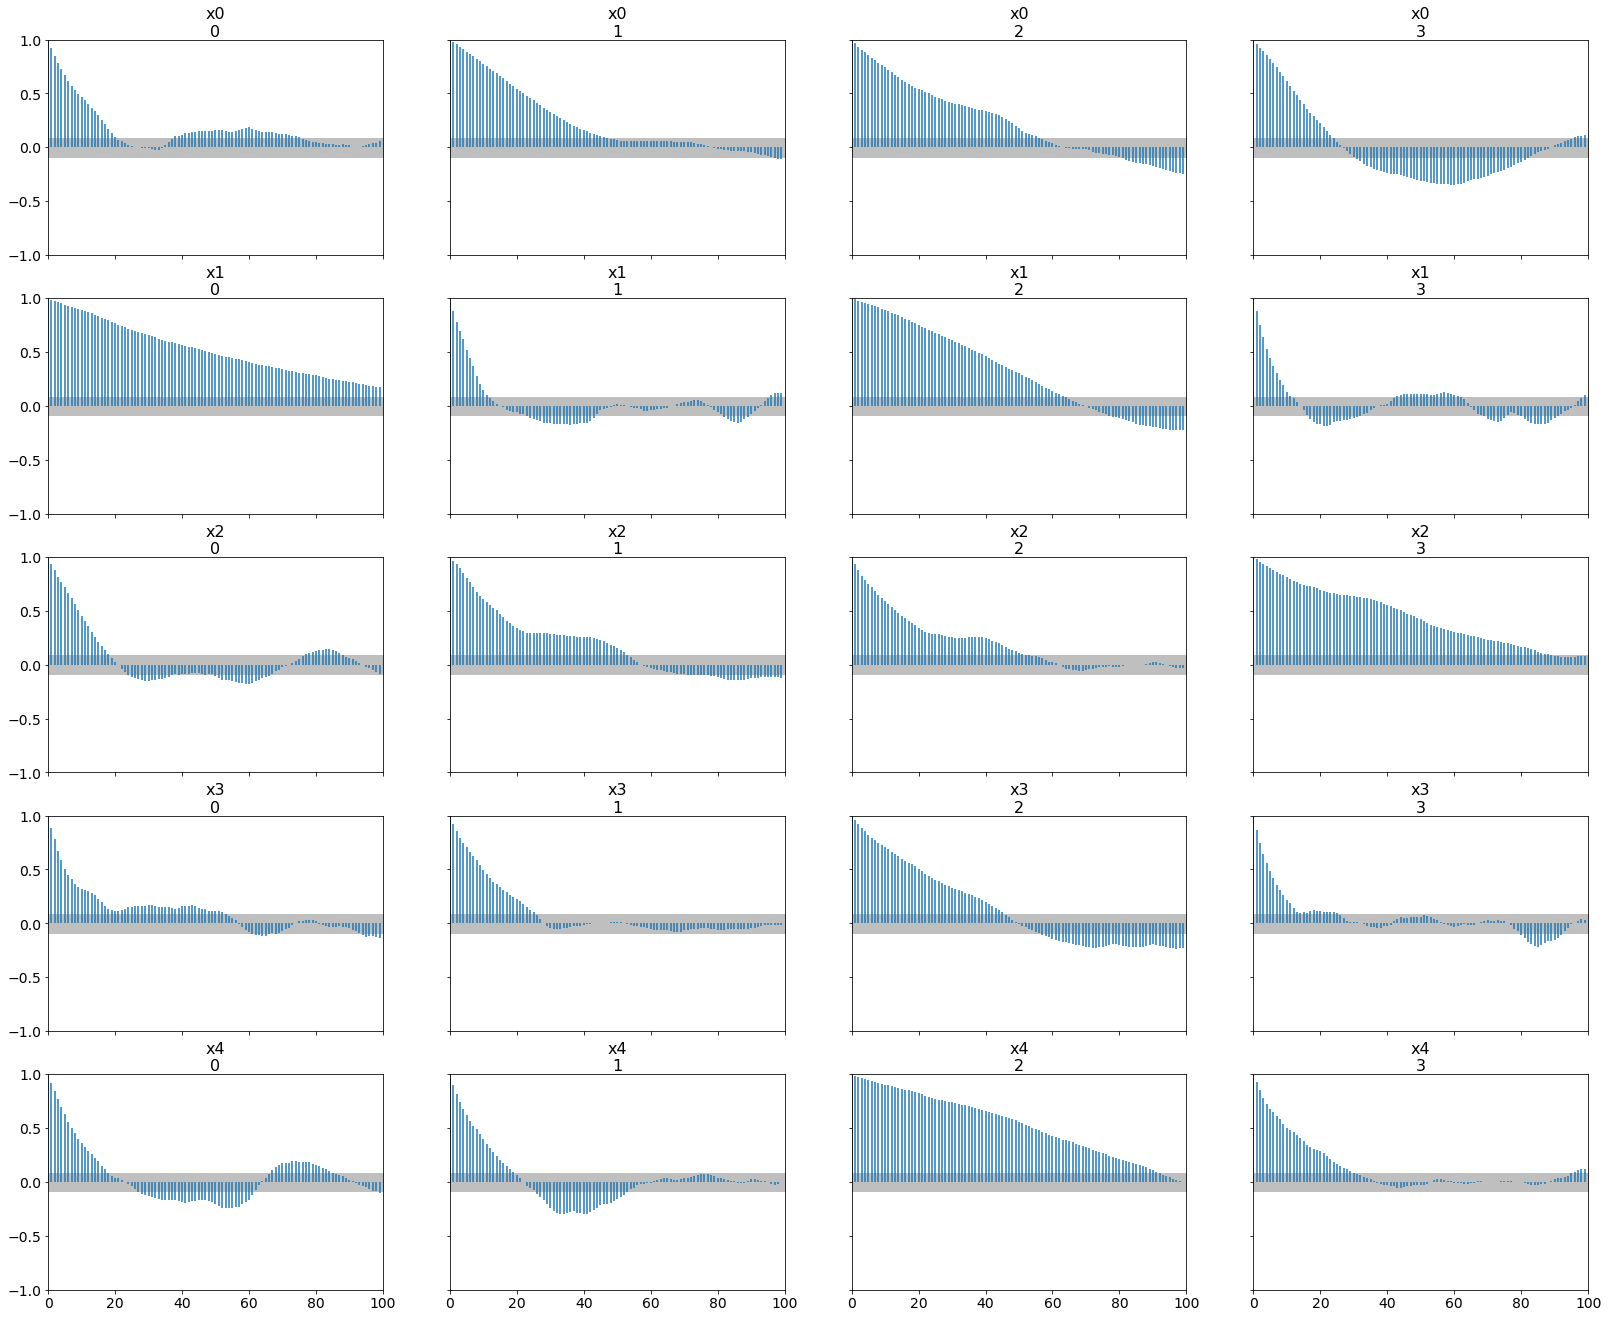

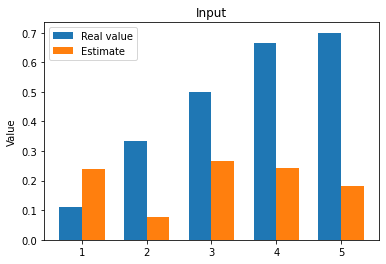

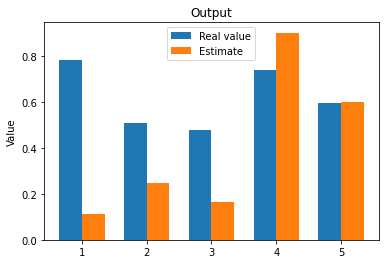

The function inverse took 735.5034279823303 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = True
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="CN")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.23: 100%|██████████| 1000/1000 [02:54<00:00,  5.74it/s]


Sampling chain 2/4


Running chain, α = 0.23: 100%|██████████| 1000/1000 [02:59<00:00,  5.58it/s]


Sampling chain 3/4


Running chain, α = 0.21: 100%|██████████| 1000/1000 [02:54<00:00,  5.73it/s]


Sampling chain 4/4


Running chain, α = 0.17: 100%|██████████| 1000/1000 [02:50<00:00,  5.86it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.535 0.597 0.531 0.506 0.574]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.535  0.387  -0.076    1.233      0.044    0.031      78.0     104.0   
x1  0.597  0.372   0.078    1.390      0.048    0.041      62.0      69.0   
x2  0.531  0.358  -0.087    1.147      0.037    0.026      92.0     165.0   
x3  0.506  0.414  -0.083    1.273      0.057    0.041      61.0      46.0   
x4  0.574  0.364  -0.094    1.174      0.039    0.029      88.0      96.0   

    r_hat  
x0   1.05  
x1   1.08  
x2   1.08  
x3   1.07  
x4   1.04  
Autocorrelation...
[0.42266 0.264   0.031   0.159   0.126  ]


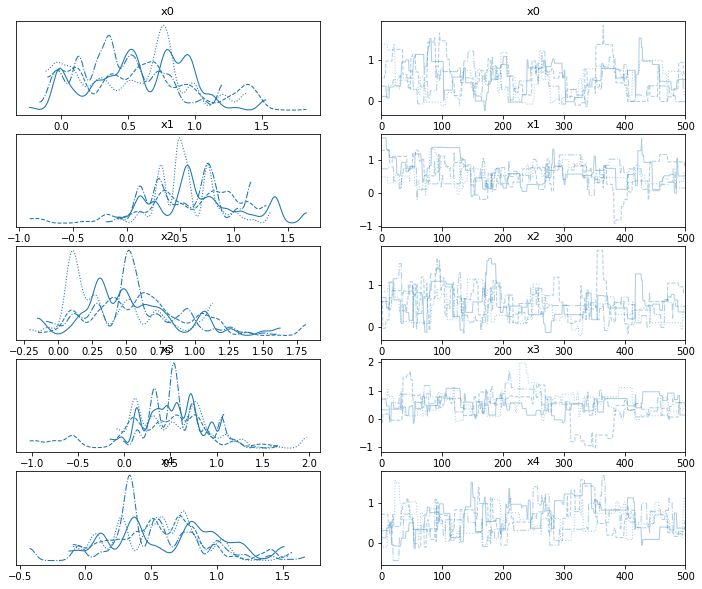

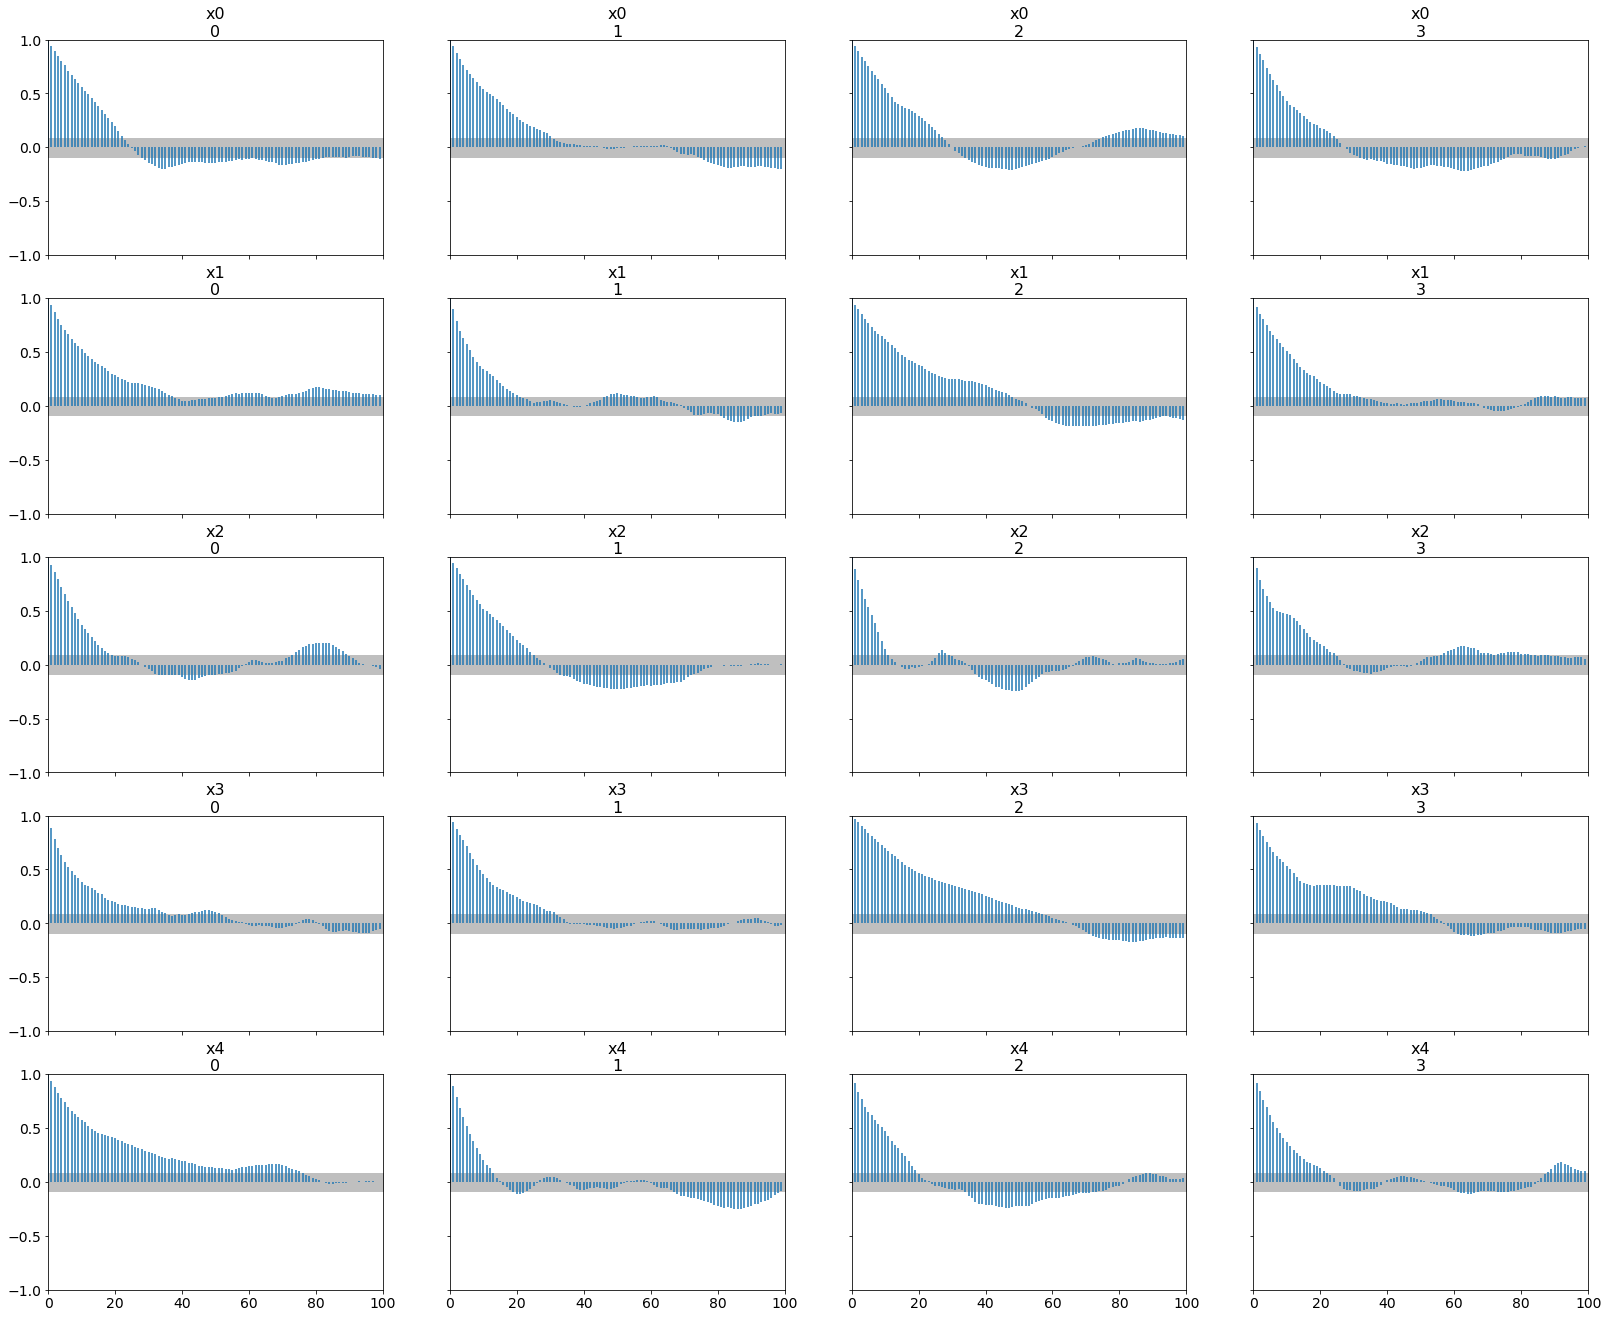

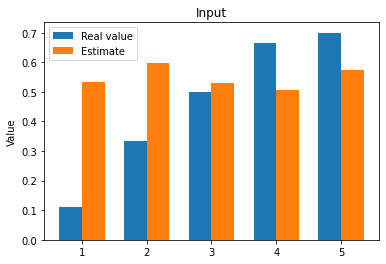

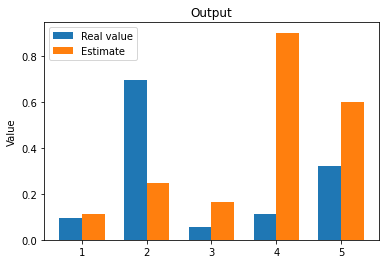

The function inverse took 767.4292497634888 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="DREAMZ")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.26: 100%|██████████| 1000/1000 [02:48<00:00,  5.95it/s]


Sampling chain 2/4


Running chain, α = 0.19: 100%|██████████| 1000/1000 [02:56<00:00,  5.67it/s]


Sampling chain 3/4


Running chain, α = 0.16: 100%|██████████| 1000/1000 [02:55<00:00,  5.69it/s]


Sampling chain 4/4


Running chain, α = 0.20: 100%|██████████| 1000/1000 [02:47<00:00,  5.98it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.545 0.531 0.545 0.586 0.509]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.545  0.369  -0.045    1.217      0.039    0.028      93.0     106.0   
x1  0.531  0.292   0.040    1.060      0.033    0.023      79.0      80.0   
x2  0.545  0.345  -0.058    1.151      0.041    0.029      74.0      59.0   
x3  0.586  0.382  -0.016    1.222      0.053    0.037      57.0      96.0   
x4  0.509  0.365   0.062    1.222      0.040    0.028      87.0      99.0   

    r_hat  
x0   1.02  
x1   1.05  
x2   1.04  
x3   1.08  
x4   1.06  
Autocorrelation...
[0.43266 0.198   0.045   0.079   0.191  ]


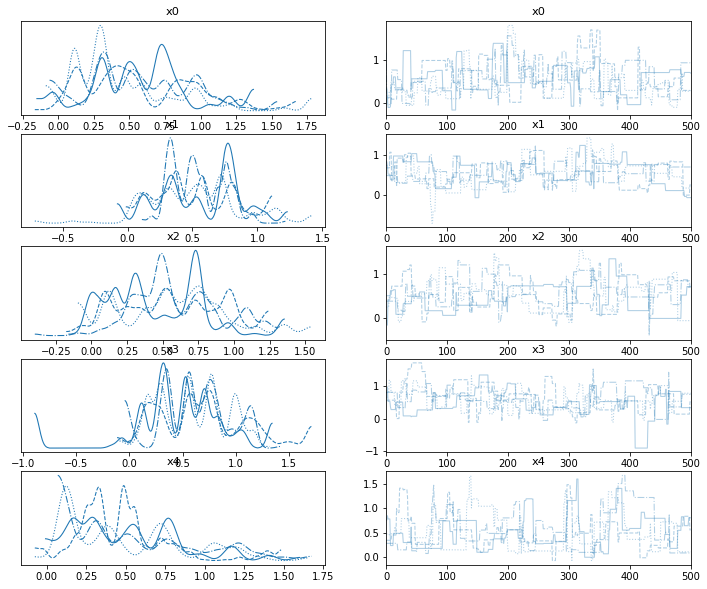

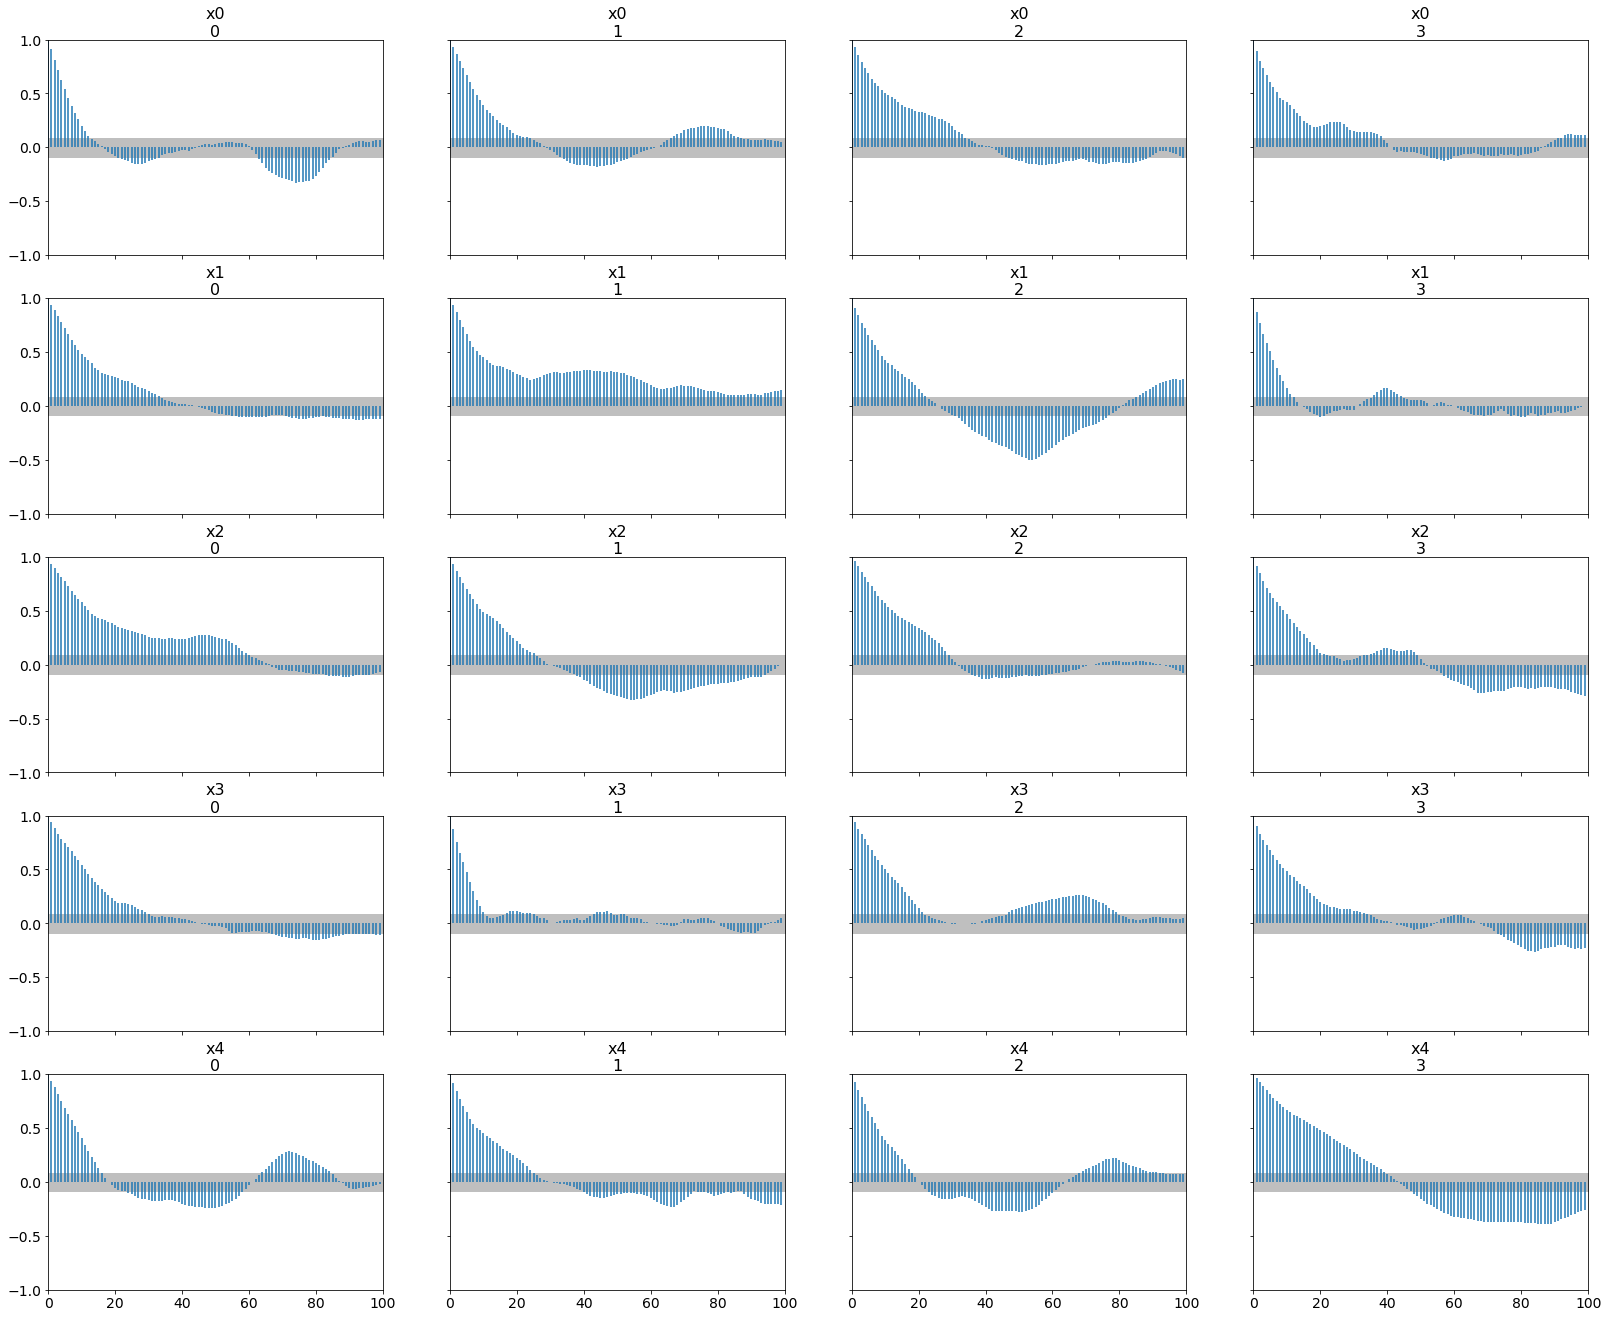

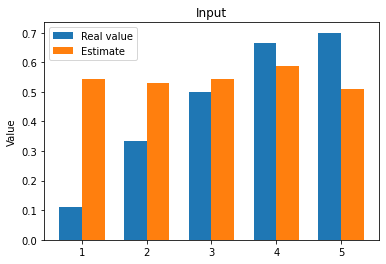

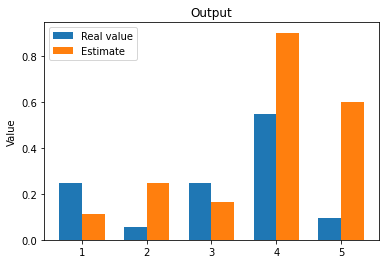

The function inverse took 780.7938289642334 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.eye(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.3 *3# voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = True
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise**2*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations,algo="DREAMZ")
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 1.00:   0%|          | 0/1000 [00:00<?, ?it/s]

Running chain, α = 0.16: 100%|██████████| 1000/1000 [02:39<00:00,  6.28it/s]


Sampling chain 2/4


Running chain, α = 0.11: 100%|██████████| 1000/1000 [02:13<00:00,  7.49it/s]


...

Sampling chain 4/4


Running chain, α = 0.18: 100%|██████████| 1000/1000 [02:11<00:00,  7.59it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


estimated values are [0.503 0.484 0.465 0.618 0.439]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.503  0.243   0.116    0.828      0.106    0.080       6.0      11.0   
x1  0.484  0.206   0.104    0.804      0.096    0.075       5.0      24.0   
x2  0.465  0.101   0.286    0.581      0.040    0.030       8.0      78.0   
x3  0.618  0.296   0.096    1.097      0.145    0.111       4.0      13.0   
x4  0.439  0.173   0.089    0.734      0.074    0.055       6.0      14.0   

    r_hat  
x0   1.93  
x1   2.23  
x2   1.43  
x3   3.61  
x4   1.71  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


Autocorrelation...
[0.503 0.484 0.465 0.618 0.439]
[0.11234 0.333   0.5     0.665   0.7    ]


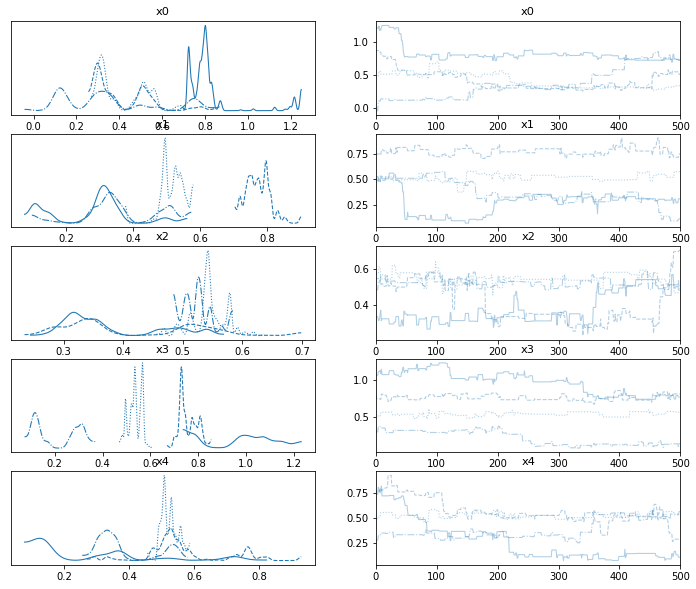

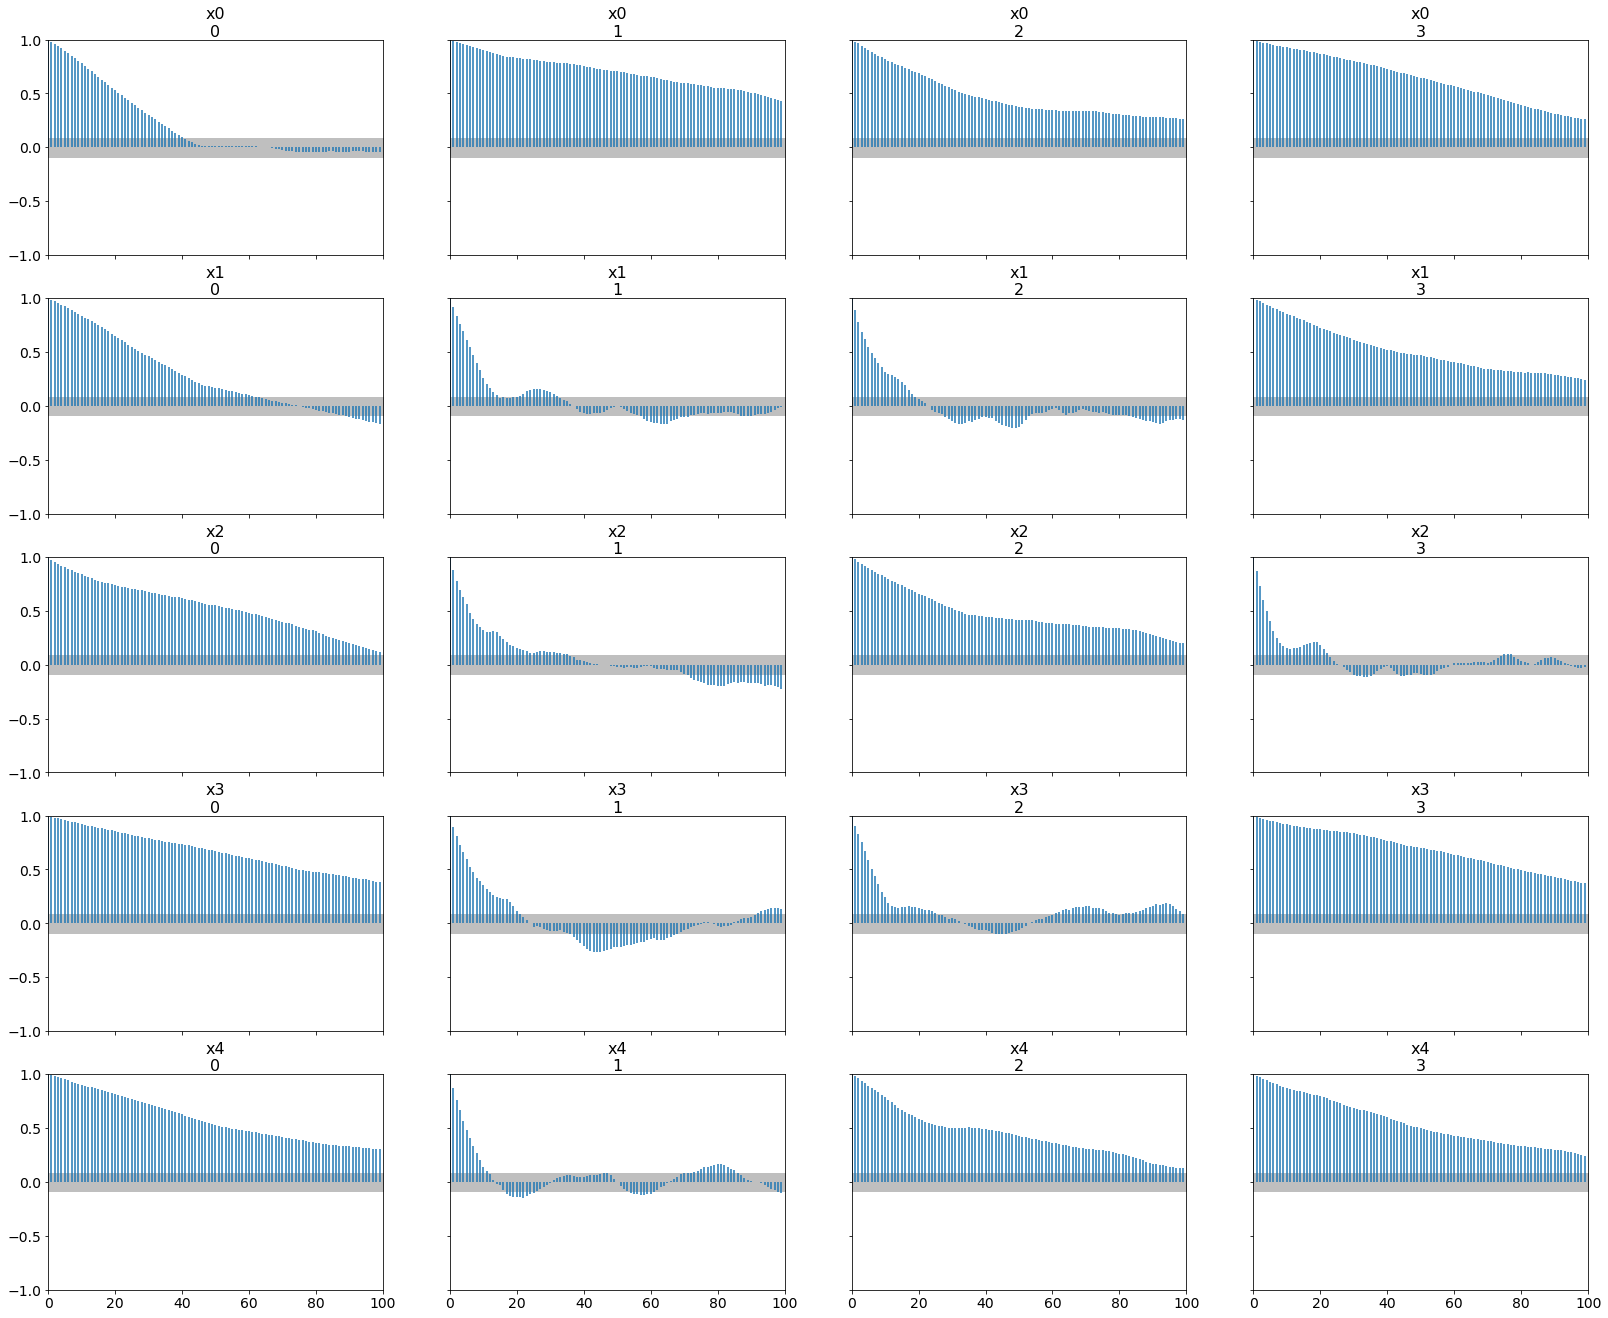

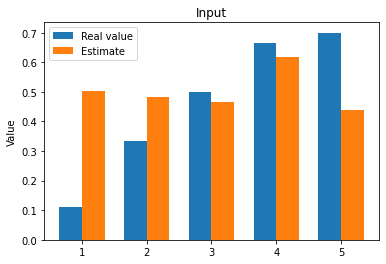

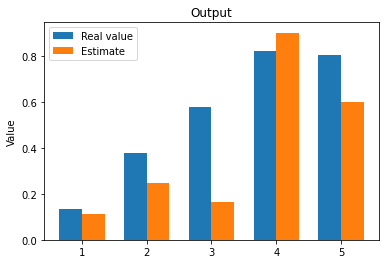

The function inverse took 562.0243139266968 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)
    

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.40: 100%|██████████| 3000/3000 [07:47<00:00,  6.41it/s]


Sampling chain 2/4


Running chain, α = 0.47: 100%|██████████| 3000/3000 [08:00<00:00,  6.24it/s]


Sampling chain 3/4


Running chain, α = 0.44: 100%|██████████| 3000/3000 [08:05<00:00,  6.18it/s]


Sampling chain 4/4


Running chain, α = 0.43: 100%|██████████| 3000/3000 [08:11<00:00,  6.10it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.51  0.457 0.579 0.475 0.662]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.510  0.329  -0.083    1.121      0.095    0.069      12.0      43.0   
x1  0.457  0.254  -0.070    0.847      0.043    0.031      36.0      61.0   
x2  0.579  0.313  -0.043    1.121      0.109    0.080       8.0      49.0   
x3  0.475  0.320  -0.060    1.089      0.068    0.056      25.0      43.0   
x4  0.662  0.343   0.074    1.340      0.137    0.106       7.0      14.0   

    r_hat  
x0   1.27  
x1   1.10  
x2   1.45  
x3   1.23  
x4   1.60  
Autocorrelation...
[0.51  0.457 0.579 0.475 0.662]
[0.11234 0.333   0.5     0.665   0.7    ]


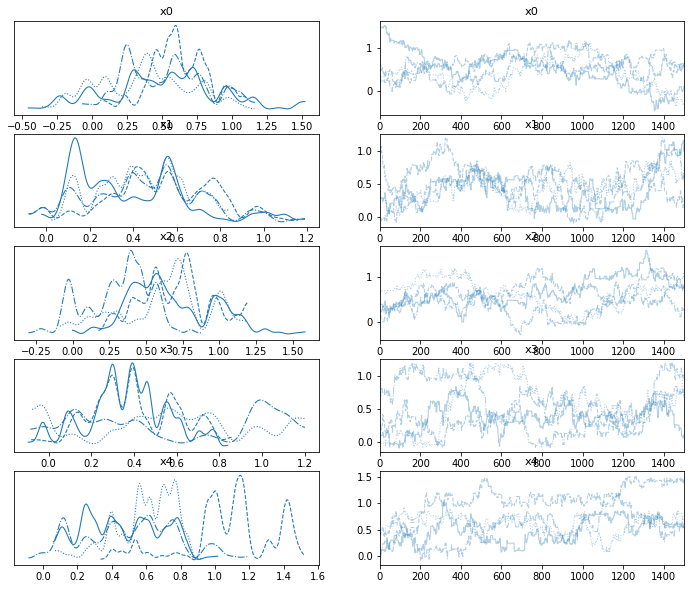

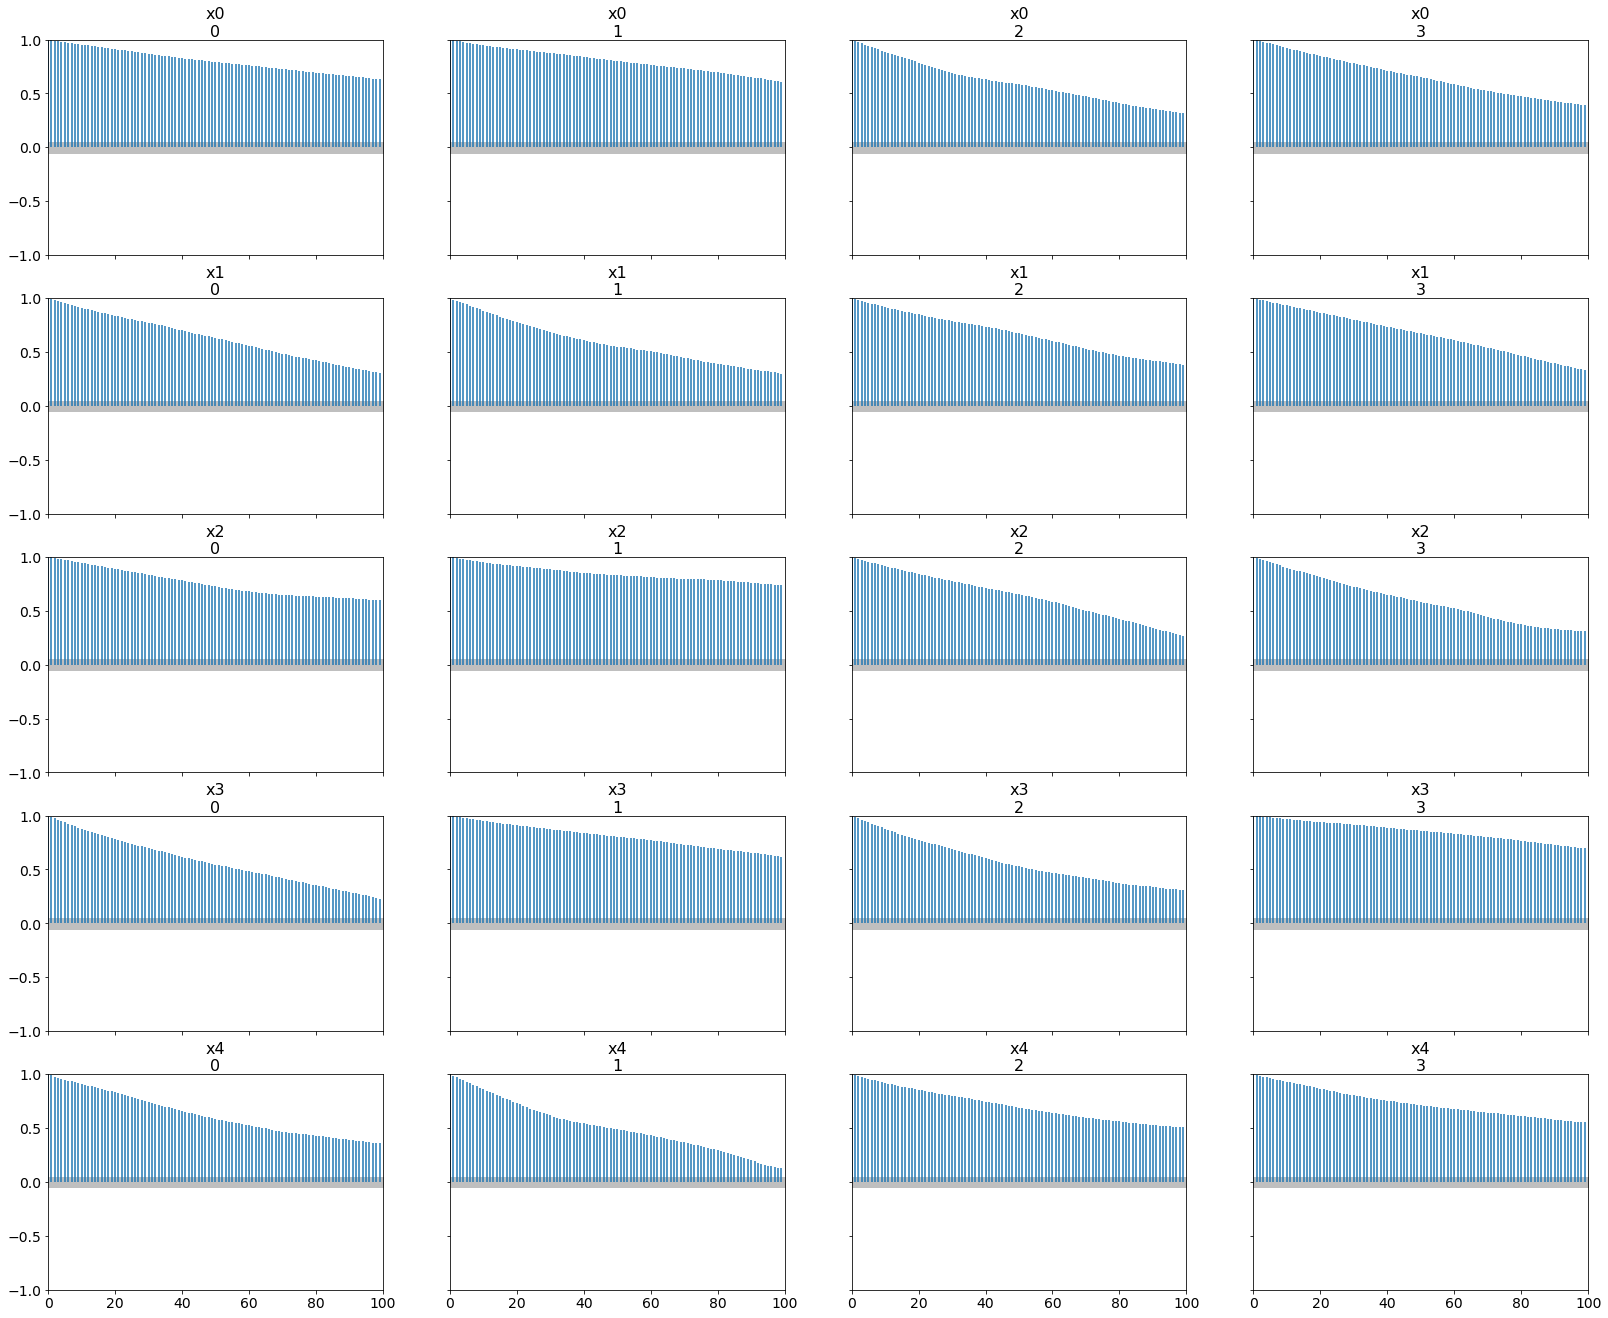

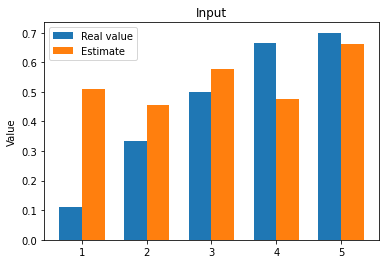

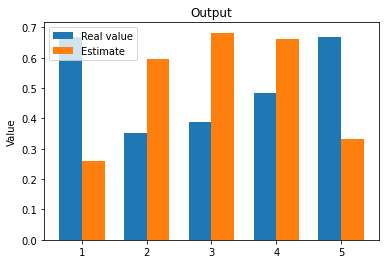

The function inverse took 1936.1948635578156 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
iterations=3000
burnin=1500
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)
    

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/10


Running chain, α = 0.05: 100%|██████████| 1000/1000 [02:49<00:00,  5.89it/s]


Sampling chain 2/10


Running chain, α = 0.17: 100%|██████████| 1000/1000 [02:44<00:00,  6.08it/s]


Sampling chain 3/10


...

Sampling chain 10/10


Running chain, α = 0.14: 100%|██████████| 1000/1000 [02:55<00:00,  5.70it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.571 0.541 0.489 0.651 0.484]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.571  0.286   0.091    1.021      0.085    0.062      12.0      21.0   
x1  0.541  0.427  -0.038    1.179      0.130    0.095      11.0      15.0   
x2  0.489  0.219   0.095    0.800      0.062    0.045      14.0      32.0   
x3  0.651  0.349   0.119    1.178      0.105    0.077      12.0      15.0   
x4  0.484  0.309  -0.069    1.078      0.094    0.068      11.0      13.0   

    r_hat  
x0   2.68  
x1   3.33  
x2   2.02  
x3   2.55  
x4   3.52  
Autocorrelation...


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\plots\plot_utils.py:271: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (50) in plot_autocorr, generating only 40 plots
  warnings.warn(


[0.571 0.541 0.489 0.651 0.484]
[0.11234 0.333   0.5     0.665   0.7    ]


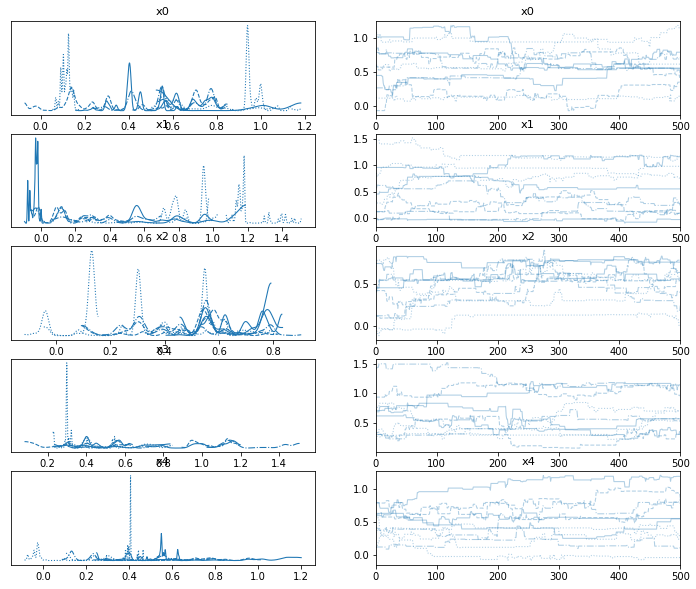

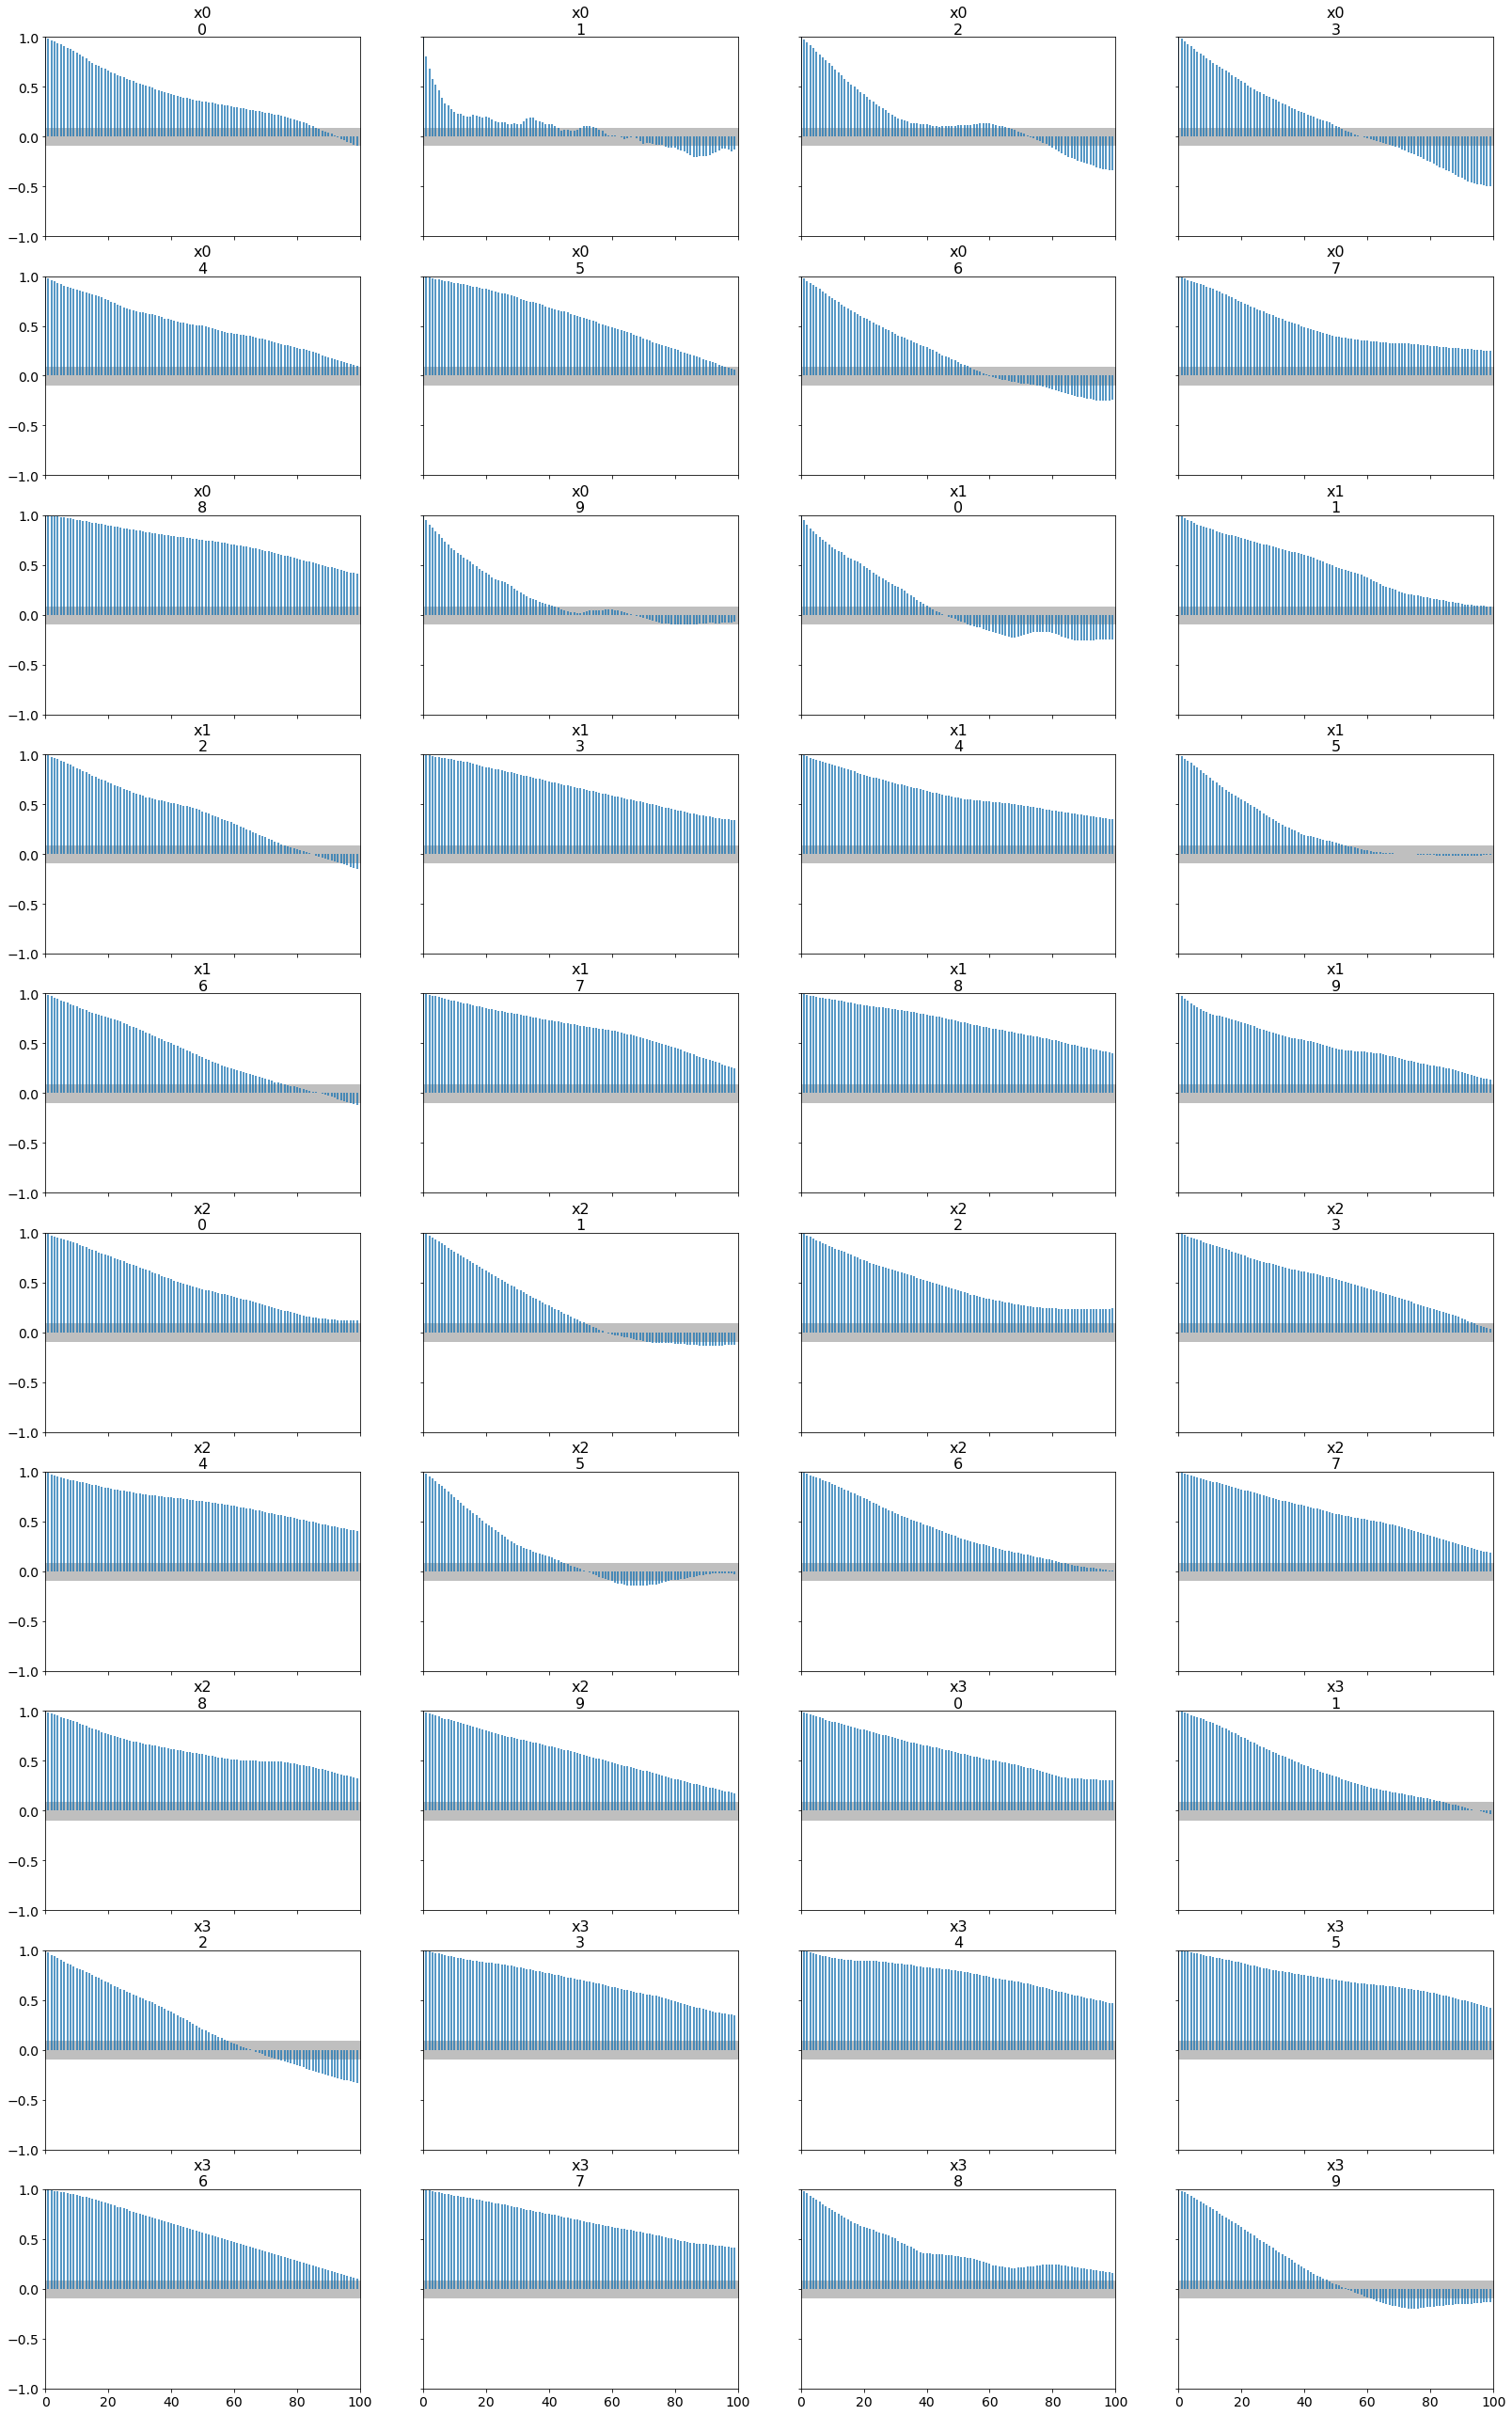

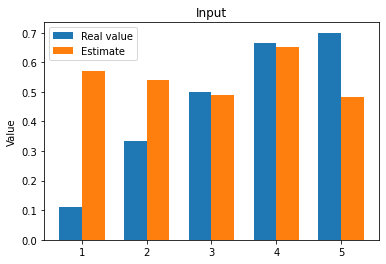

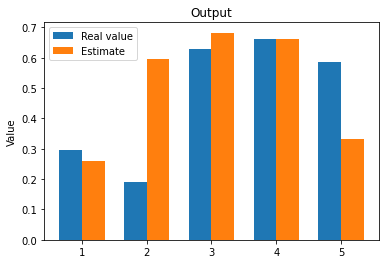

The function inverse took 1752.8812668323517 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
iterations=1000
burnin=500
n_chains=10
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.58: 100%|██████████| 1000/1000 [02:57<00:00,  5.63it/s]


Sampling chain 2/4


Running chain, α = 0.58: 100%|██████████| 1000/1000 [03:12<00:00,  5.21it/s]


Sampling chain 3/4


Running chain, α = 0.57: 100%|██████████| 1000/1000 [02:52<00:00,  5.79it/s]


Sampling chain 4/4


Running chain, α = 0.60: 100%|██████████| 1000/1000 [03:04<00:00,  5.43it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.294 0.765 0.449 0.75  0.307]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.294  0.739  -0.809    1.836      0.335    0.253       5.0      13.0   
x1  0.765  0.687  -0.614    2.124      0.312    0.236       5.0      17.0   
x2  0.449  0.409  -0.092    1.517      0.145    0.108       9.0      17.0   
x3  0.750  0.636  -0.084    2.051      0.289    0.218       5.0      18.0   
x4  0.307  0.394  -0.379    1.076      0.156    0.116       6.0      15.0   

    r_hat  
x0   2.19  
x1   2.37  
x2   1.42  
x3   2.12  
x4   1.68  
Autocorrelation...
[0.294 0.765 0.449 0.75  0.307]
[0.11234 0.333   0.5     0.665   0.7    ]


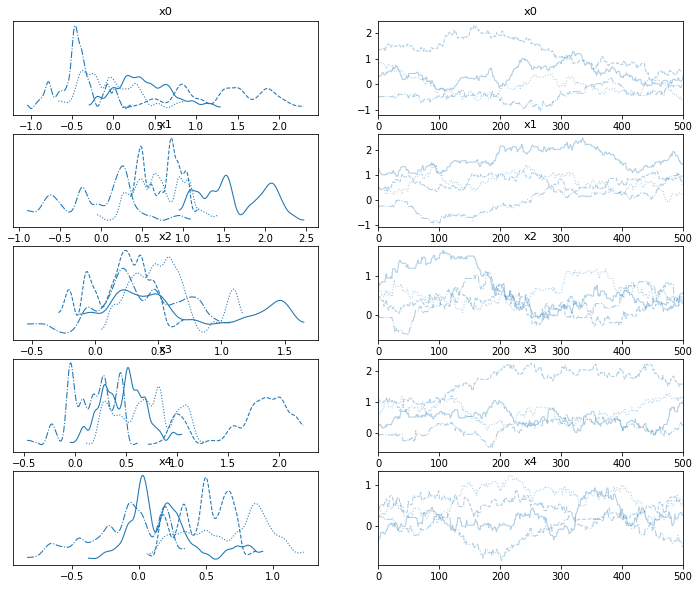

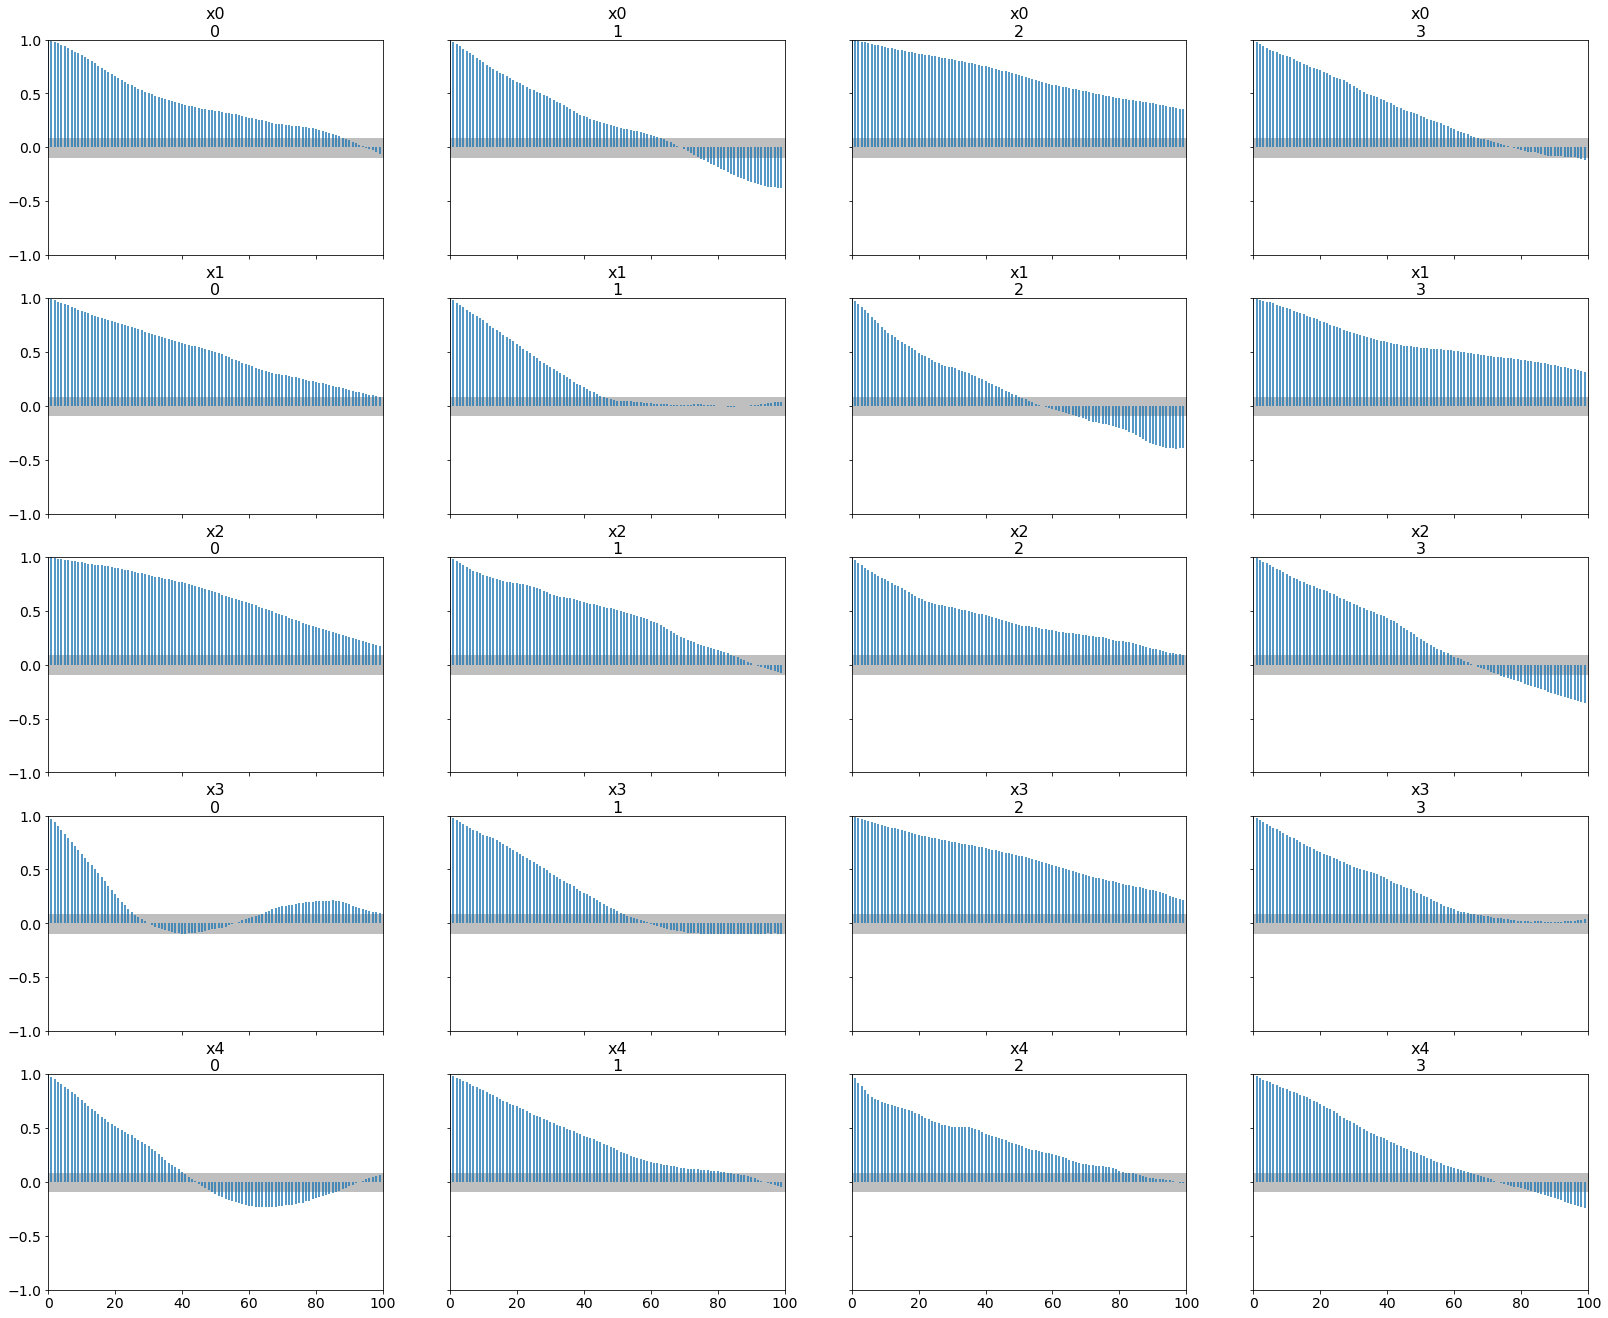

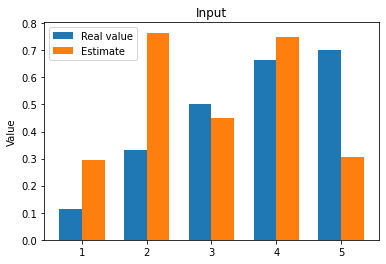

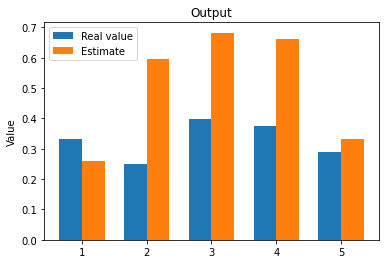

The function inverse took 732.2816848754883 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*3  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.1*3 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=1000#4000#8000
burnin=500#2000#4000
n_chains=4

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/6


Running chain, α = 0.32: 100%|██████████| 1500/1500 [03:32<00:00,  7.05it/s]


Sampling chain 2/6


Running chain, α = 0.55: 100%|██████████| 1500/1500 [03:40<00:00,  6.80it/s]


Sampling chain 3/6


...

Sampling chain 5/6


Running chain, α = 0.42: 100%|██████████| 1500/1500 [03:38<00:00,  6.88it/s]


Sampling chain 6/6


Running chain, α = 0.23: 100%|██████████| 1500/1500 [03:53<00:00,  6.42it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.684 0.235 0.521 0.209 0.67 ]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.684  0.367   0.063    1.237      0.119    0.087      10.0      25.0   
x1  0.235  0.582  -1.229    0.860      0.221    0.163      10.0      24.0   
x2  0.521  0.762  -1.079    1.552      0.300    0.222       7.0      21.0   
x3  0.209  0.570  -0.993    1.118      0.212    0.157      10.0      24.0   
x4  0.670  0.420  -0.098    1.310      0.151    0.111       8.0      35.0   

    r_hat  
x0   1.67  
x1   1.62  
x2   2.57  
x3   1.66  
x4   2.02  
Autocorrelation...
[0.684 0.235 0.521 0.209 0.67 ]
[0.11234 0.333   0.5     0.665   0.7    ]


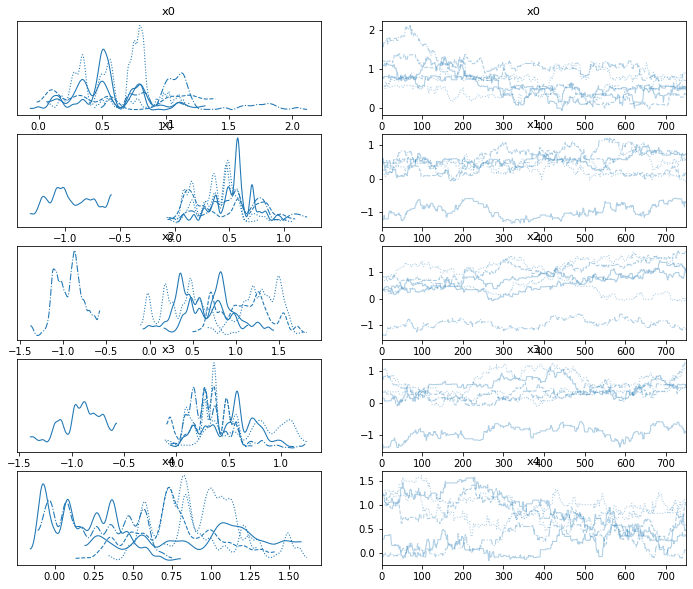

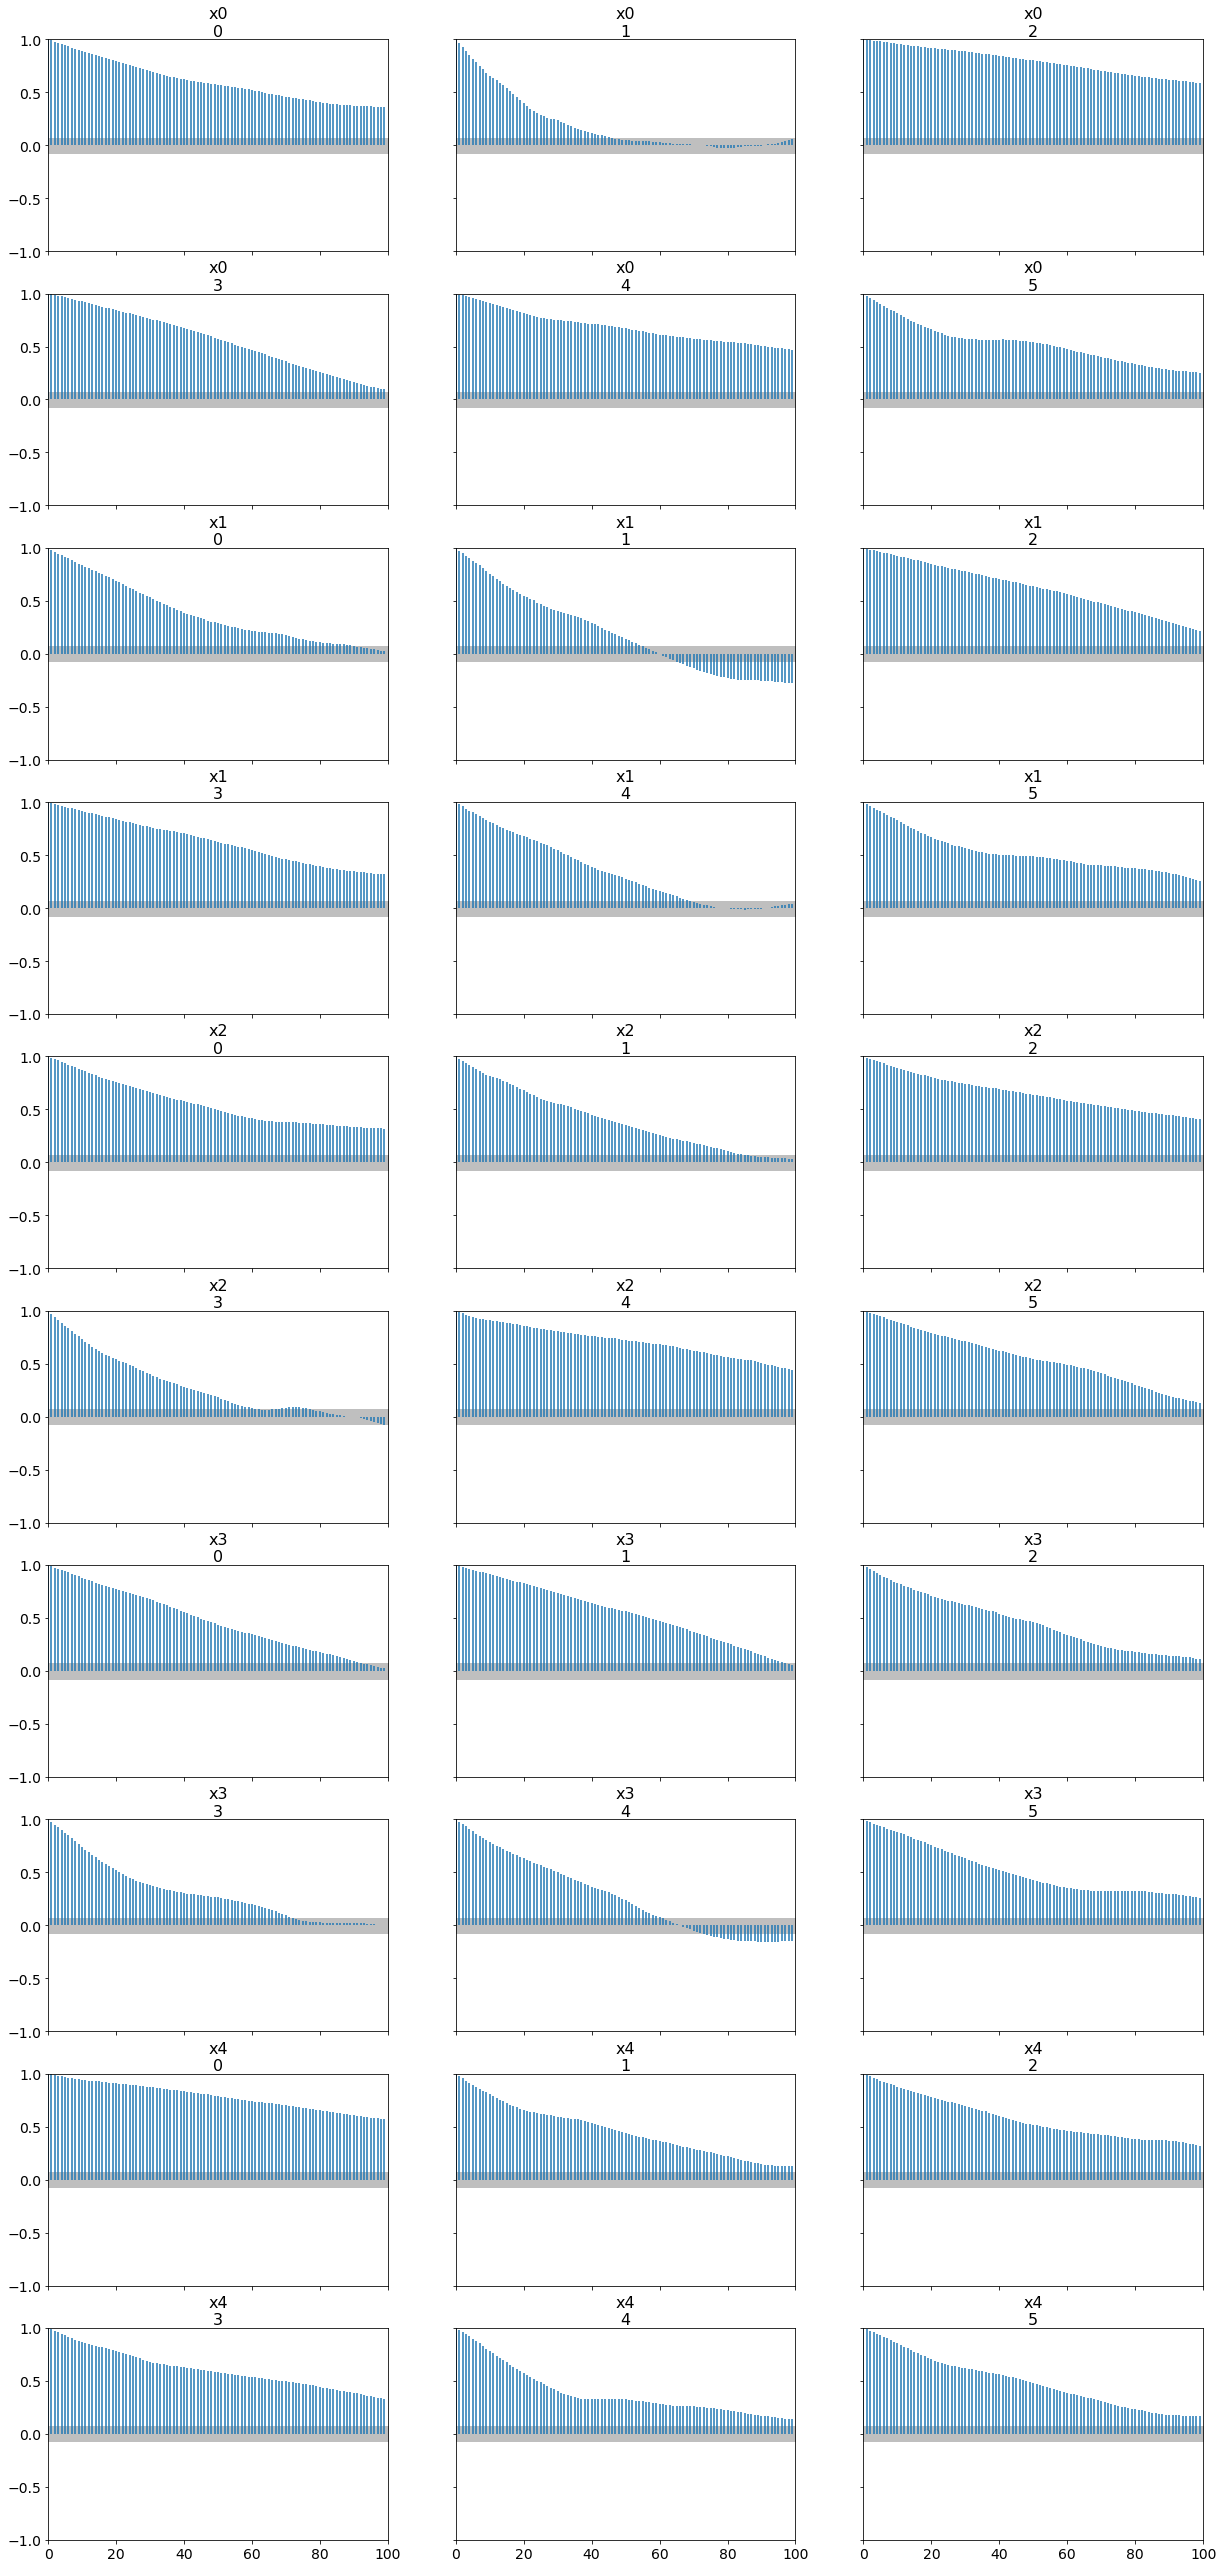

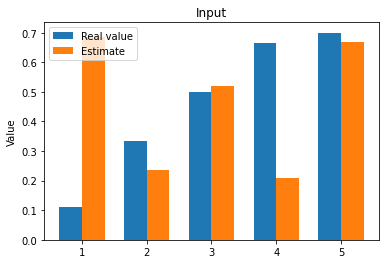

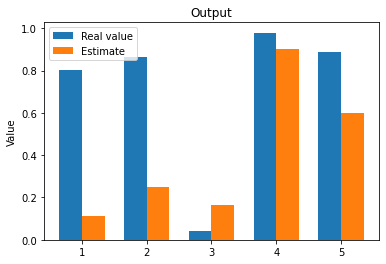

The function inverse took 1341.2048208713531 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*3  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.1*3 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*1.5 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=1500#4000#8000
burnin=750#2000#4000
n_chains=6

for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*2#*3  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.05 # covariance of the noise added to the known data
sigma_noise=0.05#*3 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*4 # covarianza della distribuzione di proposta!   <- elemento principale da regolare per modificare parametro di accettazione
rmwh_scaling = 0.1
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=1500#4000#8000
burnin=750#2000#4000
n_chains=2
# alfa indica acceptance rejection, mi aspetto valori tra 0.3 e 0.5 che si riducano (mi sto avvicinando a valore vero, per cui prob piu alta)
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/2


Running chain, α = 0.00:  28%|██▊       | 421/1500 [01:11<03:02,  5.91it/s]


KeyboardInterrupt: 

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.75: 100%|██████████| 3000/3000 [07:24<00:00,  6.75it/s]


Sampling chain 2/4


Running chain, α = 0.64: 100%|██████████| 3000/3000 [07:07<00:00,  7.02it/s]


Sampling chain 3/4


...

Sampling chain 4/4


Running chain, α = 0.58: 100%|██████████| 3000/3000 [08:08<00:00,  6.15it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


estimated values are [0.39  0.434 0.243 0.506 0.562]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.390  0.278  -0.095    0.794      0.135    0.103       5.0      21.0   
x1  0.434  0.239   0.082    0.795      0.118    0.090       5.0      33.0   
x2  0.243  0.192  -0.071    0.547      0.092    0.070       5.0      18.0   
x3  0.506  0.356   0.069    1.098      0.174    0.133       5.0      13.0   
x4  0.562  0.208   0.257    0.826      0.099    0.075       5.0      60.0   

    r_hat  
x0   2.77  
x1   2.86  
x2   2.30  
x3   2.57  
x4   1.99  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


Autocorrelation...
[0.39  0.434 0.243 0.506 0.562]
[0.11234 0.333   0.5     0.665   0.7    ]


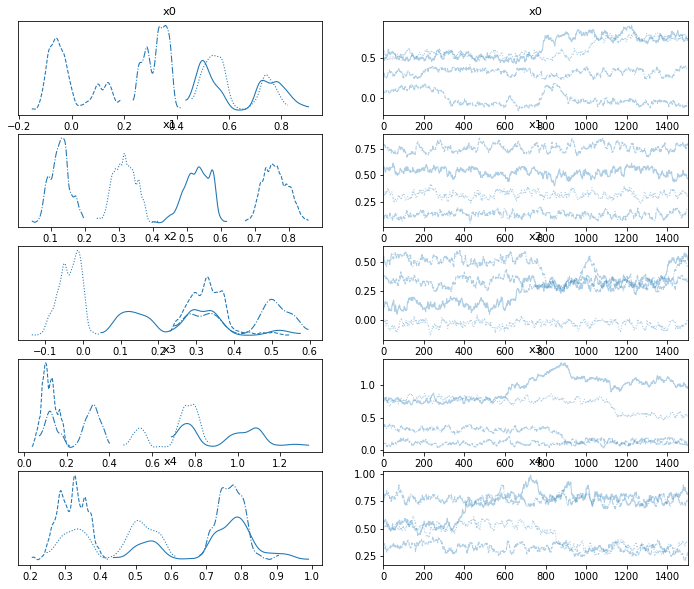

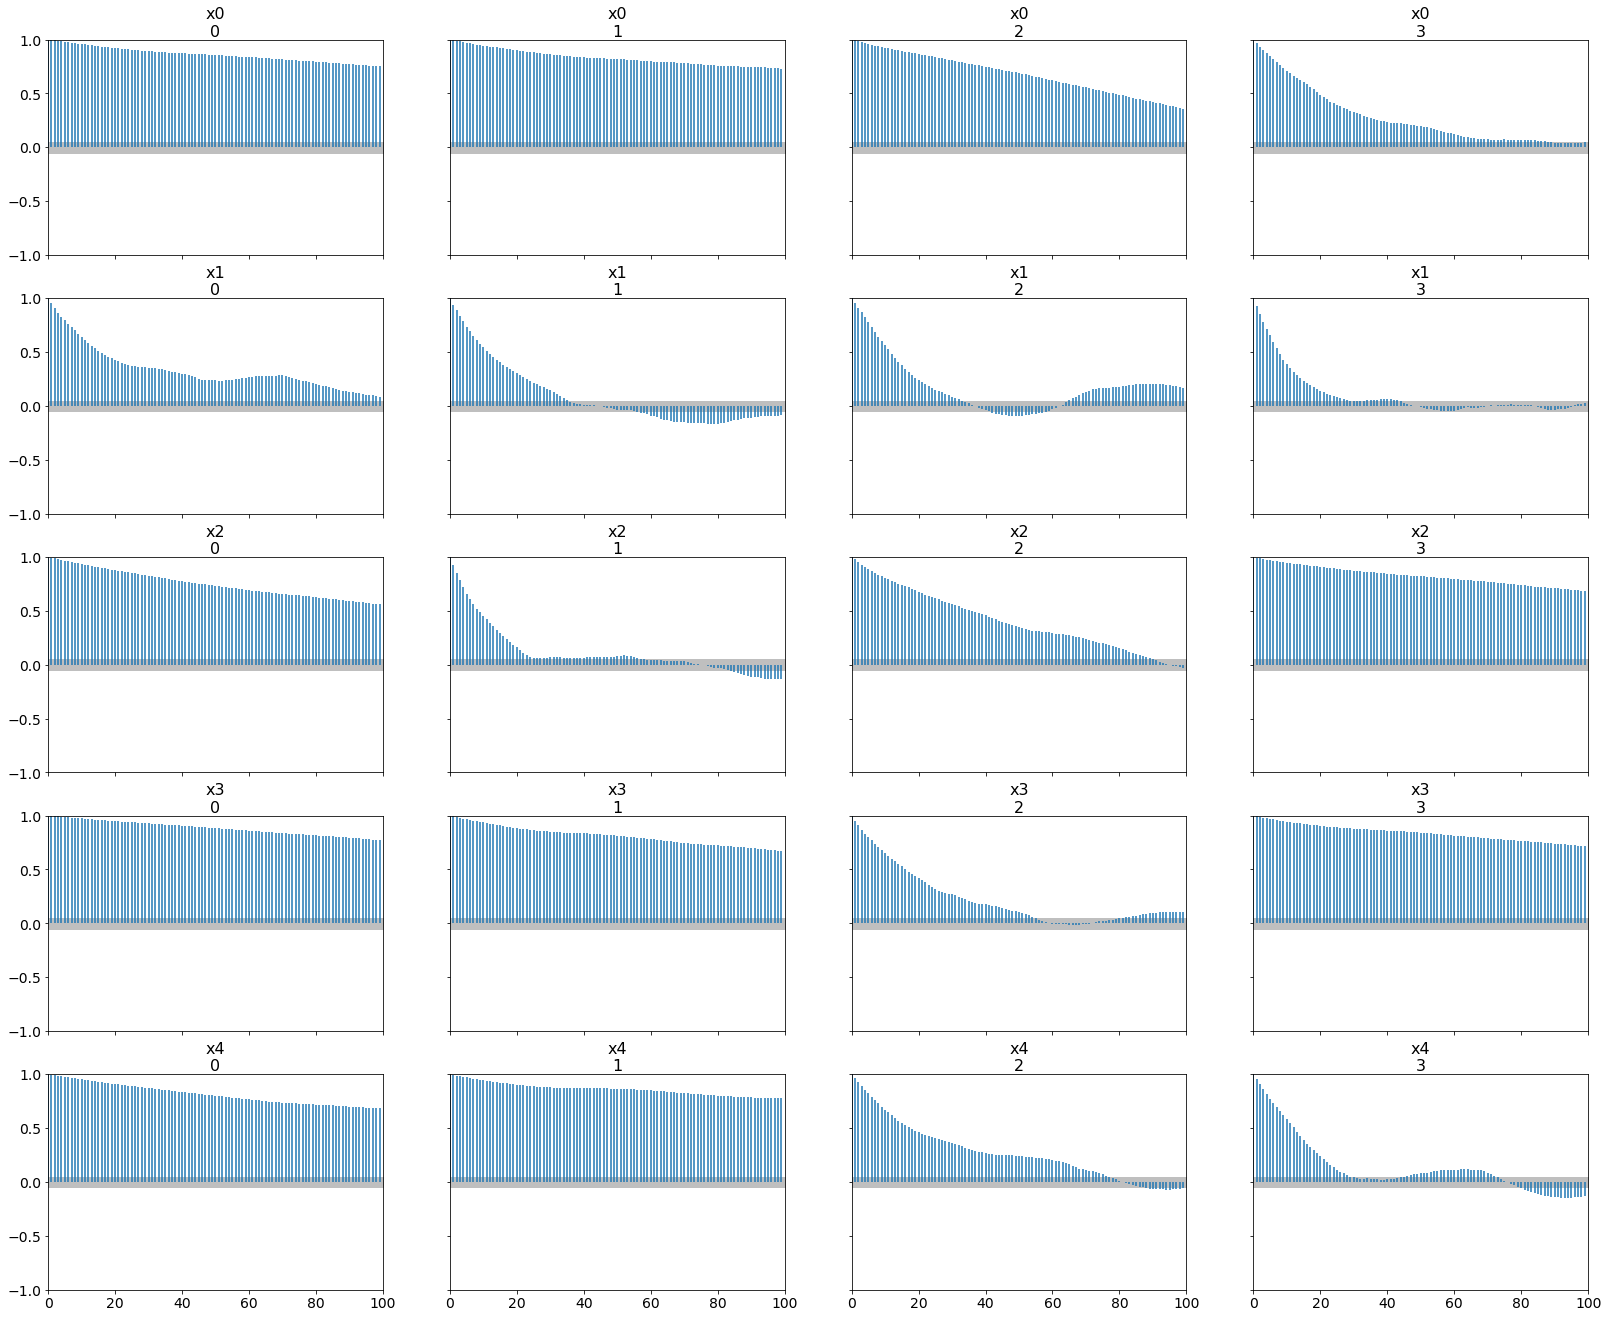

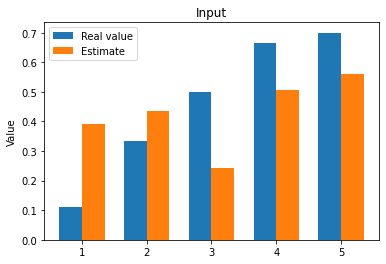

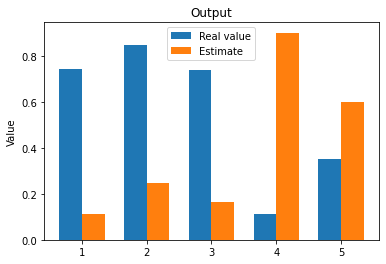

The function inverse took 1821.0441436767578 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.1*4 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.01
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=3000#4000#8000
burnin=1500#2000#4000
n_chains=4
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
  

adaptive case
real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/4


Running chain, α = 0.33: 100%|██████████| 3000/3000 [08:18<00:00,  6.02it/s]


Sampling chain 2/4


Running chain, α = 0.29: 100%|██████████| 3000/3000 [08:07<00:00,  6.15it/s]


Sampling chain 3/4


Running chain, α = 0.33: 100%|██████████| 3000/3000 [09:29<00:00,  5.27it/s]  


Sampling chain 4/4


Running chain, α = 0.25: 100%|██████████| 3000/3000 [07:44<00:00,  6.46it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [0.55  0.597 0.566 0.594 0.602]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.550  0.335  -0.092    1.115      0.022    0.015     242.0     395.0   
x1  0.597  0.364  -0.066    1.191      0.026    0.018     205.0     265.0   
x2  0.566  0.375  -0.039    1.225      0.028    0.020     181.0     410.0   
x3  0.594  0.381  -0.071    1.280      0.033    0.023     139.0     328.0   
x4  0.602  0.374   0.048    1.287      0.032    0.023     138.0     380.0   

    r_hat  
x0   1.01  
x1   1.02  
x2   1.03  
x3   1.03  
x4   1.03  
Autocorrelation...
[0.55  0.597 0.566 0.594 0.602]
[0.11234 0.333   0.5     0.665   0.7    ]


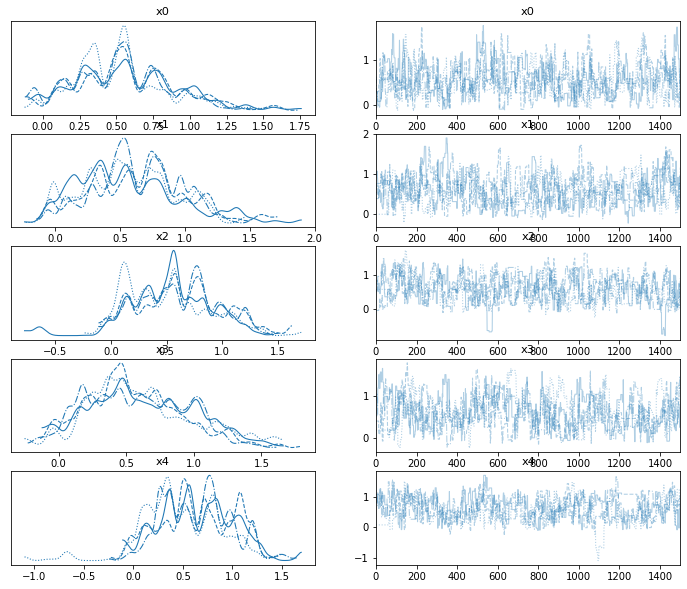

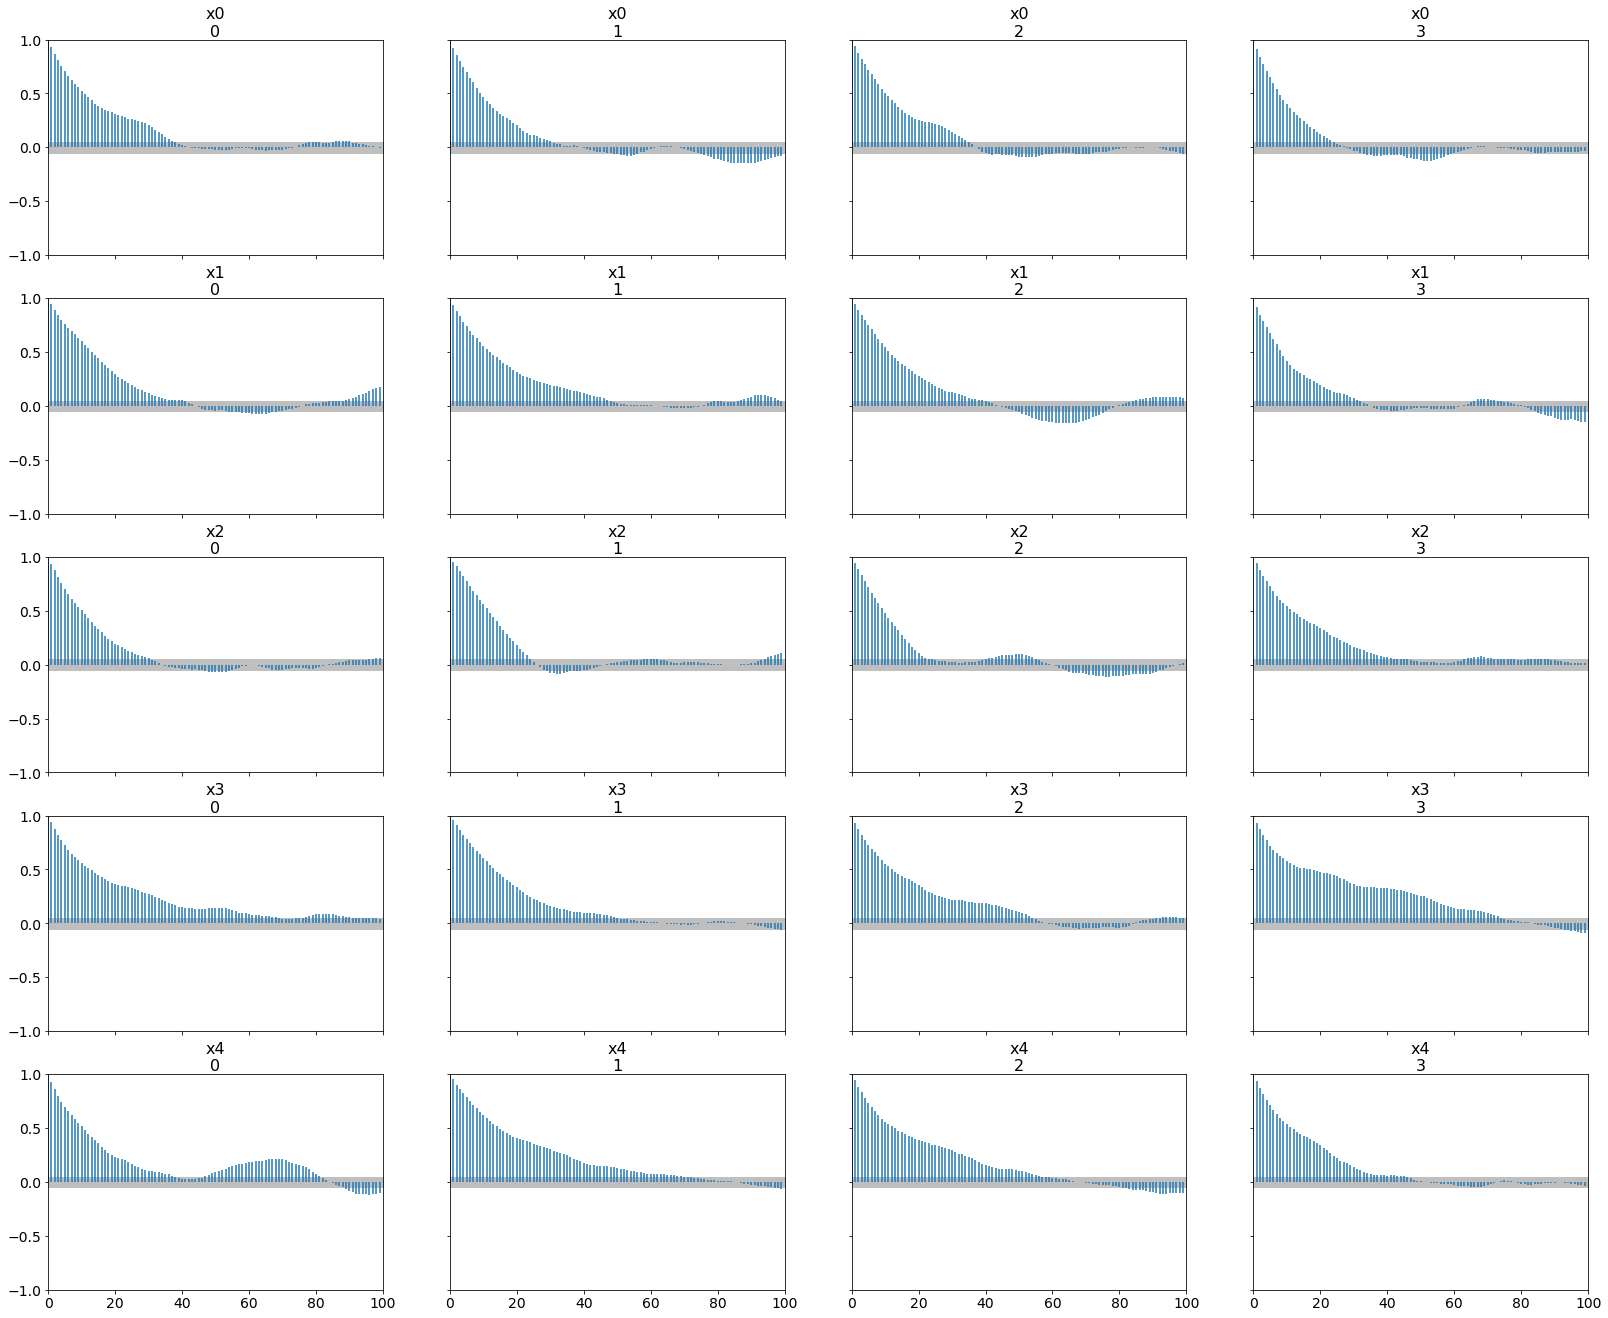

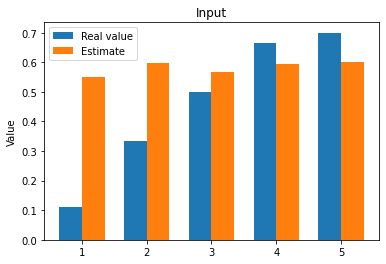

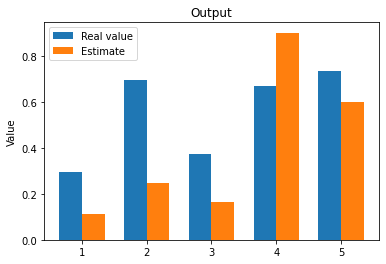

The function inverse took 2030.943510055542 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
print(("adaptive case"))
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.1*4 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*2 # covarianza della distribuzione di proposta!
rmwh_scaling = 0.01
rwmh_adaptive = True
#iterations =20000
#burnin = 5000
iterations=3000#4000#8000
burnin=1500#2000#4000
n_chains=4
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
  

adaptive case
real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/1


Running chain, α = 0.15: 100%|██████████| 3000/3000 [08:09<00:00,  6.13it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 1501), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 1501), minimum_shape: (chains=2, draws=4)


estimated values are [0.572 0.625 0.558 0.608 0.574]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.572  0.379  -0.009    1.343      0.073    0.052      28.0     100.0   
x1  0.625  0.452  -0.111    1.325      0.116    0.083      13.0      35.0   
x2  0.558  0.385  -0.131    1.199      0.051    0.038      57.0      71.0   
x3  0.608  0.354   0.016    1.279      0.064    0.051      31.0      57.0   
x4  0.574  0.343  -0.090    1.107      0.052    0.037      45.0      89.0   

    r_hat  
x0    NaN  
x1    NaN  
x2    NaN  
x3    NaN  
x4    NaN  
Autocorrelation...
[0.572 0.625 0.558 0.608 0.574]
[0.11234 0.333   0.5     0.665   0.7    ]


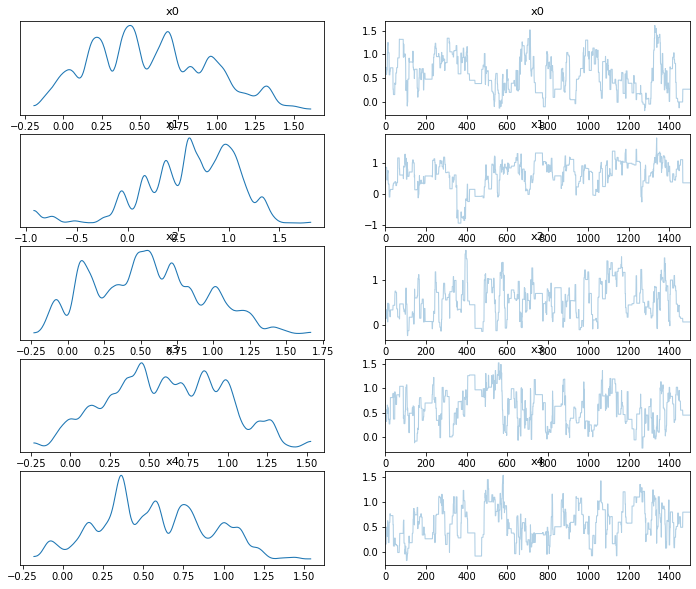

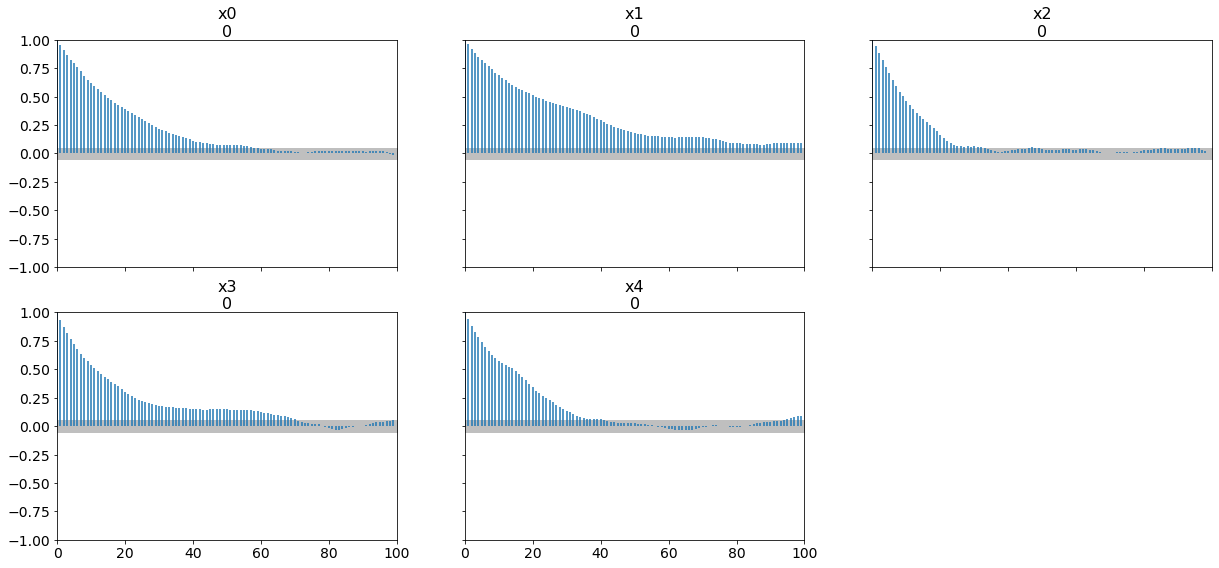

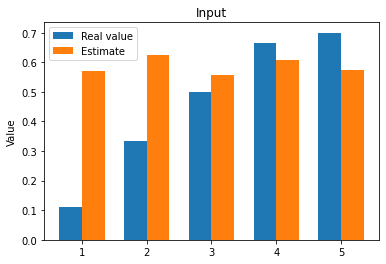

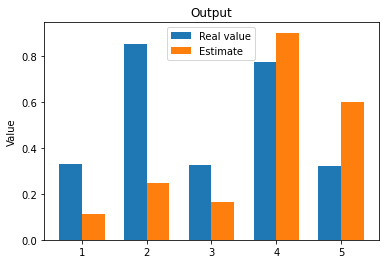

The function inverse took 492.39684987068176 seconds.


AttributeError: 'int' object has no attribute 'inverse'

In [ ]:
print(("adaptive case"))
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*1.5  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1 # covariance of the noise added to the known data
sigma_noise=0.1*4 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x)) # covarianza della distribuzione di proposta!
rmwh_scaling = 0.01
rwmh_adaptive = True
#iterations =20000
#burnin = 5000
iterations=3000#4000#8000
burnin=1500#2000#4000
n_chains=1
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
  

In [ ]:
mean_prior = np.ones(dim)*0.5
cov_prior = np.ones(dim)*0.1*1.5#*3  # covariance of the prior # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.05 # covariance of the noise added to the known data
sigma_noise=0.05#*3 # voceriance of the likelihood
rwmh_cov = np.eye(len(real_x))*4 # covarianza della distribuzione di proposta!   <- elemento principale da regolare per modificare parametro di accettazione
rmwh_scaling = 0.05
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=3000#4000#8000
burnin=1500#2000#4000
n_chains=2
# alfa indica acceptance rejection, mi aspetto valori tra 0.3 e 0.5 che si riducano (mi sto avvicinando a valore vero, per cui prob piu alta)
for j in range(len(model_list)):
    estimate_MF=model_list[j].inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma_noise*np.eye(real_x.shape[0]), y_obs=nearest_U, x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,transformation=transformations)
    #estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

real values are [[0.11234]
 [0.333  ]
 [0.5    ]
 [0.665  ]
 [0.7    ]]
Sampling chain 1/2


Running chain, α = 0.07:   1%|▏         | 42/3000 [00:07<09:27,  5.21it/s]Exception ignored in: <function UniquePtr.__del__ at 0x000001F463F0B130>
Traceback (most recent call last):
  File "c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\python\framework\c_api_util.py", line 74, in __del__
    self.deleter(obj)
KeyboardInterrupt: 
Running chain, α = 0.01:   3%|▎         | 101/3000 [00:19<08:25,  5.74it/s]

In [ ]:
for j in range(len(model_list)):
    estimate2=model_list[j].inverse_cuqi(real_x,nearest_U)

ValueError: setting an array element with a sequence.